In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, fbeta_score, confusion_matrix, make_scorer
)
from sklearn.preprocessing import StandardScaler, LabelEncoder


from collections import Counter
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTEENN
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings("ignore")

# Input Dataset

In [2]:
df = pd.read_csv('employee_churn_prediction_updated.csv')

In [3]:
df.sample(10)

,employee_id,age,gender,education,experience_years,monthly_target,target_achievement,working_hours_per_week,overtime_hours_per_week,salary,commission_rate,job_satisfaction,work_location,manager_support_score,company_tenure_years,churn,marital_status,distance_to_office_km,churn_period
83,84,39,Male,Diploma,1,169,0.56,48,19,6911451,0.07,4,Rural,3,0.1,1,Single,34,3 Months
106,107,30,Male,Bachelor,0,199,0.60,52,12,6438856,0.09,3,Rural,2,1.3,1,Married,14,1 Month
303,304,40,Female,Diploma,8,150,1.14,43,1,3624135,0.04,1,Rural,4,0.4,1,Married,41,1 Month
590,591,28,Female,Bachelor,3,188,0.55,63,6,4187171,0.04,3,Urban,2,3.5,1,Married,26,3 Months
992,993,26,Male,Diploma,2,183,0.84,65,0,5707133,0.03,1,Urban,4,0.8,1,Single,20,3 Months
675,676,39,Male,High School,2,71,1.06,64,15,7582692,0.07,1,Urban,3,4.5,1,Single,18,Onboarding
467,468,25,Male,Bachelor,5,125,0.82,59,8,4107177,0.03,3,Urban,4,0.2,1,Married,32,3 Months
491,492,24,Male,High School,2,112,0.60,40,10,4972613,0.09,4,Urban,4,1.6,1,Single,38,3 Months
555,556,28,Male,Bachelor,7,54,0.48,46,2,7584470,0.06,3,Urban,2,3.5,1,Married,30,3 Months
685,686,34,Female,Diploma,6,193,1.16,68,9,6355361,0.07,2,Rural,1,4.7,1,Married,10,3 Months


# Handling Type Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              1000 non-null   int64  
 1   age                      1000 non-null   int64  
 2   gender                   1000 non-null   object 
 3   education                1000 non-null   object 
 4   experience_years         1000 non-null   int64  
 5   monthly_target           1000 non-null   int64  
 6   target_achievement       1000 non-null   float64
 7   working_hours_per_week   1000 non-null   int64  
 8   overtime_hours_per_week  1000 non-null   int64  
 9   salary                   1000 non-null   int64  
 10  commission_rate          1000 non-null   float64
 11  job_satisfaction         1000 non-null   int64  
 12  work_location            1000 non-null   object 
 13  manager_support_score    1000 non-null   int64  
 14  company_tenure_years     

Type data is already correct !!

# Missing Values

In [5]:
df.isnull().sum()

employee_id                0
age                        0
gender                     0
education                  0
experience_years           0
monthly_target             0
target_achievement         0
working_hours_per_week     0
overtime_hours_per_week    0
salary                     0
commission_rate            0
job_satisfaction           0
work_location              0
manager_support_score      0
company_tenure_years       0
churn                      0
marital_status             0
distance_to_office_km      0
churn_period               0
dtype: int64

No missing values in the dataset

# Duplicated Data

In [6]:
df.duplicated().sum()

0

There's no duplicated data in dataset

# Outliers

In [7]:
df.describe()

,employee_id,age,experience_years,monthly_target,target_achievement,working_hours_per_week,overtime_hours_per_week,salary,commission_rate,job_satisfaction,manager_support_score,company_tenure_years,churn,distance_to_office_km
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000
mean,500.500000,32.845000,4.495000,125.877000,0.79188,54.102000,9.508000,5.487914e+06,0.058830,2.524000,2.53200,2.59800,0.629000,24.119000
std,288.819436,6.854046,2.890732,43.895748,0.22872,8.721907,5.739066,1.436482e+06,0.023278,1.125474,1.11724,1.40282,0.483314,13.978062
min,1.000000,22.000000,0.000000,50.000000,0.40000,40.000000,0.000000,3.000037e+06,0.020000,1.000000,1.00000,0.10000,0.000000,1.000000
25%,250.750000,27.000000,2.000000,86.750000,0.59000,46.000000,5.000000,4.258970e+06,0.040000,2.000000,2.00000,1.40000,0.000000,12.000000
50%,500.500000,33.000000,5.000000,127.500000,0.79000,54.000000,9.500000,5.471270e+06,0.060000,3.000000,3.00000,2.60000,1.000000,23.500000
75%,750.250000,39.000000,7.000000,164.000000,0.99000,62.000000,15.000000,6.727894e+06,0.080000,4.000000,4.00000,3.80000,1.000000,36.000000
max,1000.000000,44.000000,9.000000,199.000000,1.20000,69.000000,19.000000,7.999712e+06,0.100000,4.000000,4.00000,5.00000,1.000000,49.000000


In [8]:
# IDENTIFIKASI KOLOM NUMERIK
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Drop kolom yang tidak relevan untuk analisis outlier
for col in ['employee_id', 'churn','']:
    if col in num_cols:
        num_cols.remove(col)

print("Kolom numerik yang akan dianalisis untuk outlier:")
print(num_cols)

Kolom numerik yang akan dianalisis untuk outlier:
['age', 'experience_years', 'monthly_target', 'target_achievement', 'working_hours_per_week', 'overtime_hours_per_week', 'salary', 'commission_rate', 'job_satisfaction', 'manager_support_score', 'company_tenure_years', 'distance_to_office_km']


In [9]:
# Buat DataFrame untuk menyimpan jumlah outlier per kolom
outlier_summary = pd.DataFrame(columns=["column", "outlier_count", "total_data", "percent_outlier"])

for col in num_cols:
    if df[col].dtype in [np.float64, np.int64]:  # hanya numerik
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        outliers = (z_scores > 3)
        count_out = outliers.sum()
        total = df[col].notna().sum()
        percent = round((count_out / total) * 100, 2)
        outlier_summary = pd.concat([outlier_summary, pd.DataFrame({
            "column": [col],
            "outlier_count": [count_out],
            "total_data": [total],
            "percent_outlier": [percent]
        })], ignore_index=True)

# Tampilkan ringkasan jumlah outlier per kolom
display(outlier_summary.sort_values(by="percent_outlier", ascending=False))

,column,outlier_count,total_data,percent_outlier
0,age,0,1000,0.0
1,experience_years,0,1000,0.0
2,monthly_target,0,1000,0.0
3,target_achievement,0,1000,0.0
4,working_hours_per_week,0,1000,0.0
5,overtime_hours_per_week,0,1000,0.0
6,salary,0,1000,0.0
7,commission_rate,0,1000,0.0
8,job_satisfaction,0,1000,0.0
9,manager_support_score,0,1000,0.0


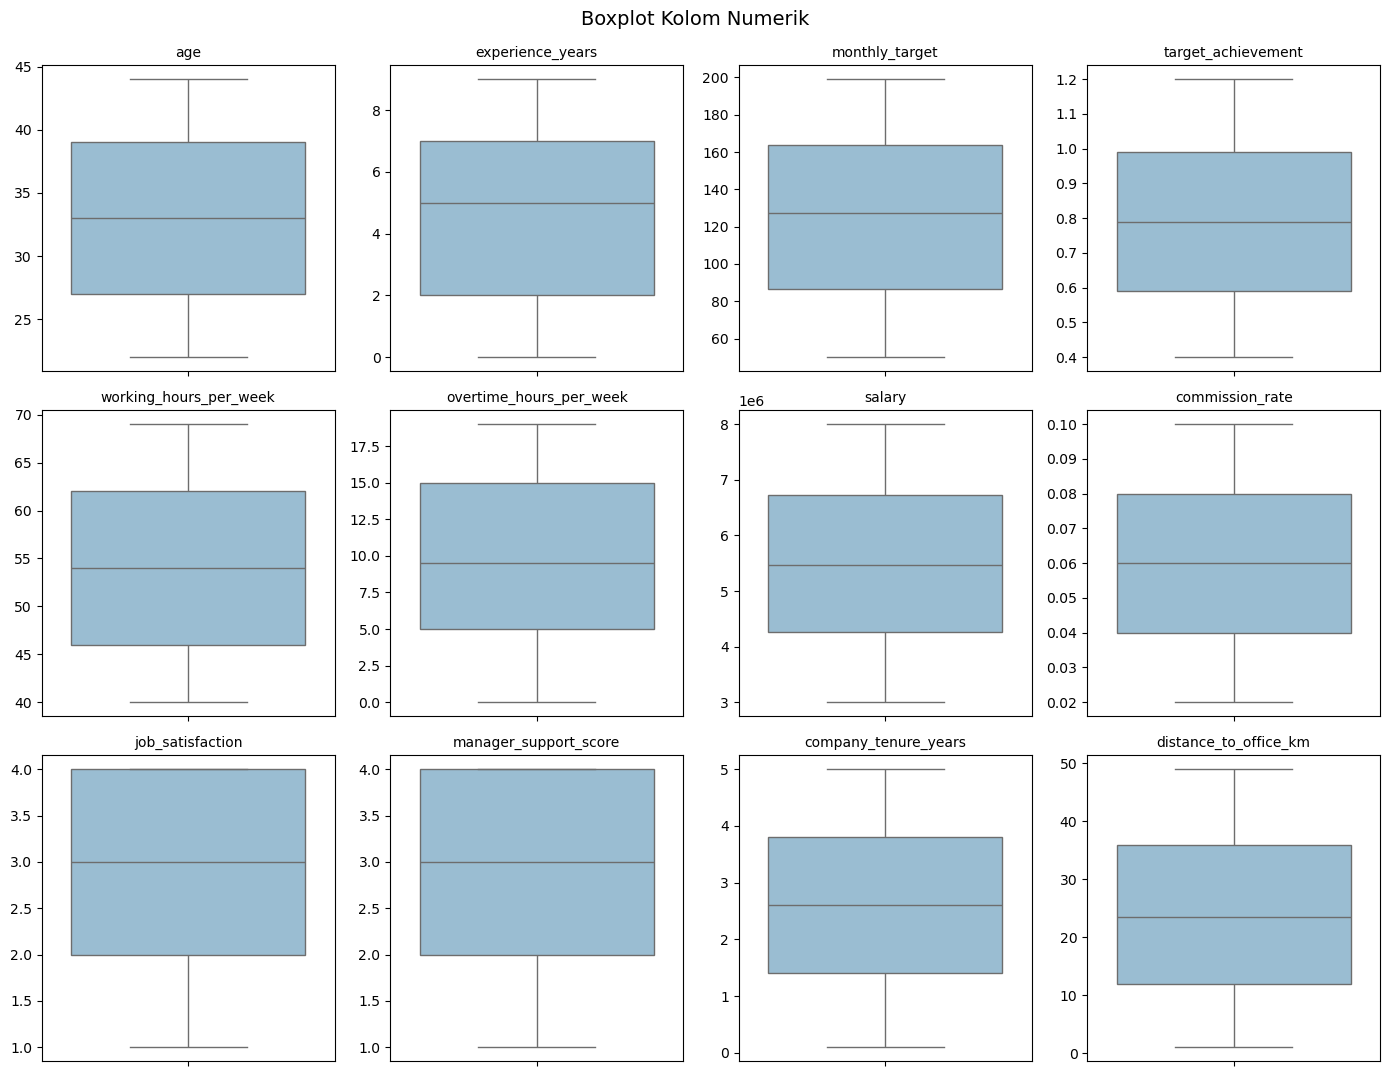

In [10]:
# Visualisasi boxplot untuk kolom numerik
top_cols = outlier_summary.sort_values(by="percent_outlier", ascending=False)["column"]

# Tentukan jumlah subplot per baris (misal 3x3 grid)
n_cols = 4
n_rows = int(np.ceil(len(top_cols) / n_cols))

# Buat figure grid untuk boxplot
plt.figure(figsize=(3.5 * n_cols, 3.5 * n_rows))

for i, col in enumerate(top_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color='#91bfdb', orient='v')
    plt.title(col, fontsize=10)
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()

plt.suptitle("Boxplot Kolom Numerik", fontsize=14, y=1.02)
plt.show()

The dataset its actually good and there's no extreme outliers in dataset

# Inconsistent data

In [11]:
print(df['work_location'].value_counts())
print(df['education'].value_counts())
print(df['gender'].value_counts())
print(df['marital_status'].value_counts())

work_location
Urban       500
Suburban    305
Rural       195
Name: count, dtype: int64
education
Diploma        404
High School    299
Bachelor       297
Name: count, dtype: int64
gender
Male      703
Female    297
Name: count, dtype: int64
marital_status
Single     606
Married    394
Name: count, dtype: int64


From the data extracts, the categories seem consistence

# Anomaly Detection

## Work Experience vs Age is Illogical

There is data where an employee's age is not proportional to their work experience. For example, someone is 25 years old but has 10 years of work experience, which means they started working full-time at the age of 15. Although possible, this is highly unusual in the context of professional data.

In [12]:
# membuat kolom sementara
df['approx_start_age'] = df['age'] - df['experience_years']
unreasonable_start_age_data = df[df['approx_start_age'] < 18]

if unreasonable_start_age_data.empty:
    print("Tidak ada data anomali yang ditemukan dengan kriteria usia mulai bekerja < 18 tahun.")
else:
    # Menampilkan hanya kolom yang relevan agar mudah dibaca
    print("Ditemukan baris-baris berikut yang dianggap anomali:")
    print(unreasonable_start_age_data[['employee_id', 'age', 'experience_years', 'approx_start_age']])

Ditemukan baris-baris berikut yang dianggap anomali:
     employee_id  age  experience_years  approx_start_age
17            18   23                 8                15
20            21   23                 7                16
35            36   24                 7                17
70            71   23                 7                16
90            91   22                 9                13
..           ...  ...               ...               ...
959          960   22                 7                15
968          969   22                 8                14
981          982   22                 6                16
982          983   26                 9                17
999         1000   23                 6                17

[74 rows x 4 columns]


In [13]:
# PENANGANAN: Hapus baris anomali
initial_rows = len(df)
df = df[df['approx_start_age'] >= 18]
cleaned_rows = len(df)
print(f"\n[PENANGANAN] Anomali 2 telah ditangani: {initial_rows - cleaned_rows} baris dengan usia/pengalaman tidak logis telah dihapus.")


[PENANGANAN] Anomali 2 telah ditangani: 74 baris dengan usia/pengalaman tidak logis telah dihapus.


In [14]:
# Menghapus kolom bantu
df = df.drop(columns=['approx_start_age'])

In [15]:
print(f"Jumlah baris data akhir setelah pembersihan: {len(df)}")

Jumlah baris data akhir setelah pembersihan: 926


For the illogical Age vs. Experience data anomaly, it is better to delete it, because we cannot guess the correct value and the amount is likely to be small.

# Exploratory Data Analysis (EDA)

In [16]:
#DATASET OVERVIEW
# =====================================================
print("=== DATASET OVERVIEW ===")
print(f"Jumlah baris dan kolom: {df.shape}")

=== DATASET OVERVIEW ===
Jumlah baris dan kolom: (926, 19)



Target column terdeteksi: 'churn'
churn
1    585
0    341
Name: count, dtype: int64


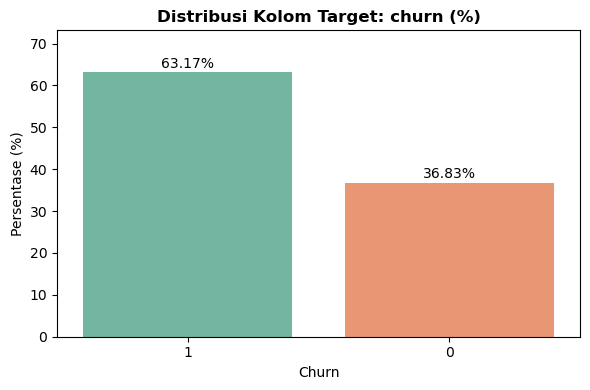

In [17]:
# IDENTIFIKASI TARGET DAN CEK DISTRIBUSINYA
target_col = 'churn'

if target_col in df.columns:
    print(f"\nTarget column terdeteksi: '{target_col}'")

    # Hitung distribusi dalam jumlah
    target_counts = df[target_col].value_counts()
    print(target_counts)

    # Hitung distribusi dalam persen
    target_pct = df[target_col].value_counts(normalize=True) * 100

    # Visualisasi distribusi target dalam persen
    plt.figure(figsize=(6, 4))
    sns.barplot(
        x=target_pct.index.astype(str),
        y=target_pct.values,
        palette="Set2"   # Warna berbeda untuk tiap bar
    )

    plt.title(f"Distribusi Kolom Target: {target_col} (%)", fontsize=12, weight='bold')
    plt.xlabel(target_col.capitalize())
    plt.ylabel("Persentase (%)")
    plt.ylim(0, target_pct.max() + 10)  # Tambahkan ruang untuk label di atas bar
    plt.xticks(rotation=0)

    # Tambahkan label persen di atas tiap bar
    for i, val in enumerate(target_pct.values):
        plt.text(i, val + 1, f"{val:.2f}%", ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

else:
    print("❌ Kolom target tidak ditemukan, silakan tentukan secara manual.")

In [18]:
# Pisahkan fitur numerik dan kategorikal, dengan pengecualian kolom tertentu
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Keluarkan kolom yang tidak relevan dari masing-masing list
if 'employee_id' in numeric_features:
    numeric_features.remove('employee_id')

if 'churn_period' in categorical_features:
    categorical_features.remove('churn_period')

# Tampilkan hasil akhir untuk verifikasi
print("Fitur numerik:", numeric_features)
print("Fitur kategorikal:", categorical_features)

Fitur numerik: ['age', 'experience_years', 'monthly_target', 'target_achievement', 'working_hours_per_week', 'overtime_hours_per_week', 'salary', 'commission_rate', 'job_satisfaction', 'manager_support_score', 'company_tenure_years', 'churn', 'distance_to_office_km']
Fitur kategorikal: ['gender', 'education', 'work_location', 'marital_status']


In [19]:
# Pisahkan fitur selain target, dan drop kolom employee_id serta churn_period
X = df.drop(columns=[target_col, 'employee_id', 'churn_period'], errors='ignore')
y = df[target_col]

# Konversi kategorikal ke numerik sementara untuk perhitungan Mutual Information
X_encoded = X.copy()
for col in categorical_features:
    if col in X_encoded.columns:  # pastikan kolom masih ada di fitur
        X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

# Data Visualization & Analysis

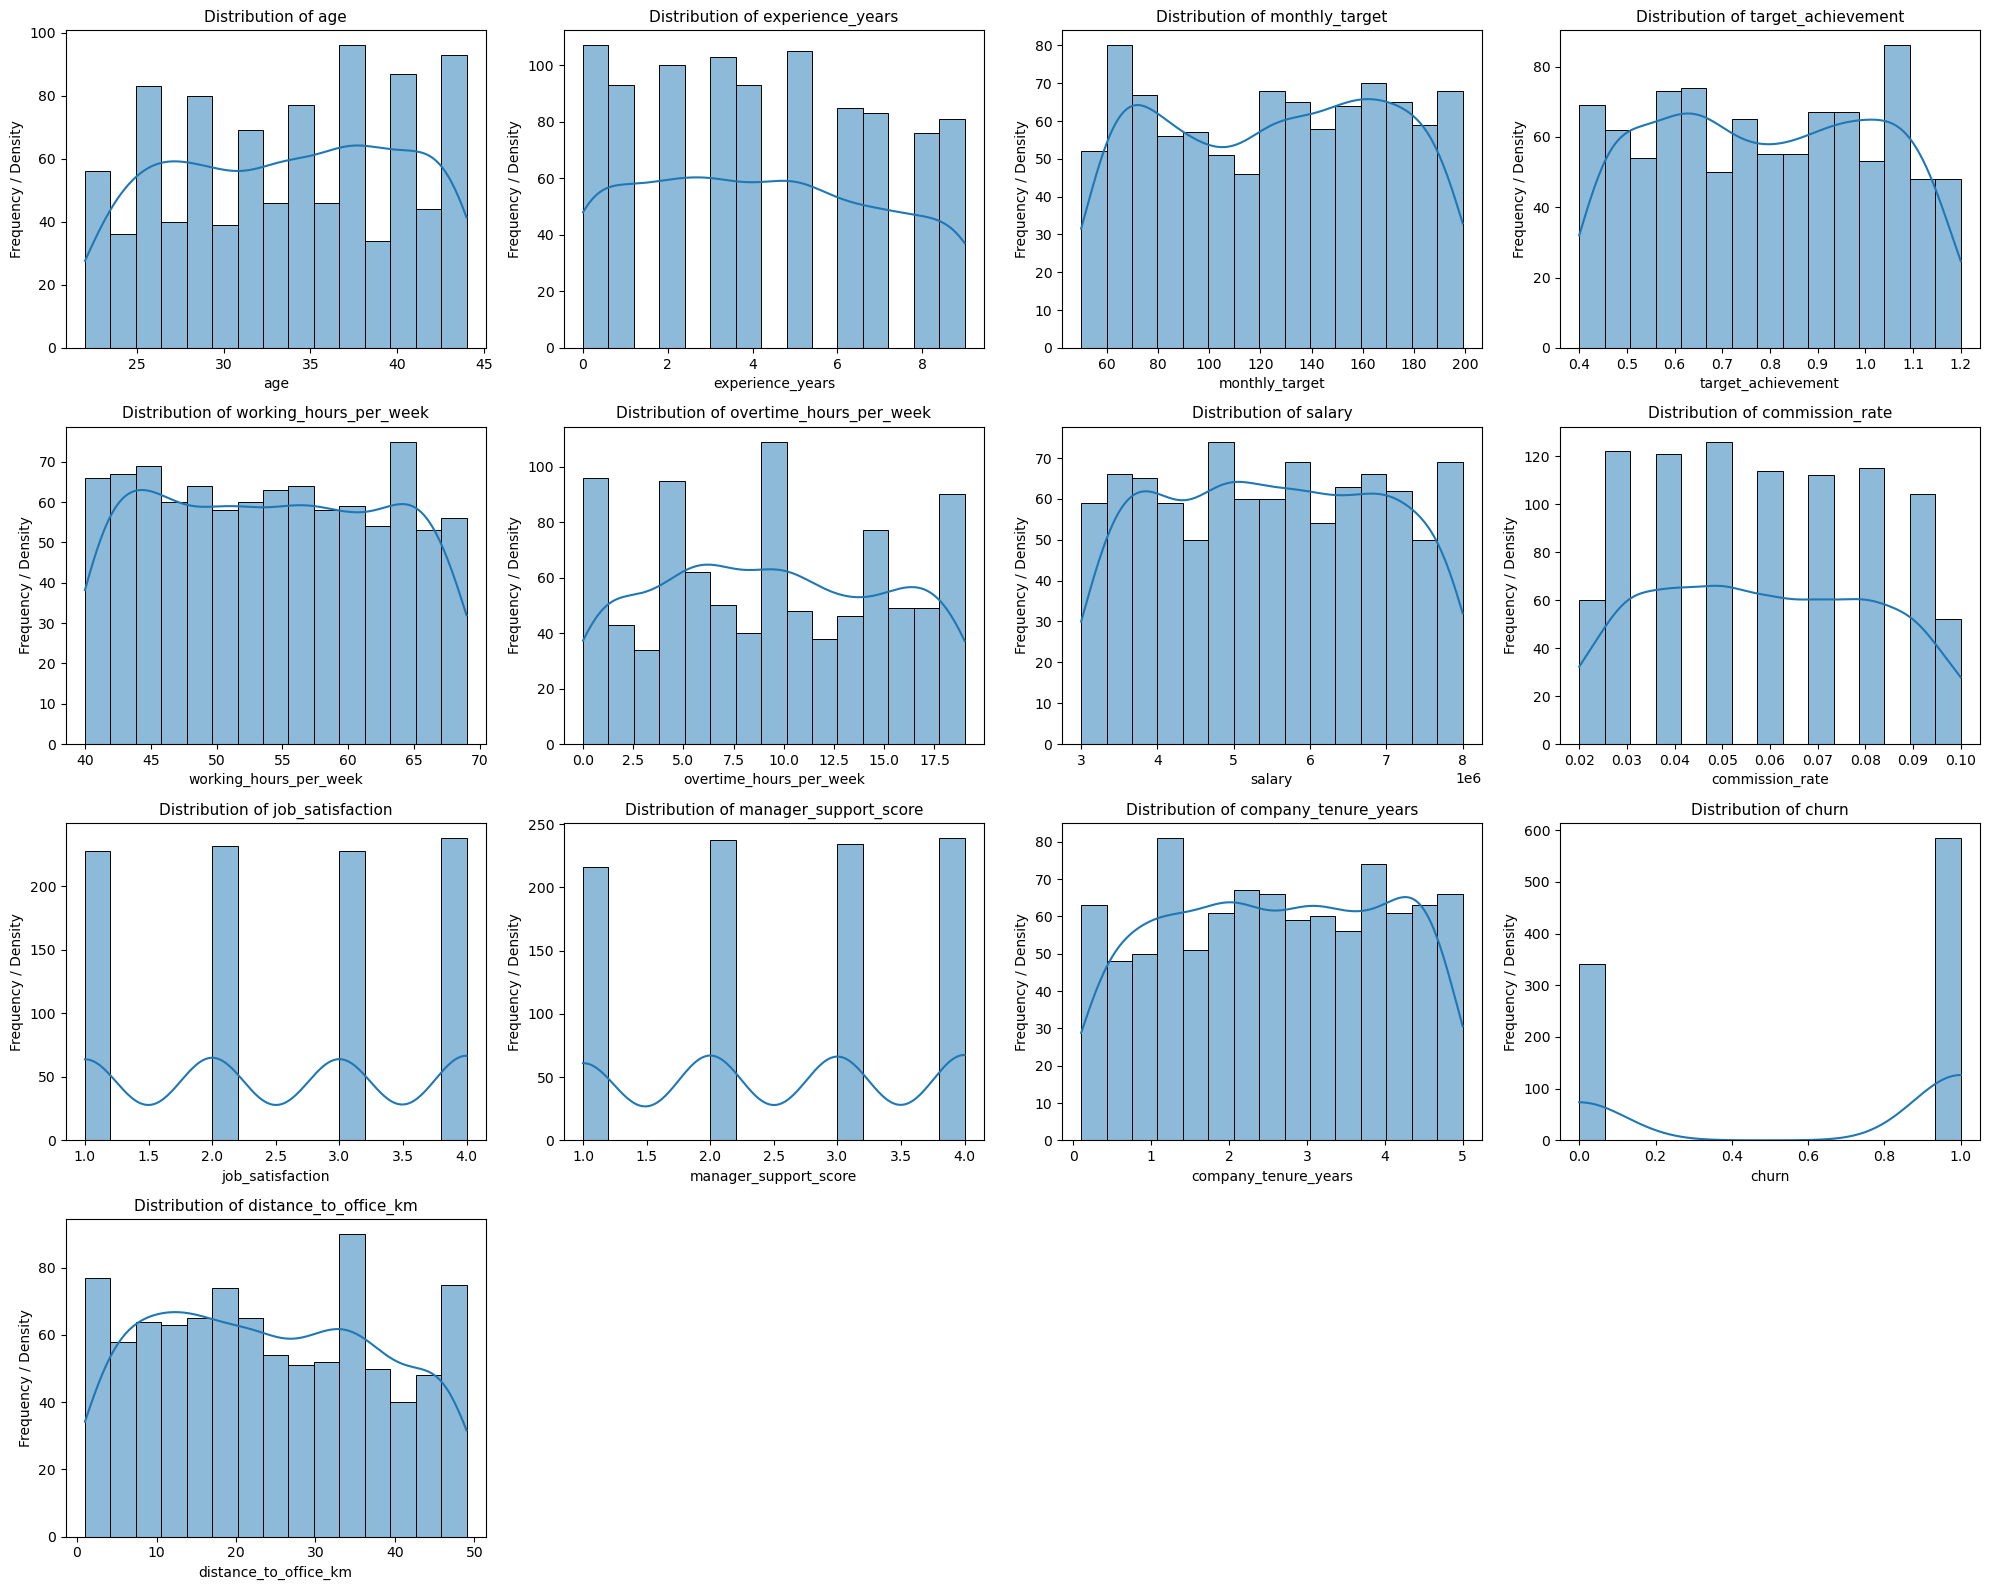

In [20]:
# Visualisasi Univariate Analysis
n_cols = 4
n_rows = (len(numeric_features) + n_cols - 1) // n_cols

# --- Plot Hist & KDE ---
plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numeric_features):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data=df, x=col, bins=15, kde=True, ax=ax, edgecolor='black', linewidth=0.7)
    plt.title(f'Distribution of {col}', fontsize=11)
    plt.xlabel(col)
    plt.ylabel('Frequency / Density')

plt.tight_layout()
plt.show()

The visualization above shows that the data distribution exhibits a multimodal pattern (many peaks). This indicates that the data has characteristics or is diverse. This pattern also indicates that the data likely consists of several distinct population subgroups with non-uniform behavior.

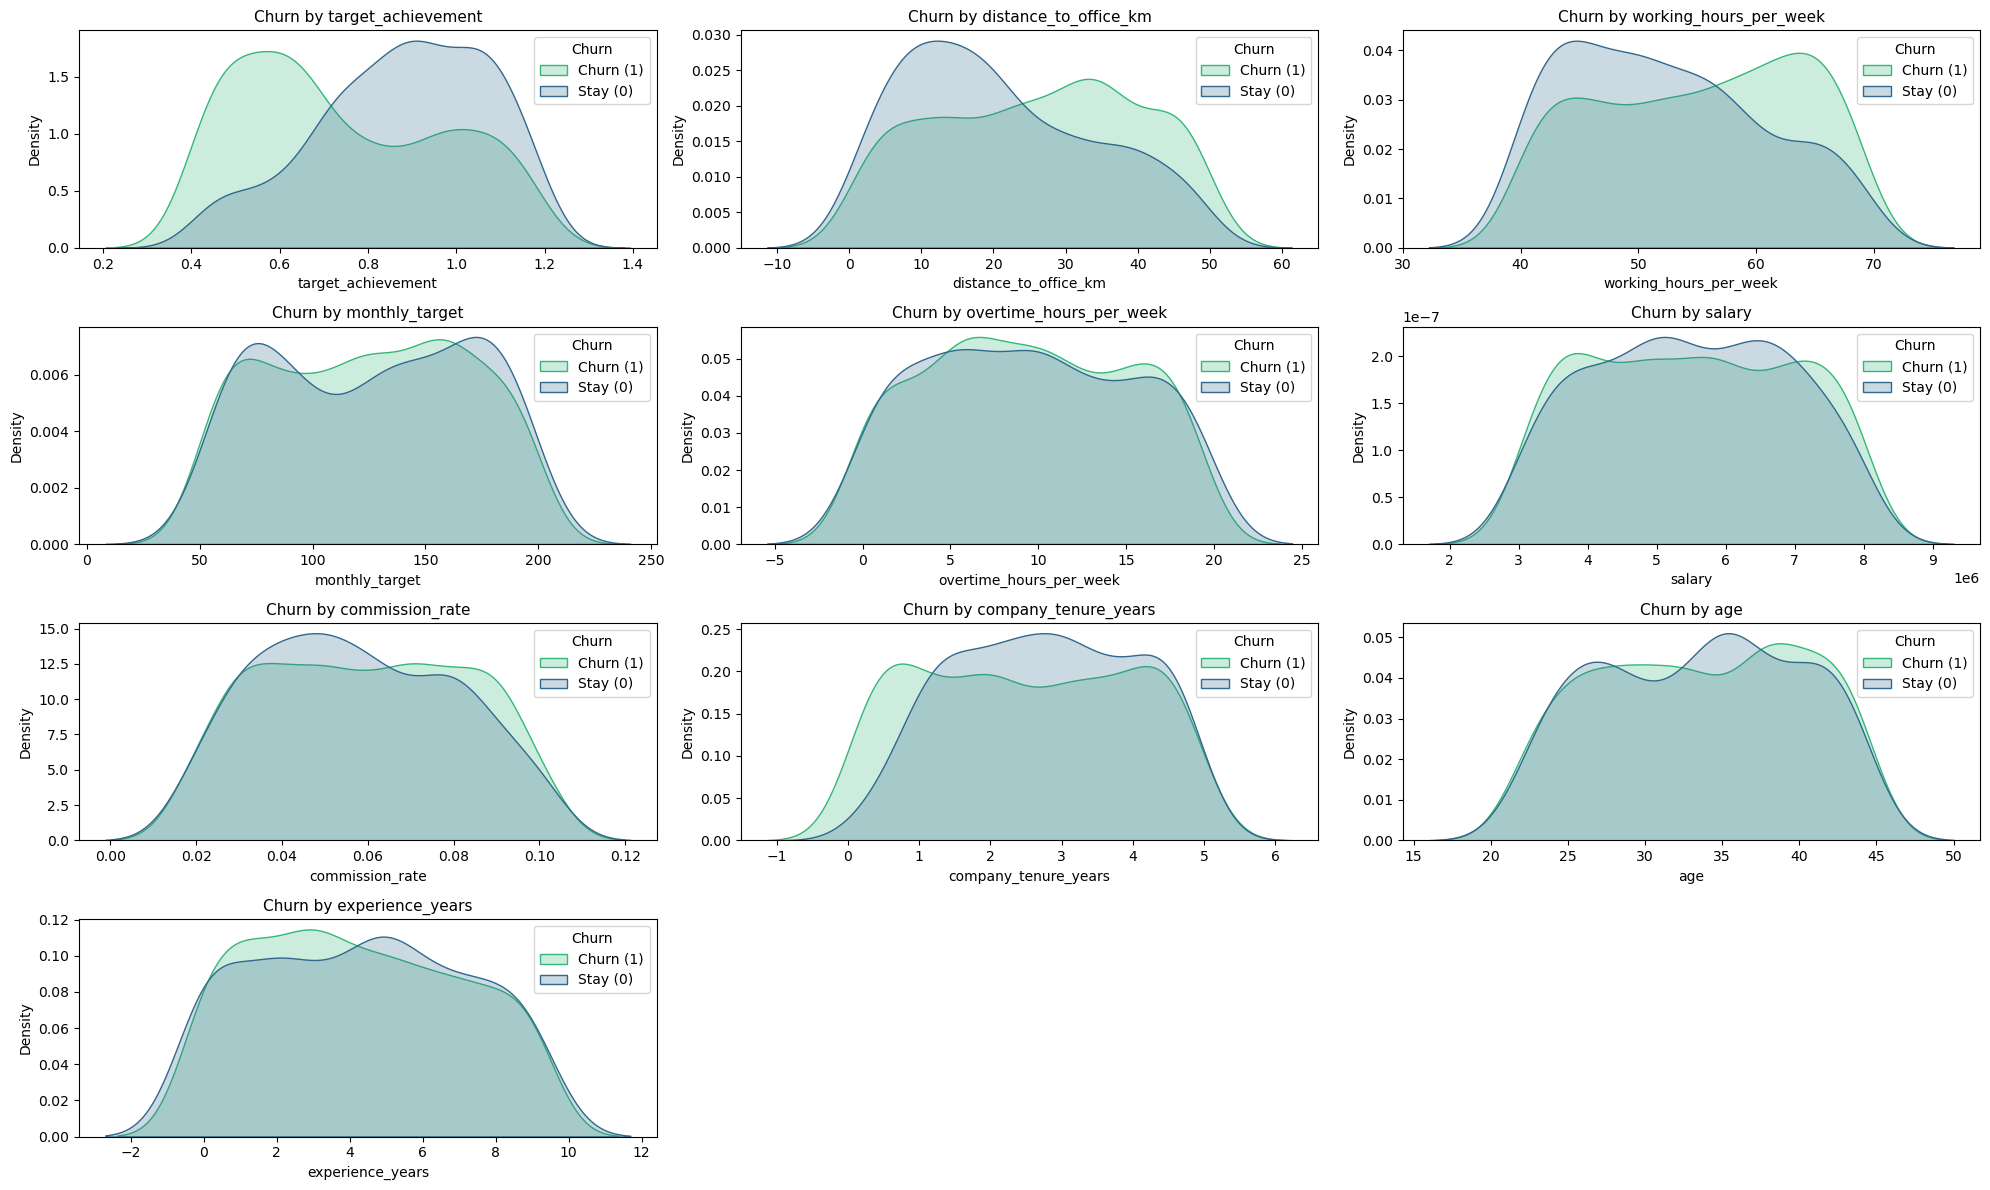

In [21]:
# Visualisasi Multivariate Analysis

# --- Pastikan kolom salary & commission_rate numerik ---
df['salary'] = df['salary'].replace('[^0-9.]', '', regex=True).astype(float)
df['commission_rate'] = df['commission_rate'].replace('%', '', regex=True).astype(float)

# --- Daftar kolom yang ingin diplot ---
features_to_plot_kde = [
    'target_achievement', 'distance_to_office_km', 'working_hours_per_week',
    'monthly_target', 'overtime_hours_per_week', 'salary', 'commission_rate',
    'company_tenure_years', 'age', 'experience_years'
]

# --- Pastikan semua kolom numerik ---
numeric_cols = [col for col in features_to_plot_kde if pd.api.types.is_numeric_dtype(df[col])]

# --- Plot KDE ---
plt.figure(figsize=(20, 12))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, palette='viridis')
    plt.title(f'Churn by {col}', fontsize=11)
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend(title='Churn', labels=['Churn (1)', 'Stay (0)'])

plt.tight_layout()
plt.show()

In general, the factors that clearly drive employee churn are target achievement, distance to the office, and weekly working hours.

Other factors that appear to have an influence include commission rate, work experience and length of service with the company.

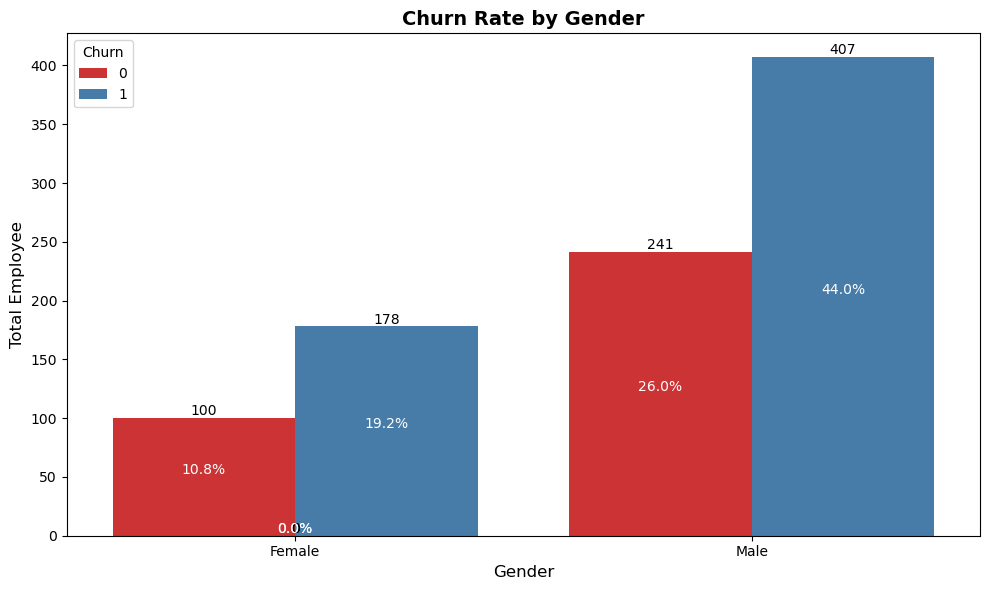

In [22]:
# Multivariate Gender

gender_churn = df.groupby('gender')['churn'].value_counts(normalize=False).rename('employee').reset_index()
total = len(df)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='gender', y='employee', hue='churn', data=gender_churn, palette='Set1')

plt.title('Churn Rate by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Total Employee', fontsize=12)
plt.legend(title='Churn')

# Add text labels for percentages
for p in ax.patches:
  gender_churn_rate = (p.get_height() / total)*100
  ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
  ax.annotate(f'{gender_churn_rate:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()/2.),
            ha='center', va='center', xytext=(0, 5), textcoords='offset points',color='white')

plt.tight_layout()
plt.show()

Male employees are the most likely to churn or leaves. However, the churn rate between male and female employees is very small or almost insignificant.

This means that gender is not the primary factor determining whether an employee leaves or not.

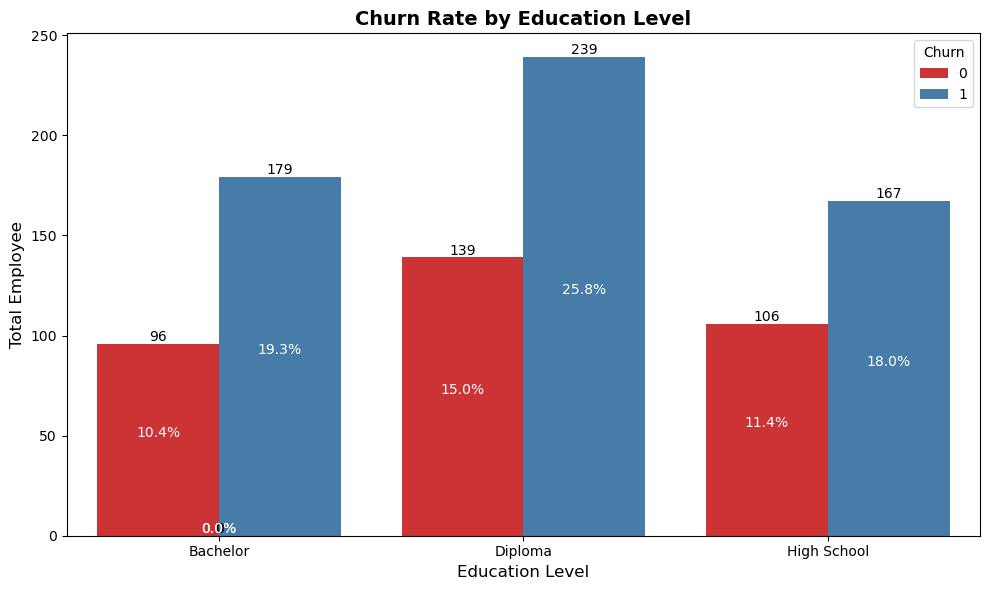

In [23]:
# Multivariate Education

education_churn = df.groupby('education')['churn'].value_counts(normalize=False).rename('employee').reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='education', y='employee', hue='churn', data=education_churn, palette='Set1')

plt.title('Churn Rate by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Total Employee', fontsize=12)

for p in ax.patches:
  churn_rate = (p.get_height() / total)*100
  ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
  ax.annotate(f'{churn_rate:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()/2.),
            ha='center', va='center', xytext=(0, 5), textcoords='offset points',color='white')

plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Highest Risk: Employees with a Bachelor's degree (S1) have the highest likelihood of leaving (65.1%)

Highest Volume: Despite their relatively moderate churn rate, employees with a Diploma contributed the largest churn volume (239 people) because they are the largest employee group.

Lowest Risk: Employees with a High School education have the lowest risk of churn.

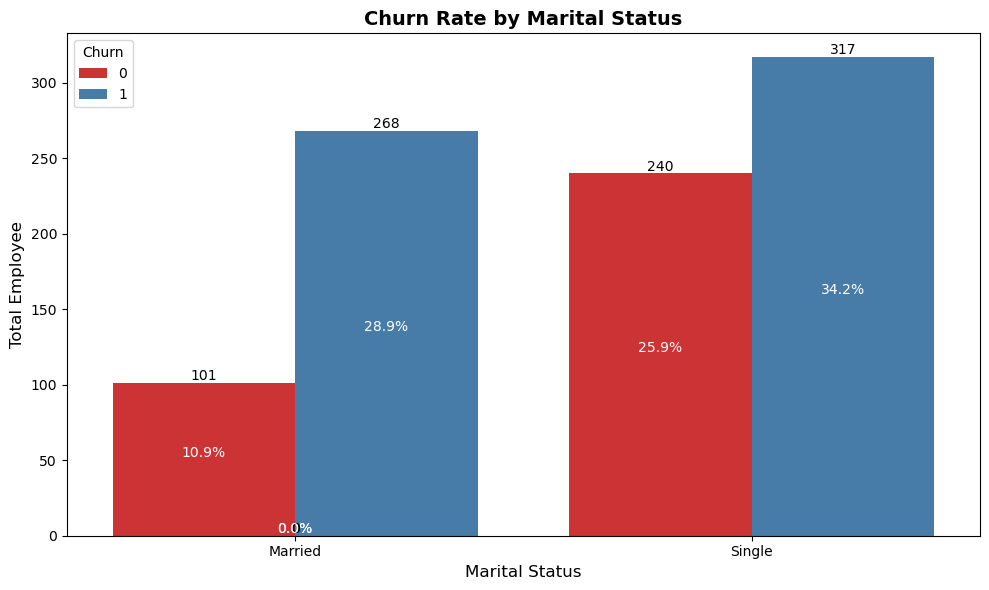

In [24]:
# Multivariate Marital

marital_churn = df.groupby('marital_status')['churn'].value_counts(normalize=False).rename('employee').reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='marital_status', y='employee', hue='churn', data=marital_churn, palette='Set1')

plt.title('Churn Rate by Marital Status', fontsize=14, fontweight='bold')
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Total Employee', fontsize=12)
plt.legend(title='Churn')

# Add text labels for percentages
for p in ax.patches:
  churn_rate = (p.get_height() / total)*100
  ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
  ax.annotate(f'{churn_rate:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()/2.),
            ha='center', va='center', xytext=(0, 5), textcoords='offset points',color='white')

plt.tight_layout()
plt.show()

Married employees had a significantly higher chance of leaving at 72.6% compared to single employees at 56.9%.

Married status is a strong indicator of churn risk in this company. Further research is needed to investigate the reasons behind the high churn rate in this group.

Factors such as lack of work flexibility or work-life balance pressures may be contributing factors.

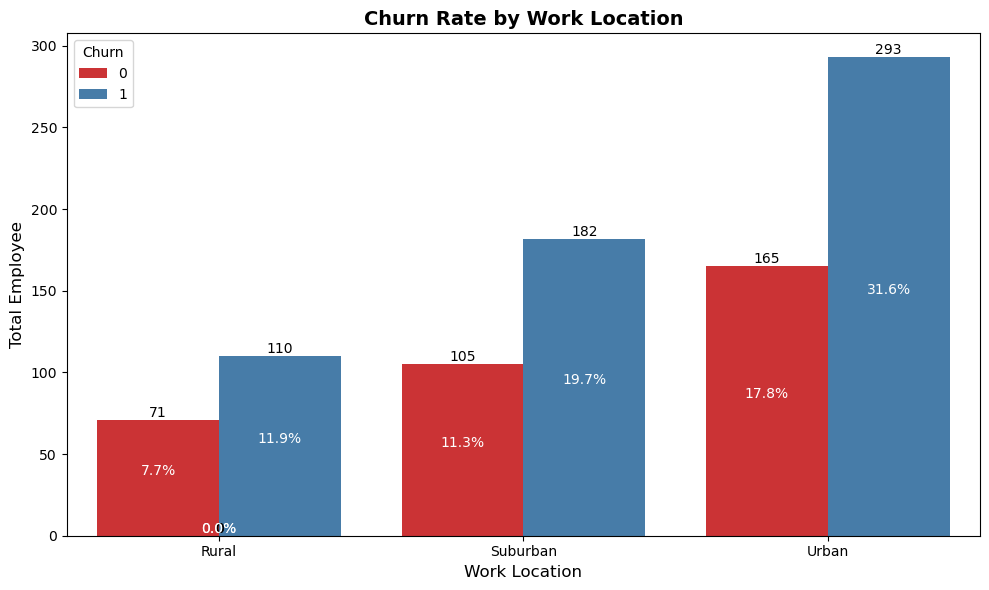

In [25]:
# Multivariate Location

location_churn = df.groupby('work_location')['churn'].value_counts(normalize=False).rename('employee').reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='work_location', y='employee', hue='churn', data=location_churn, palette='Set1')

plt.title('Churn Rate by Work Location', fontsize=14, fontweight='bold')
plt.xlabel('Work Location', fontsize=12)
plt.ylabel('Total Employee', fontsize=12)
plt.legend(title='Churn')

# Add text labels for percentages
for p in ax.patches:
  churn_rate = (p.get_height() / total)*100
  ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
  ax.annotate(f'{churn_rate:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()/2.),
            ha='center', va='center', xytext=(0, 5), textcoords='offset points',color='white')

plt.tight_layout()
plt.show()

Employees in urban locations had the highest churn volume and a relatively higher churn rate 63.9%.

Meanwhile, employees in suburban locations had a churn rate at 63.4% and Employees in rural locations had the lowest churn rate 60.8%.

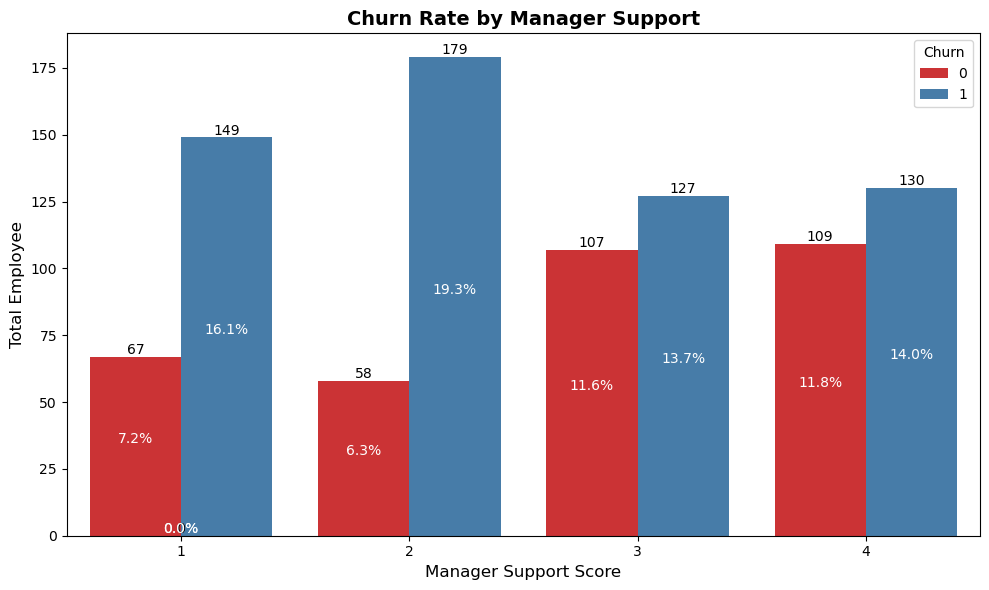

In [26]:
# Multivariate Manager Support

manager_support_churn = df.groupby('manager_support_score')['churn'].value_counts(normalize=False).rename('employee').reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='manager_support_score', y='employee', hue='churn', data=manager_support_churn, palette='Set1')

plt.title('Churn Rate by Manager Support', fontsize=14, fontweight='bold')
plt.xlabel('Manager Support Score', fontsize=12)
plt.ylabel('Total Employee', fontsize=12)
plt.legend(title='Churn')

# Add text labels for percentages
for p in ax.patches:
  churn_rate = (p.get_height() / total)*100
  ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
  ax.annotate(f'{churn_rate:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()/2.),
            ha='center', va='center', xytext=(0, 5), textcoords='offset points',color='white')

plt.tight_layout()
plt.show()

Manager support is a very strong predictor of churn:

There is a significant difference in churn risk between the low support (Scores 1 & 2) and high support (Scores 3 & 4) groups, with a difference of approximately 21 percentage points between the highest (75.5%) and lowest (54.3%).

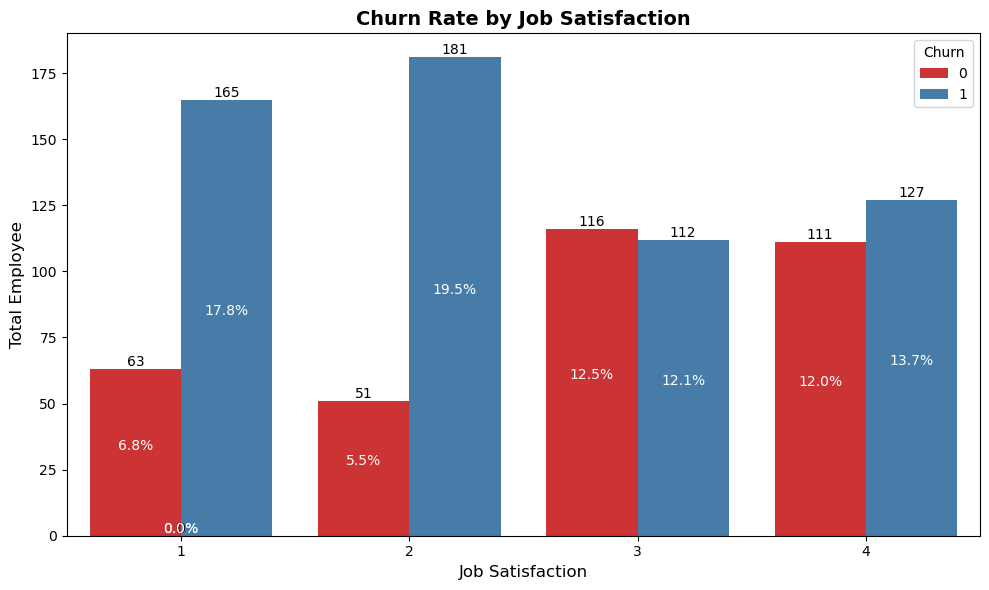

In [27]:
# Multivariate Job Satisfication

satisfaction_churn = df.groupby('job_satisfaction')['churn'].value_counts(normalize=False).rename('employee').reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='job_satisfaction', y='employee', hue='churn', data=satisfaction_churn, palette='Set1')

plt.title('Churn Rate by Job Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction', fontsize=12)
plt.ylabel('Total Employee', fontsize=12)
plt.legend(title='Churn')

# Add text labels for percentages
for p in ax.patches:
  churn_rate = (p.get_height() / total)*100
  ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
  ax.annotate(f'{churn_rate:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()/2.),
            ha='center', va='center', xytext=(0, 5), textcoords='offset points',color='white')

plt.tight_layout()
plt.show()

Job satisfaction is also a very strong determinant of churn:

There is a significant difference in churn risk, reaching 28.9 percentage points between the highest risk (Scores 1&2: 78.0%) and the lowest (Scores 3&4: 49.1%).

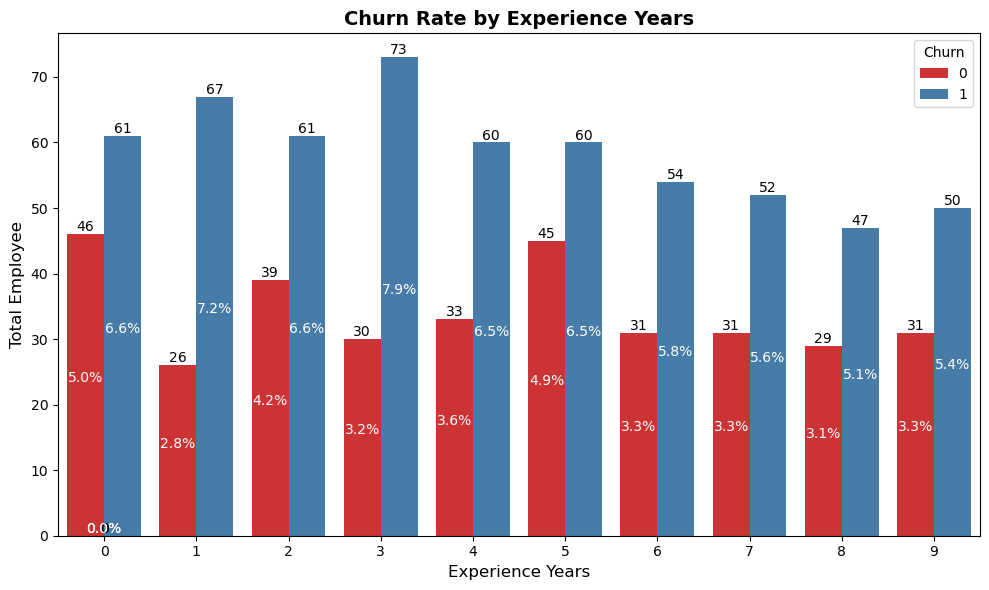

In [28]:
# Multivariate Experience Years

years_churn = df.groupby('experience_years')['churn'].value_counts(normalize=False).rename('employee').reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='experience_years', y='employee', hue='churn', data=years_churn, palette='Set1')

plt.title('Churn Rate by Experience Years', fontsize=14, fontweight='bold')
plt.xlabel('Experience Years', fontsize=12)
plt.ylabel('Total Employee', fontsize=12)
plt.legend(title='Churn')

# Add text labels for percentages
for p in ax.patches:
  churn_rate = (p.get_height() / total)*100
  ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
  ax.annotate(f'{churn_rate:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()/2.),
            ha='center', va='center', xytext=(0, 5), textcoords='offset points',color='white')

plt.tight_layout()
plt.show()

The overall churn risk is very high early in a career. Employees with 0 to 4 years of experience all have relative churn rates above 57%, with peaks in the first (72.0%) and third years (70.9%).

# Feature Engineering

In [29]:
# OVERTIME RATIO
# Measures how much of total weekly working time is spent in overtime.
df['overtime_ratio'] = df['overtime_hours_per_week'] / df['working_hours_per_week']

# BURNOUT SCORE
# Combines overtime intensity and low job satisfaction into a single stress metric.
df['burnout_score'] = df['overtime_ratio'] * (1 - df['job_satisfaction'] / 5)

# ACHIEVEMENT STRESS
# Captures the frustration of working overtime but still missing targets.
df['achievement_stress'] = (1 - df['target_achievement']) * df['overtime_ratio']
df['achievement_stress'] = df['achievement_stress'].clip(lower=0)  # No negative stress

# ACHIEVE STATUS (binary)
# Indicates whether the employee met or exceeded their performance target.
df['achieve_status'] = (df['target_achievement'] >= 1).astype(int)

# LOYALTY INDEX
# Represents the proportion of an employee's total career spent at the company.
df['loyalty_index'] = df['company_tenure_years'] / (df['experience_years'] + 1)

# DISTANCE STRESS (adjusted by marital status)
# Reflects commuting stress, adjusted for family obligations and manager support.
df['distance_stress'] = df['distance_to_office_km'] / (df['manager_support_score'] + 1)

def adjust_distance_stress(row):
    if row['marital_status'] == 'Married':
        return row['distance_stress'] * 1.2
    else:
        return row['distance_stress'] * 1

df['distance_stress_adjusted'] = df.apply(adjust_distance_stress, axis=1)

# PROMOTION POTENTIAL
# Balances job satisfaction, performance, and tenure using a log scale to reduce saturation.
df['promotion_potential'] = (df['job_satisfaction'] + 2 * df['target_achievement']) * np.log(df['company_tenure_years'] + 1)

# STRESS INDEX
# Overall stress index combining workload, performance pressure, and commute strain.
# 0.01 scaling keeps commuting influence proportional to other stress sources.
df['stress_index'] = df['burnout_score'] + df['achievement_stress'] + 0.01 * df['distance_stress_adjusted']

# CHECK RESULTS
feature_cols = [
    'overtime_ratio', 'burnout_score', 'achievement_stress', 'achieve_status',
    'loyalty_index', 'distance_stress_adjusted', 'promotion_potential', 'stress_index'
]

# Show statistical summary
display(df[feature_cols].describe())

,overtime_ratio,burnout_score,achievement_stress,achieve_status,loyalty_index,distance_stress_adjusted,promotion_potential,stress_index
count,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000
mean,0.177736,0.088896,0.041487,0.240821,0.786133,8.228567,4.870974,0.212669
std,0.111940,0.073737,0.049678,0.427813,0.880231,5.913164,2.415961,0.119043
min,0.000000,0.000000,0.000000,0.000000,0.012500,0.240000,0.285931,0.002400
25%,0.086957,0.031484,0.000000,0.000000,0.275000,3.616667,3.083590,0.122438
50%,0.170732,0.070088,0.022743,0.000000,0.500000,7.100000,4.696336,0.190986
75%,0.262295,0.128429,0.066846,0.000000,0.900000,11.000000,6.712037,0.279642
max,0.463415,0.361905,0.256500,1.000000,4.900000,29.400000,10.784519,0.751500


* overtime_ratio — Measures how much of total weekly working time is spent in overtime, indicating workload intensity.
* burnout_score — Captures stress from high overtime combined with low job satisfaction, representing burnout risk.
* achievement_stress — Reflects frustration from working overtime but still missing performance targets.
* achieve_status — A binary flag showing whether an employee met or exceeded their target (1 = yes, 0 = no).
* loyalty_index — Represents the proportion of an employee’s total career spent in the current company, showing attachment level.
* distance_stress_adjusted — Indicates commuting stress scaled by manager support and marital status sensitivity.
* promotion_potential — Estimates growth opportunity using job satisfaction, performance, and log-scaled tenure.
* stress_index — A composite indicator combining burnout, achievement stress, and commute fatigue into total stress level.

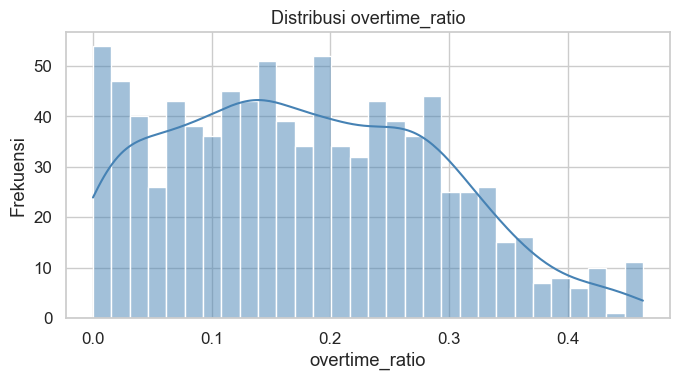

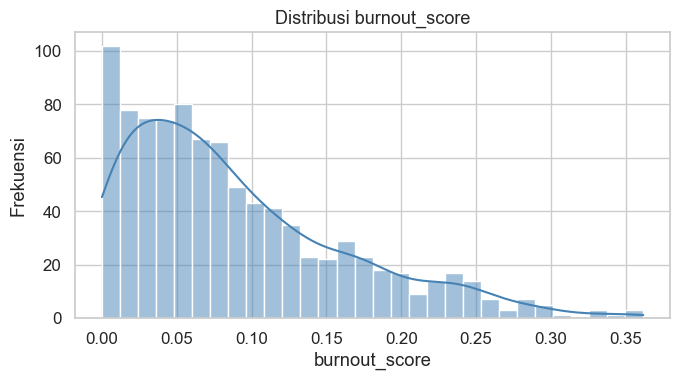

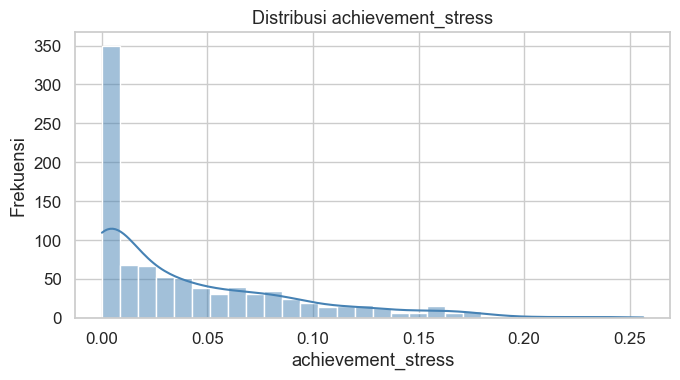

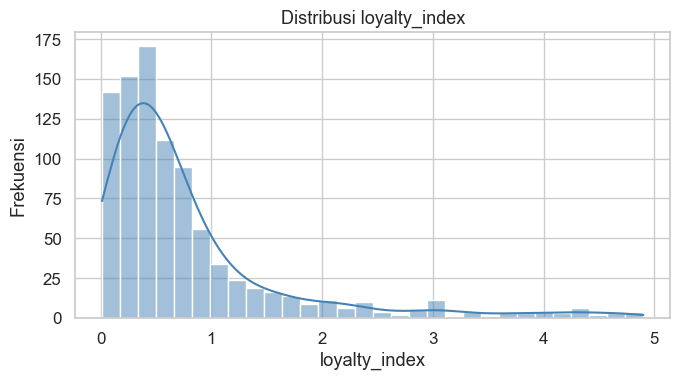

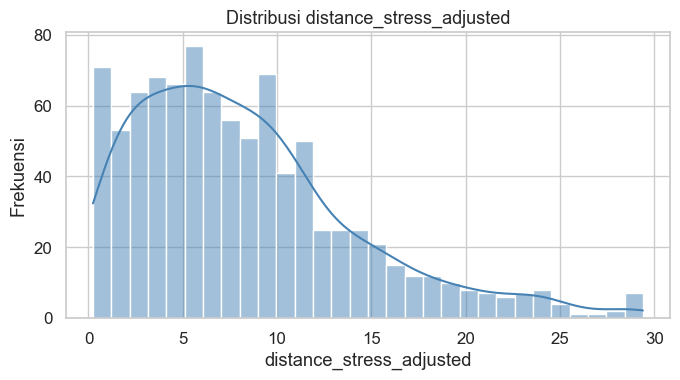

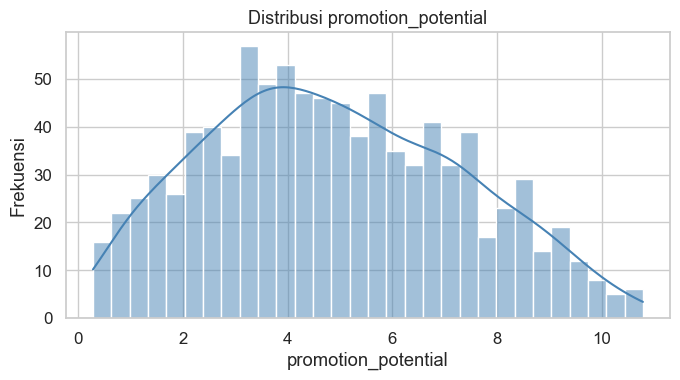

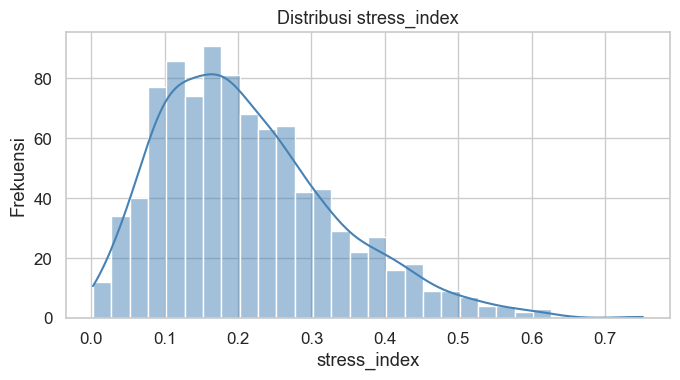

In [30]:
# Visualisasi fitur baru

sns.set(style="whitegrid", palette="viridis", font_scale=1.1)
plt.rcParams['figure.figsize'] = (8, 4)

# List fitur baru
feature_cols = [
    'overtime_ratio', 'burnout_score', 'achievement_stress', 'achieve_status',
    'loyalty_index', 'distance_stress_adjusted', 'promotion_potential', 'stress_index'
]

# Plot histogram + KDE untuk fitur numerik
numeric_features = [col for col in feature_cols if df[col].dtype != 'object' and df[col].nunique() > 2]

for col in numeric_features:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribusi {col}', fontsize=13)
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()

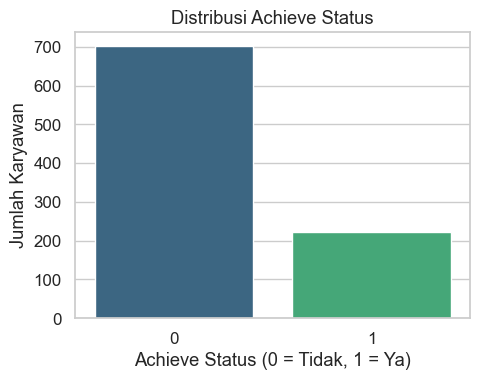

In [31]:
# Visualisasi Bar Chart

plt.figure(figsize=(5,4))
sns.countplot(x='achieve_status', data=df, palette='viridis')
plt.title('Distribusi Achieve Status')
plt.xlabel('Achieve Status (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Karyawan')
plt.tight_layout()
plt.show()

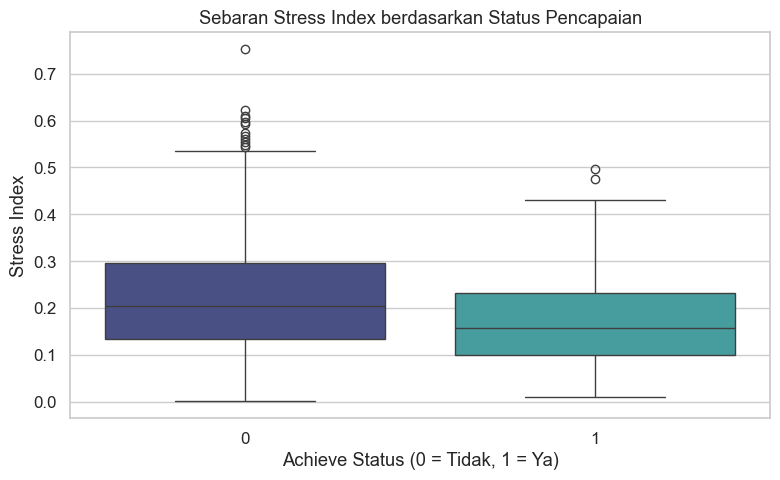

In [32]:
# Visualisasi boxplot

plt.figure(figsize=(8,5))
sns.boxplot(x='achieve_status', y='stress_index', data=df, palette='mako')
plt.title('Sebaran Stress Index berdasarkan Status Pencapaian')
plt.xlabel('Achieve Status (0 = Tidak, 1 = Ya)')
plt.ylabel('Stress Index')
plt.tight_layout()
plt.show()

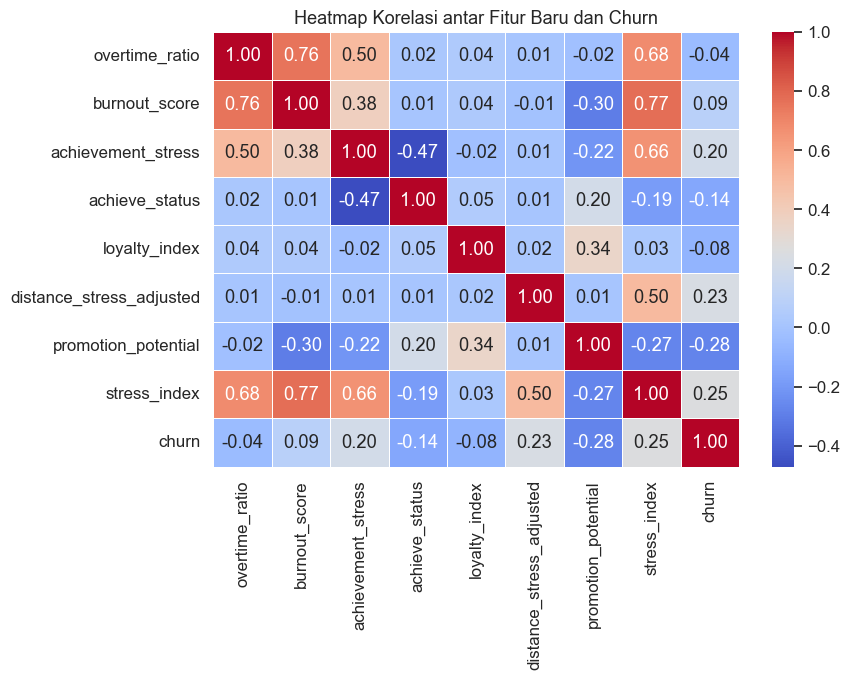

In [33]:
# Korelasi fitur baru dengan target

plt.figure(figsize=(9,7))
corr_matrix = df[feature_cols + ['churn']].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Heatmap Korelasi antar Fitur Baru dan Churn', fontsize=13)
plt.tight_layout()
plt.show()

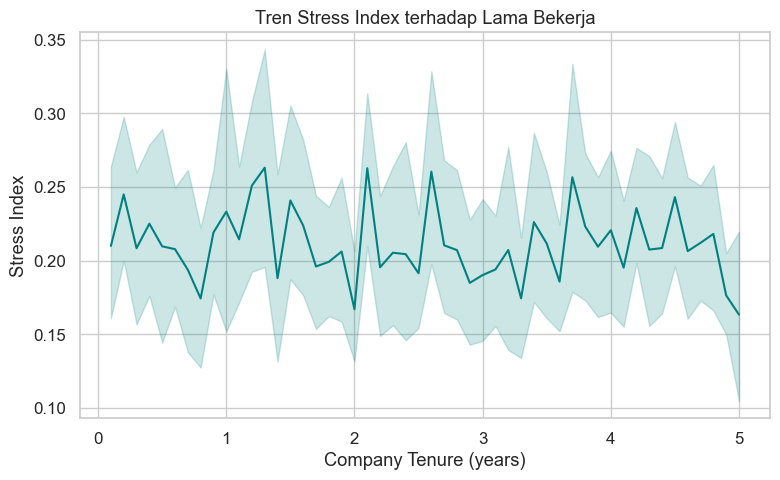

In [34]:
# Visualisasi Line chart (tren stress terhadap tenure)

plt.figure(figsize=(8,5))
sns.lineplot(
    x='company_tenure_years',
    y='stress_index',
    data=df.sort_values('company_tenure_years'),
    color='teal'
)
plt.title('Tren Stress Index terhadap Lama Bekerja')
plt.xlabel('Company Tenure (years)')
plt.ylabel('Stress Index')
plt.tight_layout()
plt.show()


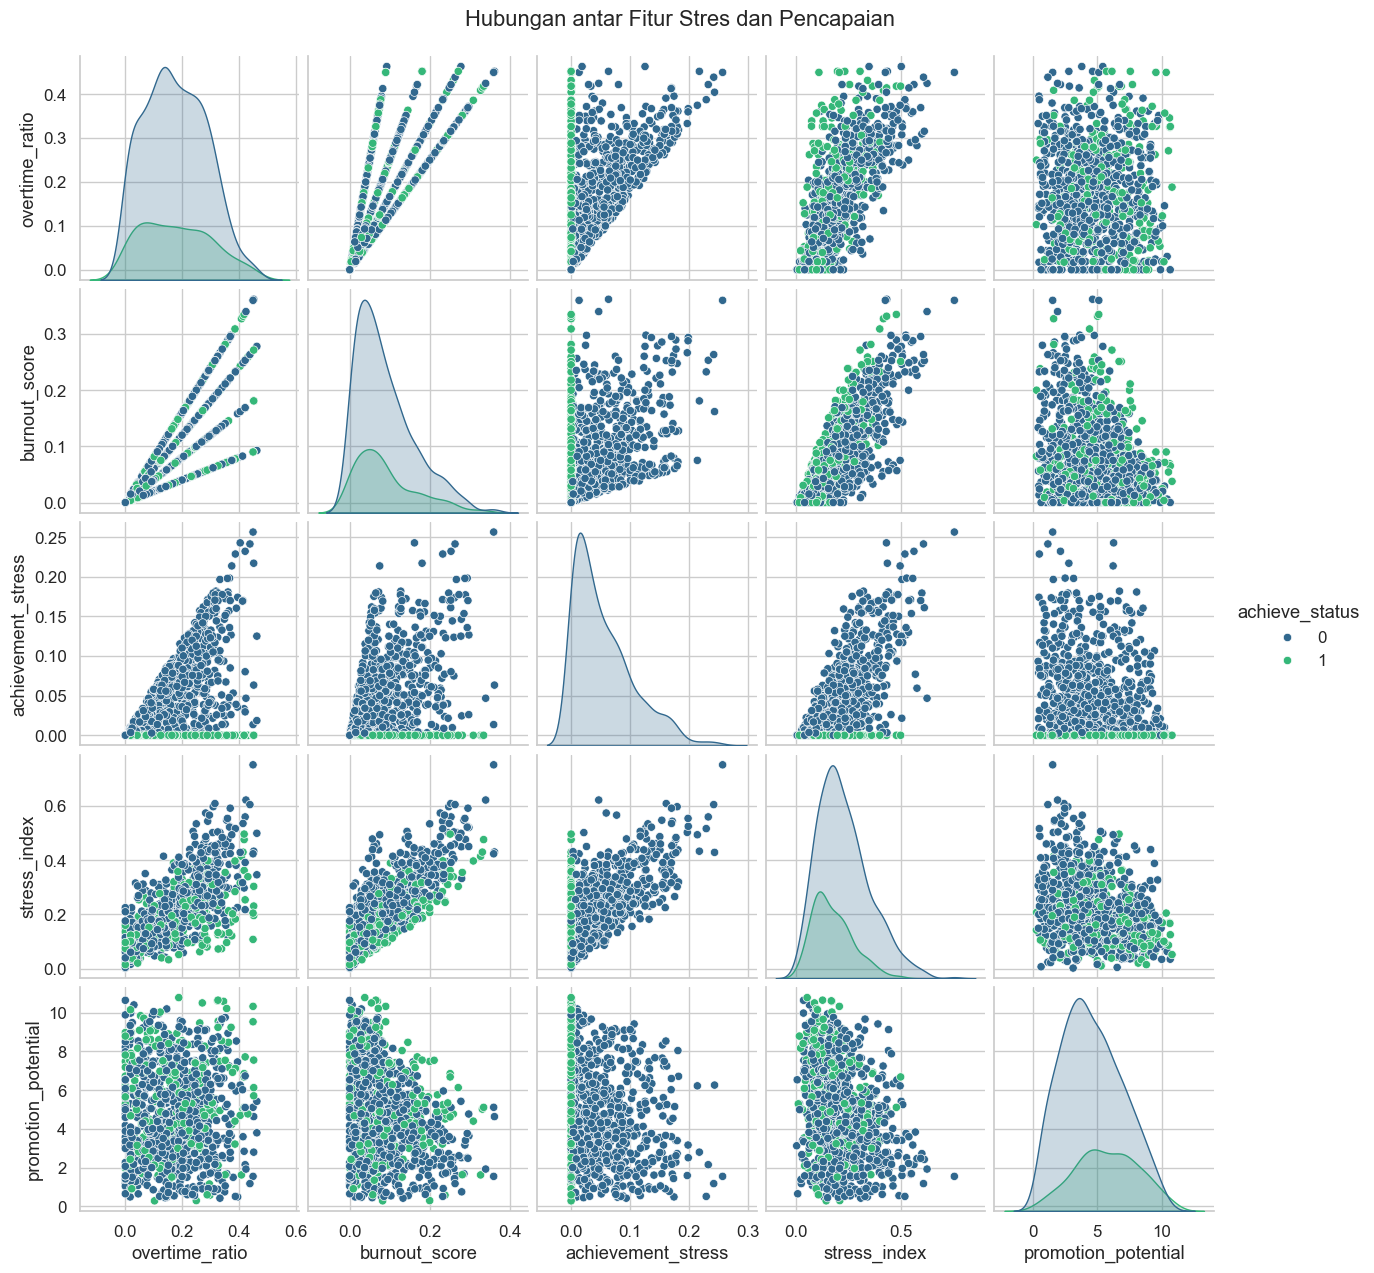

In [35]:
# Visualisasi Pairplot

sns.pairplot(
    df,
    vars=['overtime_ratio', 'burnout_score', 'achievement_stress', 'stress_index', 'promotion_potential'],
    hue='achieve_status',
    diag_kind='kde',
    palette='viridis'
)
plt.suptitle('Hubungan antar Fitur Stres dan Pencapaian', y=1.02)
plt.show()

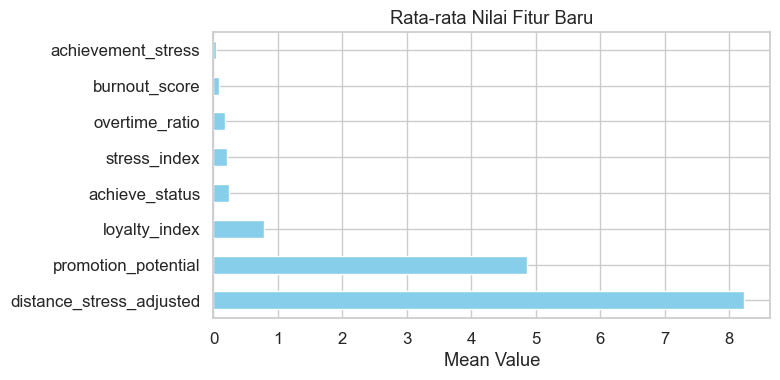

In [36]:
df[feature_cols].mean().sort_values(ascending=False).plot(
    kind='barh', color='skyblue', figsize=(8,4), title='Rata-rata Nilai Fitur Baru'
)
plt.xlabel('Mean Value')
plt.tight_layout()
plt.show()

Insight Tambahan :

Burnout tinggi saat overtime_ratio > 0.3
Achievement stress cenderung tinggi pada pegawai yang tidak mencapai target
Stress index meningkat seiring tenure (loyal tapi stres tinggi)
Korelasi kuat antara burnout_score dan stress_index

# Bivariate Analysis (New Fitur vs Target)

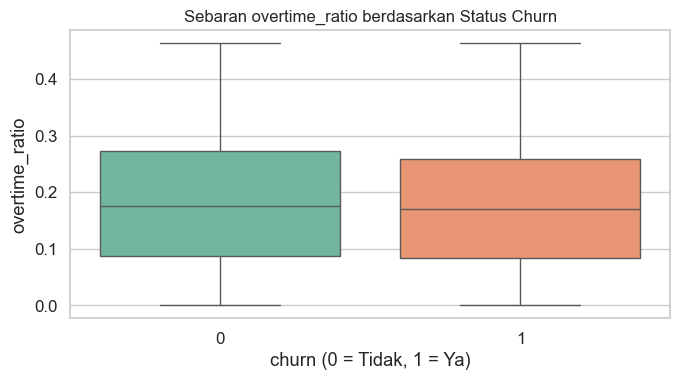

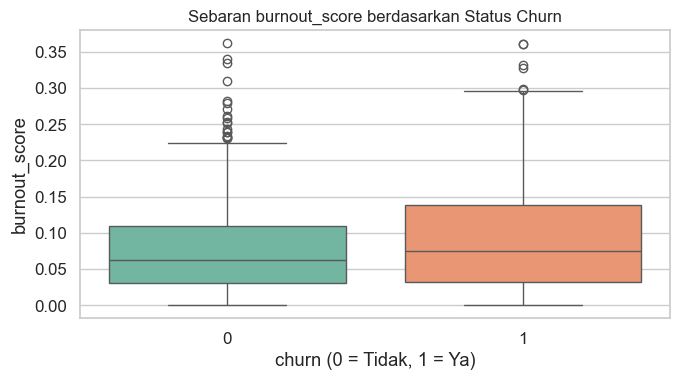

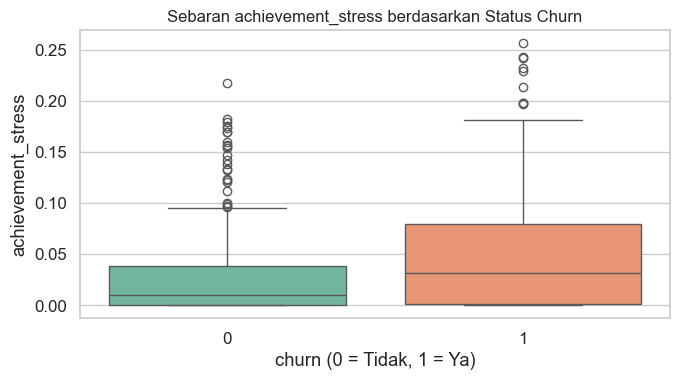

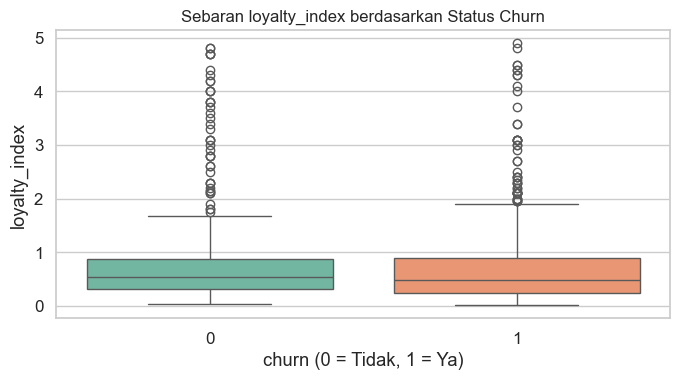

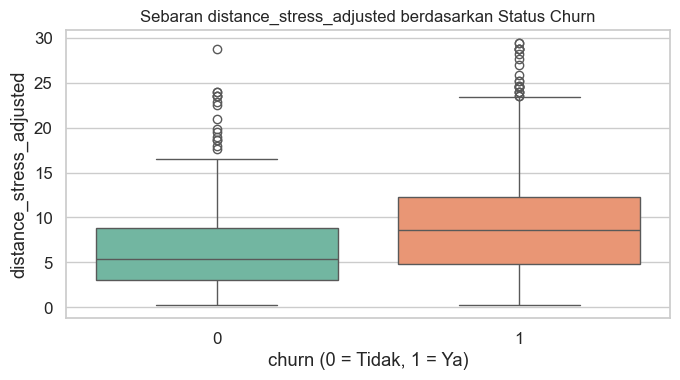

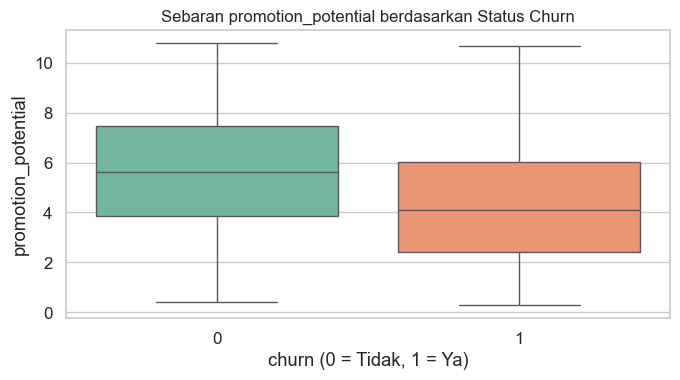

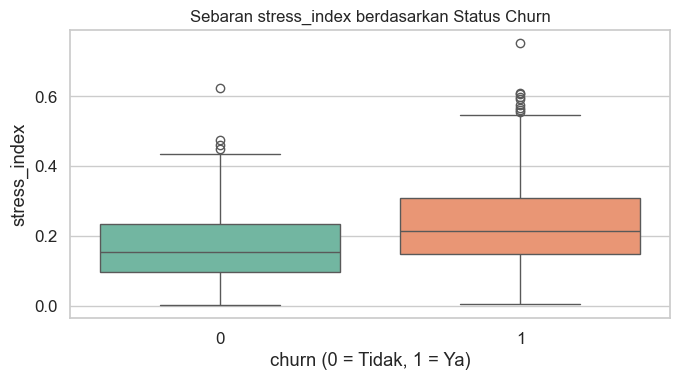

In [37]:
numeric_features = [col for col in feature_cols if df[col].nunique() > 2]

for col in numeric_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(
        x='churn',
        y=col,
        data=df,
        palette='Set2'
    )
    plt.title(f'Sebaran {col} berdasarkan Status Churn', fontsize=12)
    plt.xlabel('churn (0 = Tidak, 1 = Ya)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

<Figure size 1000x700 with 0 Axes>

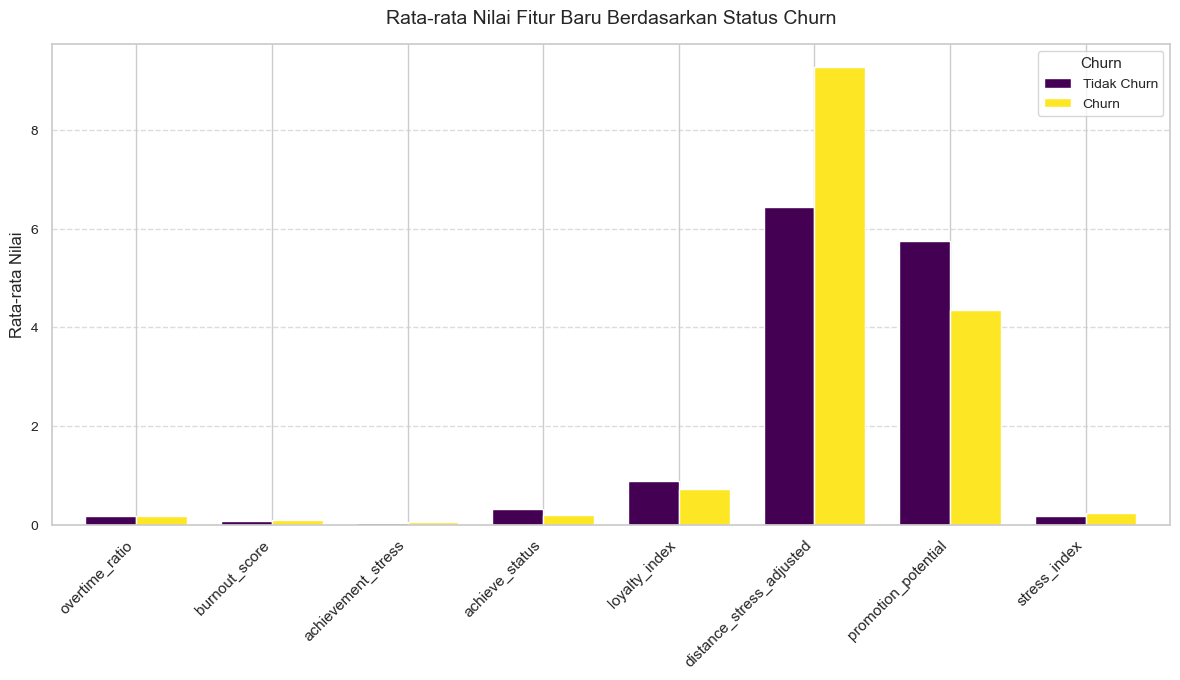

In [38]:
# Hitung rata-rata tiap fitur berdasarkan status churn
mean_features = df.groupby('churn')[feature_cols].mean().T

plt.figure(figsize=(10, 7))
mean_features.plot(
    kind='bar',
    figsize=(12, 7),        
    colormap='viridis',
    width=0.75
)

plt.title('Rata-rata Nilai Fitur Baru Berdasarkan Status Churn', fontsize=14, pad=15)
plt.ylabel('Rata-rata Nilai', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=10)
plt.legend(title='Churn', labels=['Tidak Churn', 'Churn'], fontsize=10, title_fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

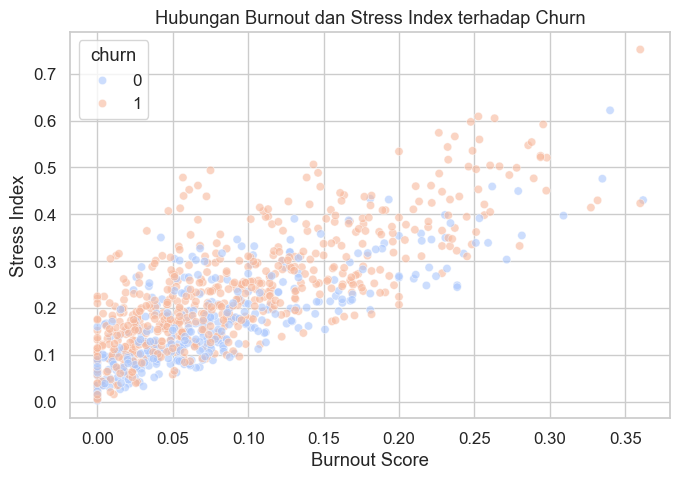

In [39]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='burnout_score',
    y='stress_index',
    hue='churn',
    palette='coolwarm',
    alpha=0.6
)
plt.title('Hubungan Burnout dan Stress Index terhadap Churn')
plt.xlabel('Burnout Score')
plt.ylabel('Stress Index')
plt.tight_layout()
plt.show()

In [40]:
if 'distance_stress' in df.columns:
    df.drop(columns=['distance_stress'], inplace=True)
    print("🗑️ Dropped column: distance_stress")

🗑️ Dropped column: distance_stress


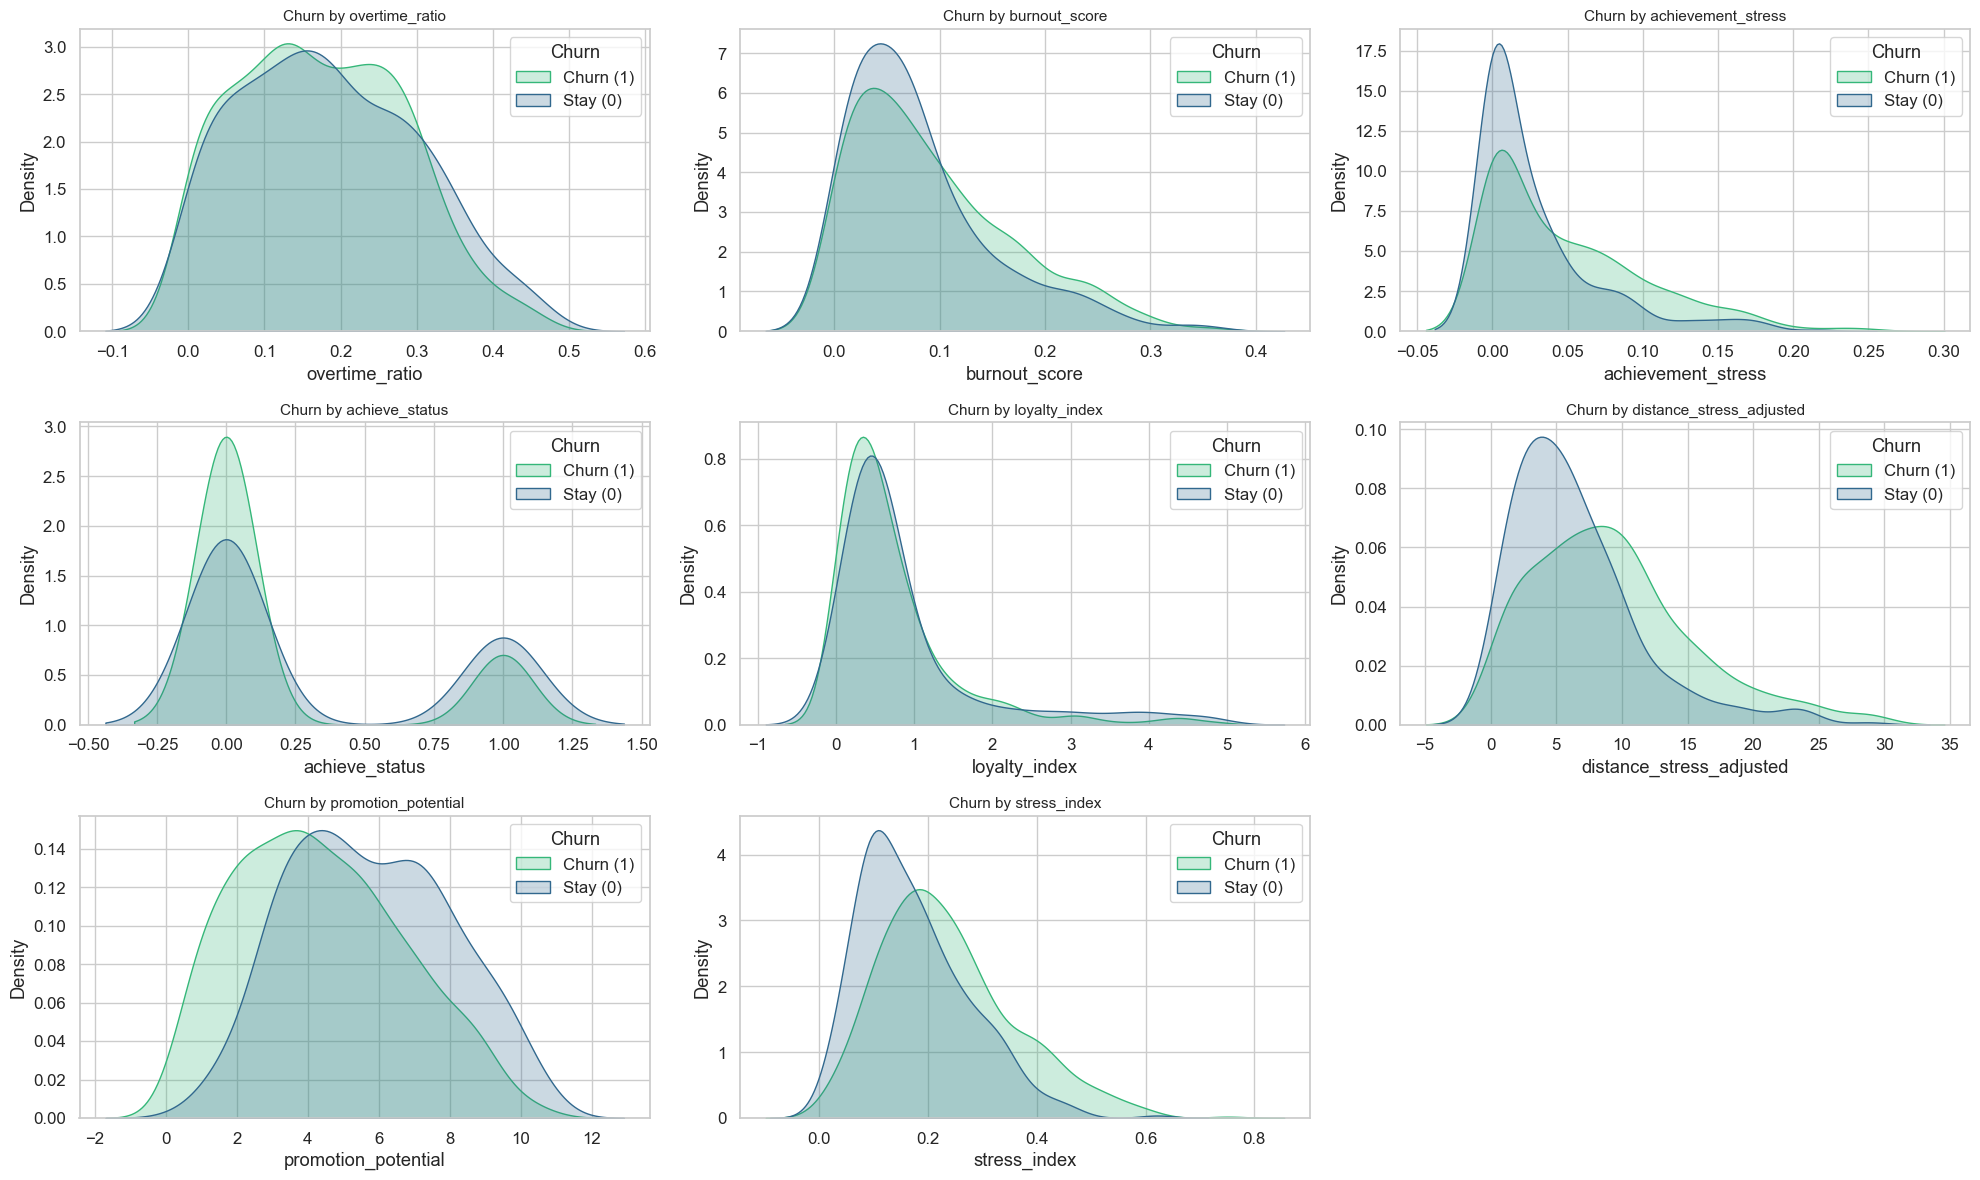

In [41]:
# Multivariate Feature Enggineering

plt.figure(figsize=(20, 12))
for i, col in enumerate(feature_cols):
    plt.subplot(3, 3, i + 1)

    sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, palette='viridis')
    plt.title(f'Churn by {col}', fontsize=11)
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend(title='Churn', labels=['Churn (1)', 'Stay (0)'])

plt.tight_layout()
plt.show()

It's show that employee churn is a toxic combination of external pressure (stress/commute) and internal dissatisfaction (burnout/loyalty), severely magnified by managerial failure and poor performance outcomes.

The hierarchy of churn drivers is:

* Workplace Experience & Wellbeing: Burnout Score, Loyalty Index, Stress Index, Job Satisfaction, and Manager Support Score are the most powerful predictors.

* Performance & Career Outlook: Target Achievement (failure to meet targets) and low Promotion Potential are key drivers.

* External Pressure: Distance-related stress and high Working Hours are significant contributing factors.

# Label Encoding

In [42]:
# Define categorical columns
categorical_cols = ['gender', 'education', 'work_location', 'marital_status']

# Make a copy to avoid modifying the original DataFrame
df_encoded = df.copy()

# Apply Label Encoding to each categorical column
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Number of columns before encoding:", df.shape[1])
print("Number of columns after encoding:", df_encoded.shape[1])

Number of columns before encoding: 27
Number of columns after encoding: 27


# Mutual Information Correlation

In [43]:
# =====================================================
# 🔢 KONVERSI FITUR KATEGORIKAL KE NUMERIK
# =====================================================
X = df.drop(columns=[target_col])

# Drop churn_period dari X supaya tidak dianalisis
if 'churn_period' in X.columns:
    X = X.drop(columns=['churn_period'])

y = df[target_col]

# Deteksi kolom non-numerik setelah drop churn_period
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Buat salinan data untuk encoding
X_encoded = X.copy()
le = LabelEncoder()

for col in categorical_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

print(f"\n📊 {len(categorical_cols)} kolom kategorikal berhasil di-encode:")
print(categorical_cols)

# =====================================================
# 🧠 CEK FITUR ENGINEERING SUDAH TERMASUK
# =====================================================
engineered_features = [
    'overtime_ratio', 'burnout_score', 'achievement_stress', 'achieve_status',
    'loyalty_index', 'distance_stress_adjusted', 'promotion_potential', 'stress_index'
]

print("\n🧩 Mengecek fitur hasil feature engineering di X_encoded:")
for f in engineered_features:
    status = "✅" if f in X_encoded.columns else "❌"
    print(f" - {f}: {status}")

# =====================================================
# 📈 HITUNG MUTUAL INFORMATION
# =====================================================
mi_scores = mutual_info_classif(X_encoded, y, discrete_features='auto', random_state=42)

mi_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'mutual_info': mi_scores
}).sort_values(by='mutual_info', ascending=False)

# =====================================================
# 🔍 TAMPILKAN HASIL
# =====================================================
print("\n🔍 Top 10 Fitur Berdasarkan Mutual Information:")
display(mi_df.head(10))


📊 4 kolom kategorikal berhasil di-encode:
['gender', 'education', 'work_location', 'marital_status']

🧩 Mengecek fitur hasil feature engineering di X_encoded:
 - overtime_ratio: ✅
 - burnout_score: ✅
 - achievement_stress: ✅
 - achieve_status: ✅
 - loyalty_index: ✅
 - distance_stress_adjusted: ✅
 - promotion_potential: ✅
 - stress_index: ✅

🔍 Top 10 Fitur Berdasarkan Mutual Information:


,feature,mutual_info
23,promotion_potential,0.060723
24,stress_index,0.054460
19,achievement_stress,0.054197
6,target_achievement,0.046313
22,distance_stress_adjusted,0.042747
14,company_tenure_years,0.030882
11,job_satisfaction,0.018883
9,salary,0.017935
21,loyalty_index,0.016909
1,age,0.014910


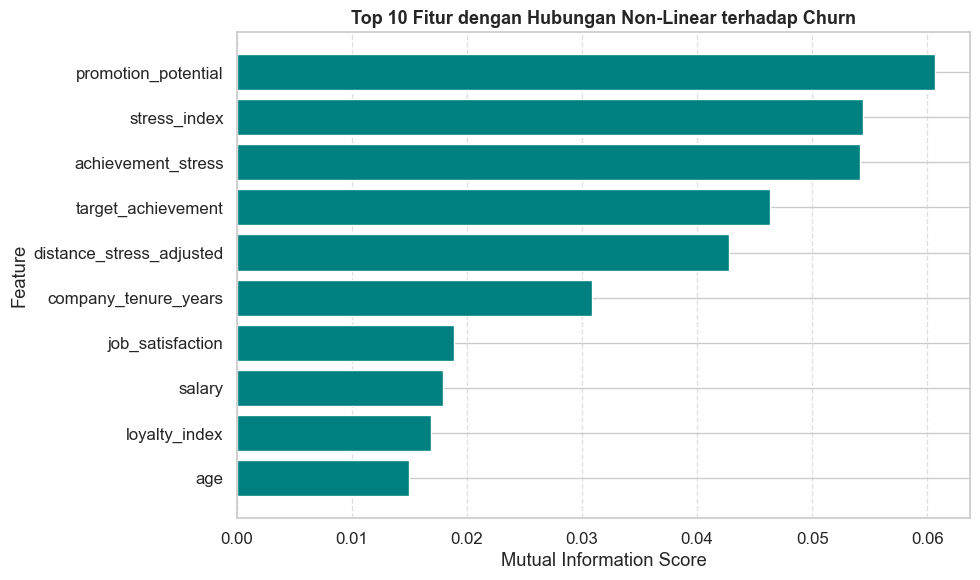

In [44]:
# 📊 VISUALISASI
# =====================================================
plt.figure(figsize=(10, 6))
plt.barh(mi_df.head(10)['feature'][::-1], mi_df.head(10)['mutual_info'][::-1], color='teal')
plt.title('Top 10 Fitur dengan Hubungan Non-Linear terhadap Churn', fontsize=13, weight='bold')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Pearson & Spearman Correlation

In [45]:
# =====================================================
# 🔢 DEFINISI FITUR NUMERIK UNTUK KORELASI
# =====================================================

# Semua kolom numerik termasuk hasil feature engineering
numeric_features = [col for col in df_encoded.select_dtypes(include=['number']).columns if col != 'employee_id']

# Pastikan target_col tidak dihitung
if target_col in numeric_features:
    numeric_features.remove(target_col)

# =====================================================
# 🔍 HITUNG KORELASI PEARSON & SPEARMAN TERHADAP TARGET
# =====================================================

corr_list = []
for col in numeric_features:
    try:
        # Handle potential non-numeric values that might have slipped through
        # or issues with the target column in case of encoding errors earlier.
        if pd.api.types.is_numeric_dtype(df_encoded[col]) and pd.api.types.is_numeric_dtype(df_encoded[target_col]):
             # Check for sufficient variance in both columns
            if df_encoded[col].nunique() > 1 and df_encoded[target_col].nunique() > 1:
                pearson_r, pearson_p = stats.pearsonr(df_encoded[col], df_encoded[target_col])
                spearman_r, spearman_p = stats.spearmanr(df_encoded[col], df_encoded[target_col])
                corr_list.append({
                    'feature': col,
                    'pearson_r': pearson_r,
                    'pearson_p': pearson_p,
                    'spearman_r': spearman_r,
                    'spearman_p': spearman_p
                })
            else:
                 print(f"⚠️ Kolom '{col}' atau target '{target_col}' tidak memiliki cukup variasi untuk korelasi.")
        else:
             print(f"⚠️ Kolom '{col}' atau target '{target_col}' bukan numerik setelah encoding.")

    except Exception as e:
        print(f"⚠️ Gagal menghitung korelasi untuk kolom {col}: {e}")

corr_df = pd.DataFrame(corr_list).sort_values(by='pearson_r', ascending=False)

print("\nTop 10 fitur numerik berdasarkan Pearson correlation:")
display(corr_df.head(10))


Top 10 fitur numerik berdasarkan Pearson correlation:


,feature,pearson_r,pearson_p,spearman_r,spearman_p
23,stress_index,0.253269,5.095428e-15,0.257932,1.540810e-15
21,distance_stress_adjusted,0.231611,9.628149e-13,0.246689,2.643963e-14
18,achievement_stress,0.204785,3.174392e-10,0.208919,1.364028e-10
15,distance_to_office_km,0.179762,3.634513e-08,0.179032,4.134470e-08
6,working_hours_per_week,0.166235,3.634403e-07,0.166074,3.731132e-07
17,burnout_score,0.085180,9.506788e-03,0.079428,1.562419e-02
9,commission_rate,0.041220,2.101481e-01,0.041223,2.101096e-01
11,work_location,0.023128,4.820932e-01,0.021727,5.090279e-01
8,salary,0.007542,8.187227e-01,0.007232,8.260334e-01
0,age,0.006665,8.394999e-01,0.008351,7.996683e-01


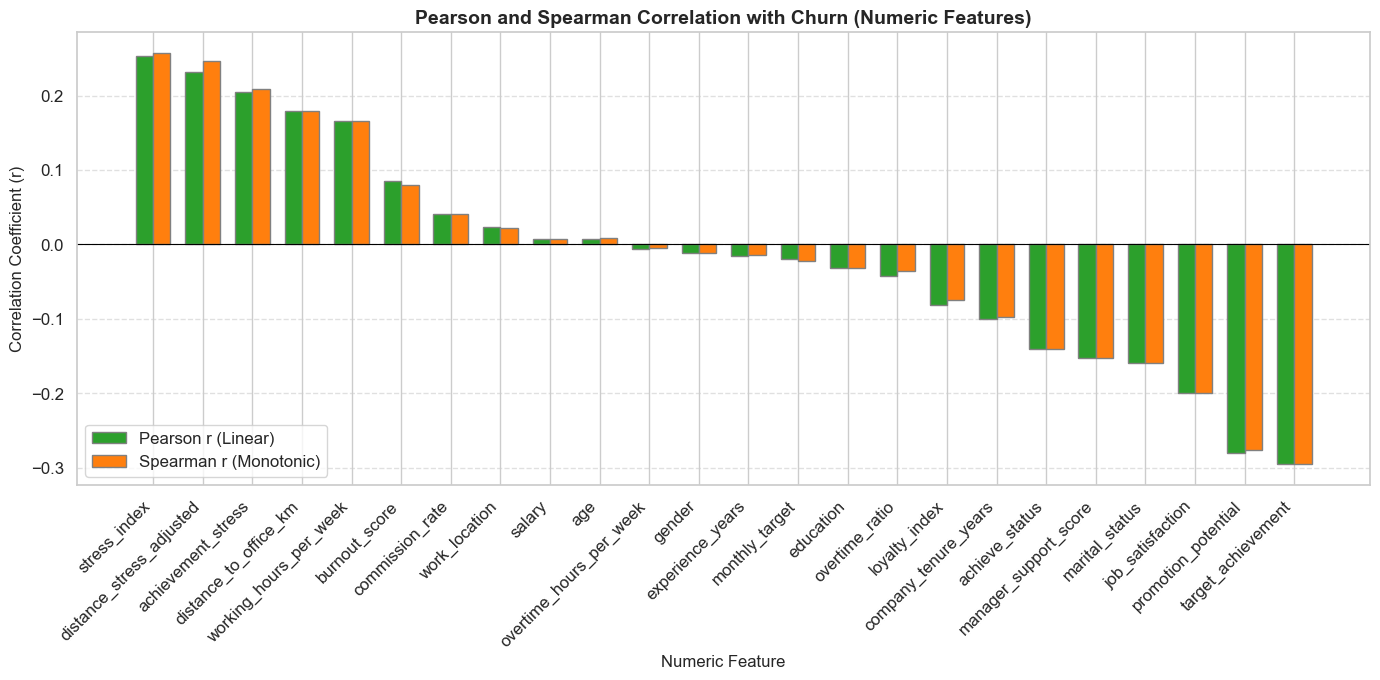

In [46]:
# Urutkan berdasarkan korelasi Pearson tertinggi
corr_df_sorted = corr_df.sort_values(by='pearson_r', ascending=False)
order = corr_df_sorted['feature'].tolist()

# Plot Bar Pearson & Spearman
plt.figure(figsize=(14, 7))
bar_width = 0.35
r = np.arange(len(order))

pearson_data = corr_df_sorted['pearson_r']
spearman_data = corr_df_sorted['spearman_r']

plt.bar(r - bar_width/2, pearson_data, color='#2ca02c', width=bar_width, edgecolor='grey', label='Pearson r (Linear)')
plt.bar(r + bar_width/2, spearman_data, color='#ff7f0e', width=bar_width, edgecolor='grey', label='Spearman r (Monotonic)')

plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.xlabel('Numeric Feature', fontsize=12)
plt.ylabel('Correlation Coefficient (r)', fontsize=12)
plt.title('Pearson and Spearman Correlation with Churn (Numeric Features)', fontsize=14, fontweight='bold')
plt.xticks(r, order, rotation=45, ha='right')
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Top 3 Prediktor Terkuat:**
  1. Stress Index (stress_index): Ini menunjukkan bahwa stres total yang dirasakan karyawan-gabungan antara burnout, tekanan pencapaian target, dan commute strain—adalah faktor paling signifikan untuk churn. Karyawan dengan stres lebih tinggi cenderung meninggalkan perusahaan.

  2. Distance Stress Adjusted (distance_stress_adjusted): Stres akibat perjalanan ke kantor yang sudah disesuaikan dengan status pernikahan memegang peranan penting; karyawan yang harus menempuh jarak jauh, apalagi dengan tanggung jawab keluarga, lebih rentan churn.

  3. Achievement Stress (achievement_stress): Karyawan yang bekerja keras tapi gagal mencapai target mengalami frustrasi yang signifikan, mendorong keputusan untuk meninggalkan perusahaan.

**Prediktor Sekunder:**

  1. Distance to Office (km) (distance_to_office_km): Jarak fisik ke kantor tetap relevan, tetapi pengaruhnya lebih rendah dibandingkan stres yang diperhitungkan.

  2. Working Hours per Week (working_hours_per_week): Jumlah jam kerja mempengaruhi churn secara moderat; terlalu banyak jam kerja meningkatkan risiko.

  3. Burnout Score (burnout_score): Kombinasi overtime dan kepuasan kerja rendah berkontribusi terhadap churn, tetapi efeknya lebih kecil dibandingkan stress index.

Commission Rate & Salary : Pengaruh finansial hanya minor; ini menunjukkan faktor “soft” seperti stres dan jarak lebih dominan daripada uang semata.

  1. Work Location (work_location): Lokasi kerja memiliki dampak rendah tetapi tetap ada peran minor.

  2. Age (age): Usia hampir tidak mempengaruhi churn dalam dataset ini.

**Crucial Insight:**

  1. Fitur target achievement tidak muncul di top 10, tetapi stress yang terkait dengan pencapaian target (achievement_stress) sangat penting. Hal ini menegaskan bahwa bukan besar kecilnya target yang mempengaruhi churn, tapi frustrasi akibat ketidakmampuan memenuhi target.

  2. Faktor finansial dan demografis (salary, age, work location) memiliki pengaruh lebih kecil dibandingkan faktor psikologis dan lingkungan kerja seperti stres, jarak, dan burnout.

These correlation results largely confirm the findings from the Mutual Information Scores (previous analysis):

Target Achievement, Job Satisfaction, and Manager Support are the most important factors inhibiting churn (strong negative correlations).

Distance to the Office and Hours Worked per Week are the most important factors driving churn (strong positive correlations).

Overtime Hours have a very weak correlation, indicating that the number of overtime hours per person is less of a driver of churn than the total number of weekly hours worked.

The Pearson (Linear) and Spearman (Monotone) correlations are very similar for all features, indicating that the relationship is fairly linear and well represented by Pearson's r.

**Anova Analysis**

In [47]:
# Pastikan target kolom
target_col = 'churn'

# Pastikan semua fitur (termasuk fitur baru) tersedia
feature_cols = [
    'overtime_ratio', 'burnout_score', 'achievement_stress', 'achieve_status',
    'loyalty_index', 'distance_stress_adjusted', 'promotion_potential', 'stress_index'
]

# Tambahkan juga fitur numerik lain (kecuali kolom target dan ID)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_cols = ['employee_id', target_col, 'churn_period']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

# Gabungkan fitur numerik dan hasil feature engineering
all_features = list(set(numeric_cols + feature_cols))

# Encode target (jika masih kategorikal)
if df[target_col].dtype == 'object':
    df[target_col] = LabelEncoder().fit_transform(df[target_col])

# Pisahkan data berdasarkan kategori churn
group_0 = df[df[target_col] == 0]
group_1 = df[df[target_col] == 1]

# Simpan hasil ANOVA
anova_results = []

for col in all_features:
    try:
        # Pastikan kolom tidak memiliki NaN
        group0_vals = group_0[col].dropna()
        group1_vals = group_1[col].dropna()

        # Hitung ANOVA F-test
        f_stat, p_val = f_oneway(group0_vals, group1_vals)
        anova_results.append({'Feature': col, 'F_stat': f_stat, 'p_value': p_val})
    except Exception as e:
        print(f"Kolom {col} error: {e}")

# Buat DataFrame hasil analisis
anova_df = pd.DataFrame(anova_results).sort_values(by='p_value')

# Tampilkan hasil
print("=== HASIL UJI ANOVA TERHADAP CHURN ===")
display(anova_df)

# Tampilkan fitur dengan pengaruh signifikan (p < 0.05)
significant_features = anova_df[anova_df['p_value'] < 0.05]
print("\n=== FITUR DENGAN PENGARUH SIGNIFIKAN (p < 0.05) ===")
display(significant_features)

=== HASIL UJI ANOVA TERHADAP CHURN ===


,Feature,F_stat,p_value
2,target_achievement,88.561225,3.794251e-20
5,promotion_potential,79.159360,2.969282e-18
7,stress_index,63.332386,5.095428e-15
3,distance_stress_adjusted,52.376599,9.628149e-13
12,achievement_stress,40.445798,3.174392e-10
4,job_satisfaction,38.173062,9.694305e-10
16,distance_to_office_km,30.855674,3.634513e-08
19,working_hours_per_week,26.259522,3.634403e-07
6,manager_support_score,21.859462,3.370386e-06
17,achieve_status,18.675686,1.717443e-05



=== FITUR DENGAN PENGARUH SIGNIFIKAN (p < 0.05) ===


,Feature,F_stat,p_value
2,target_achievement,88.561225,3.794251e-20
5,promotion_potential,79.159360,2.969282e-18
7,stress_index,63.332386,5.095428e-15
3,distance_stress_adjusted,52.376599,9.628149e-13
12,achievement_stress,40.445798,3.174392e-10
4,job_satisfaction,38.173062,9.694305e-10
16,distance_to_office_km,30.855674,3.634513e-08
19,working_hours_per_week,26.259522,3.634403e-07
6,manager_support_score,21.859462,3.370386e-06
17,achieve_status,18.675686,1.717443e-05


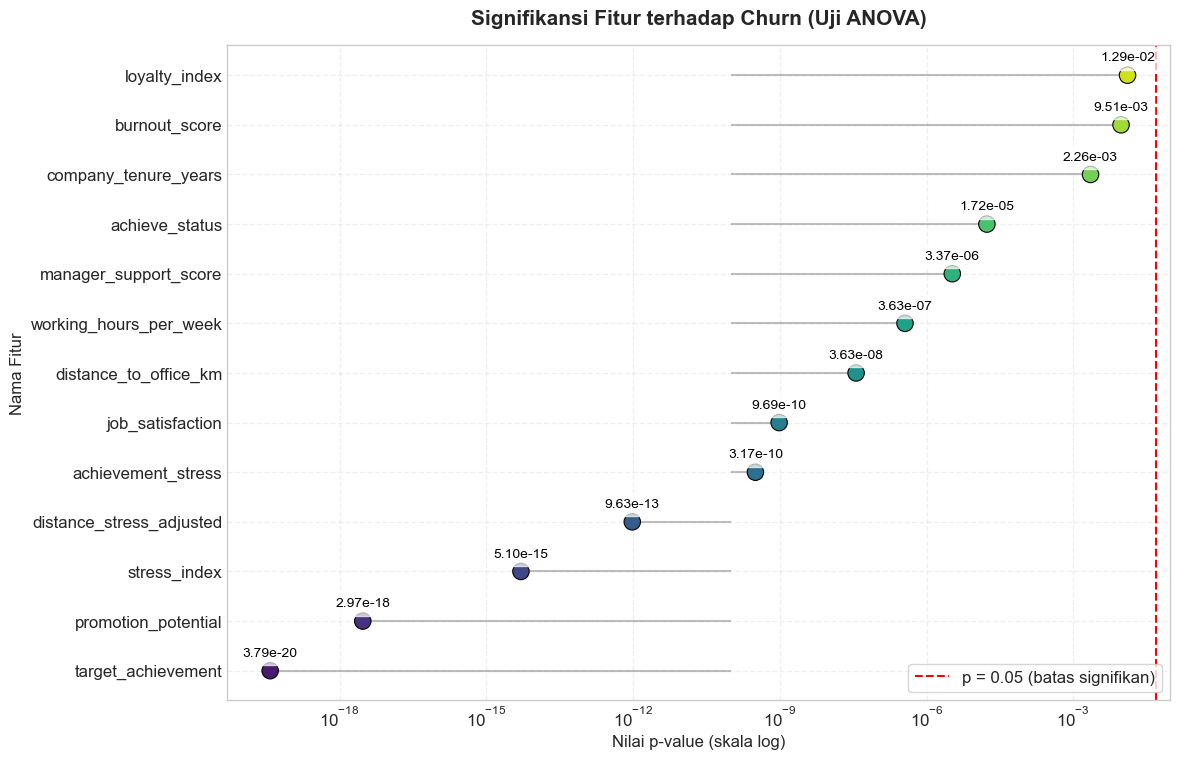

In [48]:
# ===============================================
# VISUALISASI P-VALUE FITUR SIGNIFIKAN (LOLLIPOP CHART - LABEL DI ATAS TITIK)

if not significant_features.empty:
    # Urutkan fitur dari p-value terkecil ke terbesar
    sig_sorted = significant_features.sort_values(by='p_value', ascending=True).reset_index(drop=True)

    # Hindari p_value = 0 untuk skala log
    sig_sorted['p_value_plot'] = sig_sorted['p_value'].replace(0, 1e-10)

    # Setup style
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, max(6, 0.6 * len(sig_sorted))))  # tinggi menyesuaikan jumlah fitur

    # Warna gradasi
    colors = sns.color_palette("viridis", len(sig_sorted))

    # Gunakan skala log agar p-value kecil terlihat jelas
    ax.set_xscale("log")

    # Gambar garis horizontal (lollipop stem)
    ax.hlines(
        y=sig_sorted["Feature"],
        xmin=1e-10,
        xmax=sig_sorted["p_value_plot"],
        color="gray",
        alpha=0.5,
        linewidth=1.5
    )

    # Titik utama (p-value point)
    ax.scatter(
        sig_sorted["p_value_plot"],
        sig_sorted["Feature"],
        s=140,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    # Garis batas signifikansi
    ax.axvline(x=0.05, color="red", linestyle="--", linewidth=1.5, label="p = 0.05 (batas signifikan)")

    # Judul dan label sumbu
    ax.set_title("Signifikansi Fitur terhadap Churn (Uji ANOVA)", fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel("Nilai p-value (skala log)", fontsize=12)
    ax.set_ylabel("Nama Fitur", fontsize=12)

    # Tambahkan label p-value di atas titik menggunakan annotate
    for feature, pval in zip(sig_sorted["Feature"], sig_sorted["p_value_plot"]):
        ax.annotate(
            f"{pval:.2e}",
            xy=(pval, feature),
            xytext=(0, 8),  # posisi sedikit di atas titik
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=10, fontweight="medium",
            color="black",
            backgroundcolor=(1, 1, 1, 0.7),  # latar semi-transparan
            zorder=4
        )

    # Estetika tambahan
    ax.legend(loc="lower right", frameon=True)
    ax.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

else:
    print("Tidak ada fitur signifikan dengan p-value < 0.05.")

**Chi-Square Test**

In [49]:
# Tentukan kolom target kategorikal
target_col = 'churn'  # ubah jika target berbeda

# Daftar kolom kategorikal hasil encoding
categorical_cols = ['gender', 'education', 'work_location', 'marital_status']

# Simpan hasil analisis
chi2_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(df_encoded[col], df_encoded[target_col])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Hitung Cramér's V (asosiasi)
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt((chi2 / n) / (min(contingency_table.shape) - 1))

    chi2_results.append({
        'Feature': col,
        'Chi2 Statistic': round(chi2, 3),
        'p_value': round(p, 5),
        'Degrees of Freedom': dof,
        "Cramér's V": round(cramers_v, 3),
        "Significant (p<0.05)": "Yes" if p < 0.05 else "No"
    })

# Buat tabel hasil
chi2_summary = pd.DataFrame(chi2_results).sort_values(by='p_value', ascending=True)
display(chi2_summary)

,Feature,Chi2 Statistic,p_value,Degrees of Freedom,Cramér's V,Significant (p<0.05)
3,marital_status,22.896,0.00000,1,0.157,Yes
1,education,0.905,0.63601,2,0.031,No
2,work_location,0.581,0.74774,2,0.025,No
0,gender,0.078,0.78062,1,0.009,No


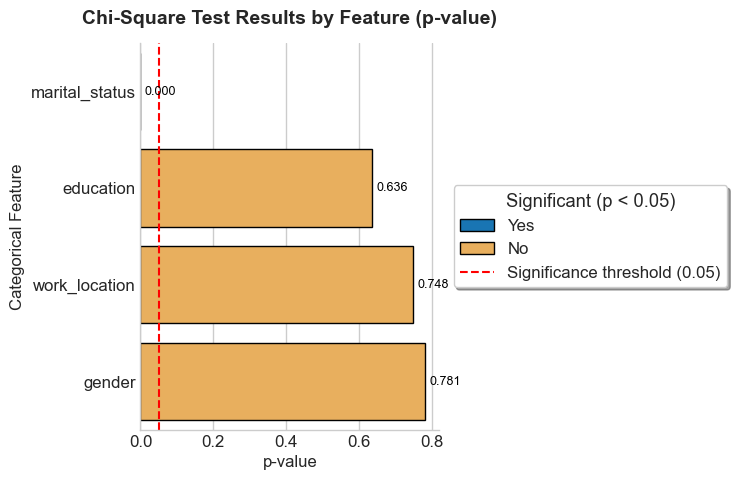

In [50]:
# 🎨 VISUALISASI: Bar Chart berdasarkan p-value
# ======================================================

plt.figure(figsize=(9, 5))
bar_colors = {'Yes': '#007ACC', 'No': '#FFB347'}  # biru lembut & oranye pastel

ax = sns.barplot(
    data=chi2_summary,
    x='p_value',
    y='Feature',
    hue='Significant (p<0.05)',
    palette=bar_colors,
    dodge=False,
    edgecolor='black'
)

# Garis batas signifikansi
plt.axvline(0.05, color='red', linestyle='--', linewidth=1.5, label='Significance threshold (0.05)')

# Tambahkan label nilai p di ujung batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', padding=3, fontsize=9, color='black')

# Judul & label sumbu
plt.title('Chi-Square Test Results by Feature (p-value)', fontsize=14, pad=14, weight='bold')
plt.xlabel('p-value', fontsize=12)
plt.ylabel('Categorical Feature', fontsize=12)

# Legend dipindahkan keluar grafik agar tidak overlap
plt.legend(
    title='Significant (p < 0.05)',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    shadow=True
)

# Sesuaikan tampilan agar layout rapi dan proporsional
plt.tight_layout(rect=[0, 0, 0.85, 1])  # sisakan ruang untuk legend di kanan
sns.despine()
plt.show()

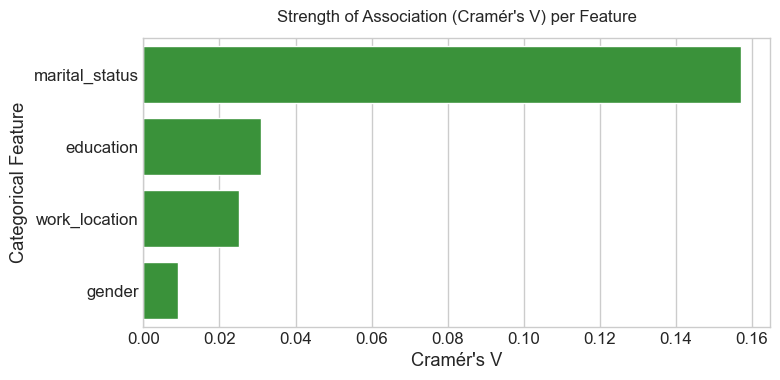

In [51]:
# 🧭 Optional: Visualisasi tambahan (asosiasi kekuatan)
# ======================================================

plt.figure(figsize=(8, 4))
sns.barplot(
    data=chi2_summary,
    x="Cramér's V",
    y='Feature',
    color='tab:green'
)
plt.title("Strength of Association (Cramér's V) per Feature", fontsize=12, pad=12)
plt.xlabel("Cramér's V")
plt.ylabel("Categorical Feature")
plt.tight_layout()
plt.show()

# Heatmap Correlation

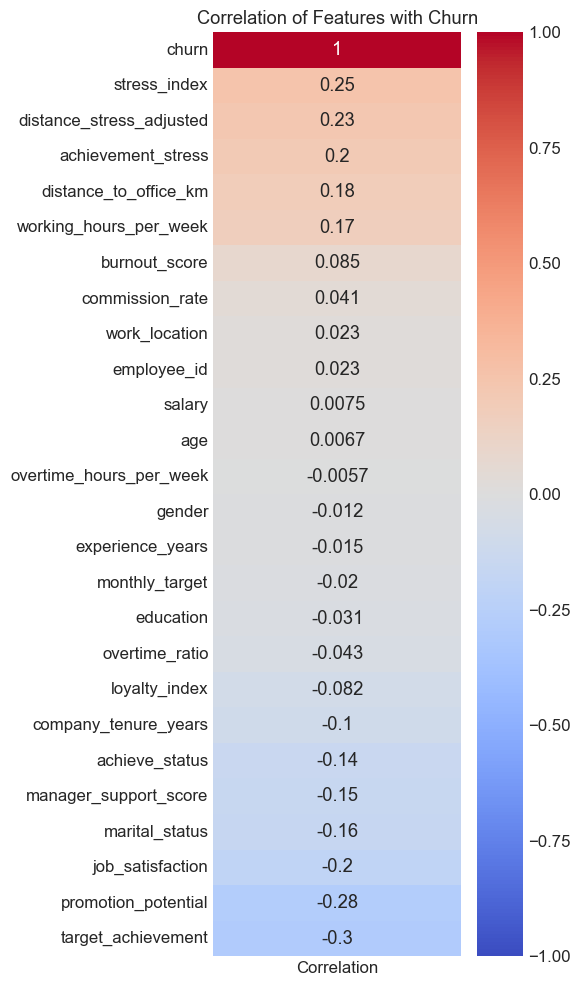

In [52]:
# Heatmap Correlation
if 'df_encoded' not in locals() or not isinstance(df_encoded, pd.DataFrame):
     print("⚠️ DataFrame 'df_encoded' belum terdefinisi. Harap jalankan sel sebelumnya.")
else:
    encoded_exclude = ['churn_period_Stayed', 'churn_period_Onboarding', 'churn_period_3 Months']
    # Filter columns, ensuring they exist in df_encoded before attempting exclusion
    encoded_filtered = [f for f in df_encoded.columns if f not in encoded_exclude]

    # Calculate correlation matrix
    # Ensure numeric_only is True to avoid errors with non-numeric columns if any were missed
    corr_matrix = df_encoded[encoded_filtered].corr(numeric_only=True)

    # Check if 'churn' is in the correlation matrix columns before proceeding
    if 'churn' in corr_matrix.columns:
        churn_corr = corr_matrix['churn'].sort_values(ascending=False)

        # Visualisation
        plt.figure(figsize=(4,12))
        sns.heatmap(churn_corr.to_frame(name='Correlation'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Correlation of Features with Churn')
        plt.show()
    else:
        print("⚠️ Kolom 'churn' tidak ditemukan setelah filtering kolom yang diexclude.")

Positive Correlation: Features with positive correlation mean that as their values increase, the probability of churn also increases. Key features include:

1. Stress Index (0.25) → Higher stress levels strongly increase churn.
2. Distance Stress Adjusted (0.23) → The combined effect of commute distance and stress contributes to churn.
3. Achievement Stress (0.20) → Performance pressure from achievement targets can lead to burnout and exit.
4. Distance to Office (0.18) → Employees living farther from the office are more likely to leave.
5. Working Hours per Week (0.17) → Longer working hours slightly raise churn probability.

Workload and stress-related factors are the main churn drivers. This highlights the importance of work-life balance and mental well-being support.

Negative Correlation: Features with negative correlation mean that as their values increase, the probability of churn decreases. Key features include:

1. Target Achievement (-0.30) → Employees who meet targets tend to stay longer.
2. Promotion Potential (-0.28) → Clear promotion opportunities reduce churn.
3. Job Satisfaction (-0.20) → Higher satisfaction strongly correlates with retention.
4. Marital Status - Single (-0.16) → Single employees show slightly better retention, possibly due to fewer external responsibilities.
5. Manager Support Score (-0.15) → Strong managerial support lowers churn risk.
6. Company Tenure (-0.10) → Longer-tenured employees are less likely to leave.

Factors tied to career growth, recognition, and job satisfaction are key to retaining employees.

# Standarization

In [53]:
if 'df_encoded' not in locals() or not isinstance(df_encoded, pd.DataFrame):
     print("⚠️ DataFrame 'df_encoded' belum terdefinisi. Harap jalankan sel sebelumnya.")
else:
    numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if 'churn' in numeric_cols:
        numeric_cols.remove('churn')

    scaler = StandardScaler()

    df_scaled = df_encoded.copy()
    df_scaled[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

    display(df_scaled[numeric_cols].head())

,employee_id,age,experience_years,monthly_target,target_achievement,working_hours_per_week,overtime_hours_per_week,salary,commission_rate,job_satisfaction,manager_support_score,company_tenure_years,distance_to_office_km,overtime_ratio,burnout_score,achievement_stress,loyalty_index,distance_stress_adjusted,promotion_potential,stress_index
0,-1.744882,-0.859643,-1.497004,0.627739,0.654081,0.904231,-0.075154,-0.579022,-1.239683,1.325757,0.418455,0.146960,-0.153886,-0.291162,-0.812293,-0.660153,2.289123,-0.275563,1.233647,-0.915514
1,-1.741414,1.131962,0.620988,1.425582,-1.099223,0.097566,-0.250009,0.243820,0.052080,0.433569,0.418455,0.075674,0.847108,-0.288541,-0.416759,0.512004,-0.455147,0.130531,0.193412,0.020359
2,-1.737946,0.365960,1.326986,0.764512,-1.537549,0.558518,0.099701,-0.499798,0.482667,-1.350807,-0.482683,-0.637185,-0.511384,-0.073694,0.633644,1.076058,-0.678875,-0.433488,-1.243929,0.626217
3,-1.734478,-0.246841,0.973987,1.357196,-0.573232,1.595658,0.973976,-1.302076,-0.378508,-1.350807,-0.482683,-1.492615,0.561110,0.383016,1.188314,0.674958,-0.822539,0.773512,-1.627683,1.401948
4,-1.731010,-0.706442,0.973987,0.376988,0.960909,-1.054812,-0.075154,-0.241105,0.913255,0.433569,-0.482683,1.358819,-0.725883,0.198995,-0.120706,-0.835568,-0.254199,-0.602693,1.526868,-0.722834


In [54]:
if 'df_scaled' not in locals() or not isinstance(df_scaled, pd.DataFrame):
     print("⚠️ DataFrame 'df_scaled' belum terdefinisi. Harap jalankan sel sebelumnya.")
else:
    # Safely drop columns, ignoring errors if they don't exist
    cols_to_drop = ['employee_id', 'churn_period']
    df_model = df_scaled.drop(columns=cols_to_drop, errors='ignore')

    # Optional: Display the first few rows of the prepared data for modeling
    # display(df_model.head())
    print("Data prepared for modeling (df_model).")
    print(f"Shape of df_model: {df_model.shape}")

Data prepared for modeling (df_model).
Shape of df_model: (926, 25)


# Train Test Split

In [55]:
if 'df_model' not in locals() or not isinstance(df_model, pd.DataFrame):
     print("⚠️ DataFrame 'df_model' belum terdefinisi. Harap jalankan sel sebelumnya.")
elif 'churn' not in df_model.columns:
     print("⚠️ Kolom target 'churn' tidak ditemukan dalam df_model.")
else:
    X = df_model.drop(columns=['churn'])
    y = df_model['churn']

    # Ensure y has at least two unique values for stratification
    if y.nunique() < 2:
        print("⚠️ Kolom target 'churn' tidak memiliki cukup variasi untuk stratifikasi.")
        # You might want to skip train_test_split or handle it differently
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=42,
            stratify=y)

        print("Training set shape :", X_train.shape)
        print("Testing set shape  :", X_test.shape)

Training set shape : (740, 24)
Testing set shape  : (186, 24)


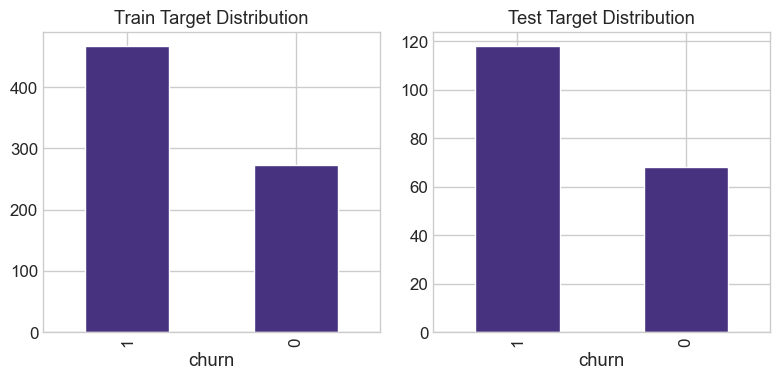

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

y_train.value_counts().plot(kind='bar', ax=ax[0], title='Train Target Distribution')
y_test.value_counts().plot(kind='bar', ax=ax[1], title='Test Target Distribution')

plt.tight_layout()
plt.show()

# Over Sampling

In [57]:
# Check if X_train and y_train exist
if 'X_train' not in locals() or 'y_train' not in locals():
     print("⚠️ Data training (X_train, y_train) belum terdefinisi. Harap jalankan sel sebelumnya.")
elif y_train.nunique() < 2:
      print("⚠️ Kolom target y_train tidak memiliki cukup variasi untuk SMOTE.")
else:
    print("Distribusi sebelum SMOTE:")
    print(Counter(y_train))

    smote = SMOTE(random_state=42, sampling_strategy='auto')

    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Cek distribusi setelah SMOTE
    print("\nDistribusi setelah SMOTE:")
    print(Counter(y_train_resampled))

    # Tampilkan perbandingan jumlah data
    print(f"\nJumlah data sebelum SMOTE: {len(y_train)}")
    print(f"Jumlah data setelah SMOTE : {len(y_train_resampled)}")

Distribusi sebelum SMOTE:
Counter({1: 467, 0: 273})

Distribusi setelah SMOTE:
Counter({1: 467, 0: 467})

Jumlah data sebelum SMOTE: 740
Jumlah data setelah SMOTE : 934


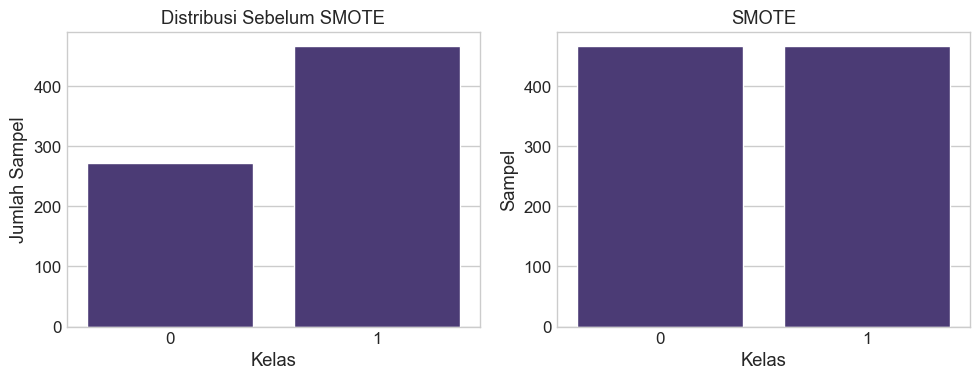

In [58]:
# --- Distribusi Kelas Sebelum & Sesudah SMOTE ---
before = Counter(y_train)
after = Counter(y_train_resampled)

# Bar chart perbandingan
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Sebelum SMOTE
sns.barplot(x=list(before.keys()), y=list(before.values()), ax=ax[0])
ax[0].set_title('Distribusi Sebelum SMOTE')
ax[0].set_xlabel('Kelas')
ax[0].set_ylabel('Jumlah Sampel')

# Sesudah SMOTE
sns.barplot(x=list(after.keys()), y=list(after.values()), ax=ax[1])
ax[1].set_title('SMOTE')
ax[1].set_xlabel('Kelas')
ax[1].set_ylabel('Sampel')

plt.tight_layout()
plt.show()


# Logistic Regression Base Model

===== Logistic Regression Model Evaluation =====

🔹 TRAINING PERFORMANCE
Accuracy  : 0.7580
Precision : 0.7591
Recall    : 0.7559
F1-Score  : 0.7575
F2-Score  : 0.7575
Roc-AUC   : 0.8420

🔹 TESTING PERFORMANCE
Accuracy  : 0.6989
Precision : 0.8100
Recall    : 0.6864
F1-Score  : 0.7431
F2-Score  : 0.7080
Roc-AUC   : 0.7697

===== Classification Report + F2-Score =====


,precision,recall,f1-score,f2-score,support
0,0.5698,0.7206,0.6364,0.6844,68.0000
1,0.8100,0.6864,0.7431,0.7080,118.0000
accuracy,0.6989,0.6989,0.6989,NaN,0.6989
macro avg,0.6899,0.7035,0.6897,NaN,186.0000
weighted avg,0.7222,0.6989,0.7041,NaN,186.0000


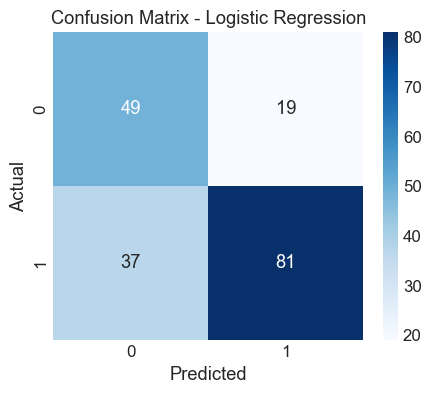

In [59]:
if 'X_train_resampled' not in locals() or 'y_train_resampled' not in locals() or 'X_test' not in locals() or 'y_test' not in locals():
    print("⚠️ Data training/testing belum terdefinisi. Harap jalankan sel sebelumnya.")
else:
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train_resampled, y_train_resampled)

    y_train_pred = log_reg.predict(X_train_resampled)
    y_train_prob = log_reg.predict_proba(X_train_resampled)[:, 1]
    train_acc = accuracy_score(y_train_resampled, y_train_pred)
    train_prec = precision_score(y_train_resampled, y_train_pred)
    train_rec = recall_score(y_train_resampled, y_train_pred)
    train_f1 = f1_score(y_train_resampled, y_train_pred)
    train_f2 = fbeta_score(y_train_resampled, y_train_pred, beta=2)
    train_roc_auc = roc_auc_score(y_train_resampled, y_train_prob)

    y_test_pred = log_reg.predict(X_test)
    y_test_prob = log_reg.predict_proba(X_test)[:, 1]
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred)
    test_rec = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_f2 = fbeta_score(y_test, y_test_pred, beta=2)
    test_roc_auc = roc_auc_score(y_test, y_test_prob)

    print("===== Logistic Regression Model Evaluation =====\n")
    print("🔹 TRAINING PERFORMANCE")
    print(f"Accuracy  : {train_acc:.4f}")
    print(f"Precision : {train_prec:.4f}")
    print(f"Recall    : {train_rec:.4f}")
    print(f"F1-Score  : {train_f1:.4f}")
    print(f"F2-Score  : {train_f1:.4f}")
    print(f"Roc-AUC   : {train_roc_auc:.4f}\n")

    print("🔹 TESTING PERFORMANCE")
    print(f"Accuracy  : {test_acc:.4f}")
    print(f"Precision : {test_prec:.4f}")
    print(f"Recall    : {test_rec:.4f}")
    print(f"F1-Score  : {test_f1:.4f}")
    print(f"F2-Score  : {test_f2:.4f}")
    print(f"Roc-AUC   : {test_roc_auc:.4f}\n")

    # Detailed Classification Report with F2-Score
    print("===== Classification Report + F2-Score =====")
    report = classification_report(y_test, y_test_pred, output_dict=True)

    f2_per_class = {
        str(label): fbeta_score(y_test, y_test_pred, beta=2, pos_label=label)
        for label in np.unique(y_test)
    }
   
    report_df = pd.DataFrame(report).transpose()
    
    for label in f2_per_class:
        report_df.loc[label, 'f2-score'] = f2_per_class[label]
    
    cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
    report_df = report_df[cols]
    display(report_df.round(4))

    # Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix - Logistic Regression")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Top 10 positive coefficients (increase churn likelihood):
                   Feature  Coefficient
19          achieve_status     1.871975
13    company_tenure_years     0.747655
15   distance_to_office_km     0.528465
6   working_hours_per_week     0.509287
1                   gender     0.379121
17           burnout_score     0.173561
9          commission_rate     0.167918
10        job_satisfaction     0.138316
11           work_location     0.122451
2                education     0.106791

Top 10 negative coefficients (decrease churn likelihood):
                    Feature  Coefficient
18       achievement_stress    -0.068123
3          experience_years    -0.082551
4            monthly_target    -0.101215
16           overtime_ratio    -0.140958
20            loyalty_index    -0.188554
7   overtime_hours_per_week    -0.250593
14           marital_status    -0.521439
12    manager_support_score    -0.536486
22      promotion_potential    -1.169644
5        target_achievement    -

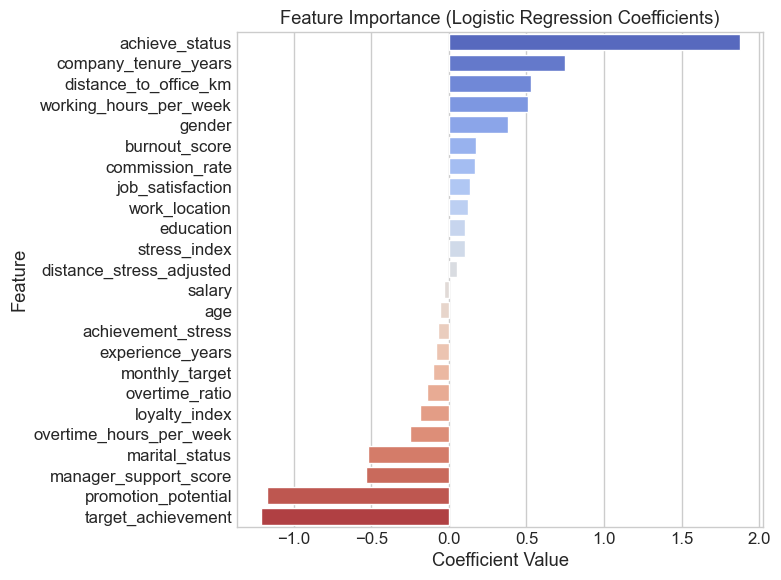

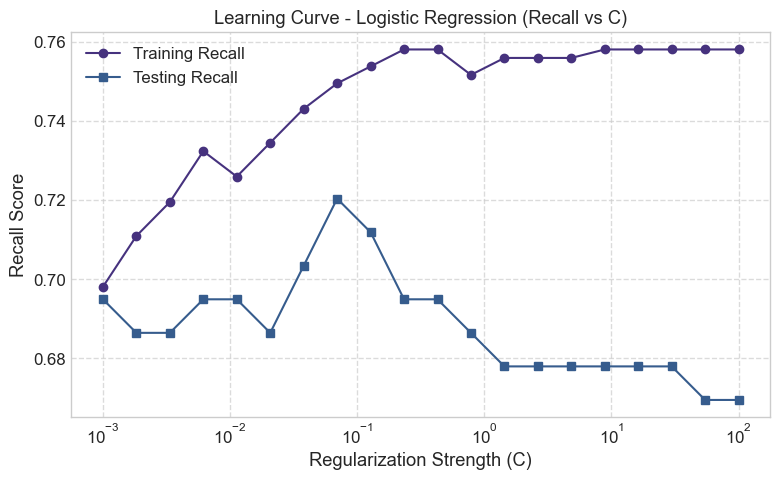

In [64]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 10 positive coefficients (increase churn likelihood):")
print(feature_importance.head(10))
print("\nTop 10 negative coefficients (decrease churn likelihood):")
print(feature_importance.tail(10))

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette='coolwarm')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

param_values = [float(x) for x in np.logspace(-3, 2, 20)]
train_recalls, test_recalls = [], []

for p in param_values:
    model = LogisticRegression(C=p, max_iter=2000, random_state=42)
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_recalls.append(recall_score(y_train_resampled, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

plt.figure(figsize=(8, 5))
plt.plot(param_values, train_recalls, label="Training Recall", marker='o')
plt.plot(param_values, test_recalls, label="Testing Recall", marker='s')
plt.xscale('log')
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Recall Score")
plt.title("Learning Curve - Logistic Regression (Recall vs C)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Logistic Regression Hypertuning

Distribusi sebelum SMOTE: Counter({1: 467, 0: 273})

✅ Best Parameters Found:
{'model__C': 1.9306977288832496, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}

===== TRAIN PERFORMANCE =====
Accuracy  : 0.7419
Precision : 0.8239
Recall    : 0.7516
F1-Score  : 0.7861
F2-Score  : 0.7650
ROC-AUC   : 0.8179

===== TEST PERFORMANCE =====
Accuracy  : 0.7366
Precision : 0.8416
Recall    : 0.7203
F1-Score  : 0.7763
F2-Score  : 0.7417
ROC-AUC   : 0.8022

===== Classification Report (TEST) + F2-SCORE =====


,precision,recall,f1-score,f2-score,support
0,0.6118,0.7647,0.6797,0.7283,68.0000
1,0.8416,0.7203,0.7763,0.7417,118.0000
accuracy,0.7366,0.7366,0.7366,NaN,0.7366
macro avg,0.7267,0.7425,0.7280,NaN,186.0000
weighted avg,0.7576,0.7366,0.7410,NaN,186.0000



🔹 F2-Score (Test, global): 0.7417


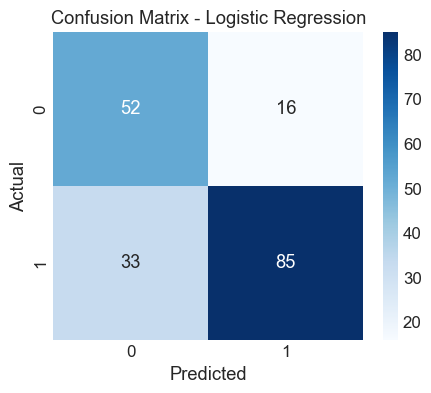

In [65]:
# Memilih fitur berdasarkan analisis sebelumnya

selected_features = [
    'achieve_status',
    'company_tenure_years',
    'distance_to_office_km',
    'working_hours_per_week',
    'manager_support_score',
    'marital_status',
    'target_achievement',
    'promotion_potential'
]
cols_to_drop = ['employee_id', 'churn_period']
df_model = df_encoded.drop(columns=cols_to_drop, errors='ignore')

X = df_model[selected_features]
y = df_model['churn']

# Stratified split agar proporsi churn tetap
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Distribusi sebelum SMOTE:", Counter(y_train_lr))

# Pipeline dengan StandardScaler, SMOTE, dan Logistic Regression
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('model', LogisticRegression(max_iter=3000, random_state=42))
])

param_grid = {
    'model__C': np.logspace(-2, 2, 8),
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': ['balanced']
}

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Gunakan F2-score sebagai metrik utama
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    refit=True,
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_lr, y_train_lr)

print("\n✅ Best Parameters Found:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

# Evaluasi model terbaik
y_train_pred = best_model.predict(X_train_lr)
y_test_pred = best_model.predict(X_test_lr)
y_train_prob = best_model.predict_proba(X_train_lr)[:, 1]
y_test_prob = best_model.predict_proba(X_test_lr)[:, 1]

def evaluate(y_true, y_pred, y_prob, set_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    f2 = fbeta_score(y_true, y_pred, beta=2)
    roc = roc_auc_score(y_true, y_prob)
    print(f"\n===== {set_name.upper()} PERFORMANCE =====")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"F2-Score  : {f2:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")
    return rec, f1, f2, roc

train_rec, train_f1, train_f2, train_roc = evaluate(y_train_lr, y_train_pred, y_train_prob, "Train")
test_rec, test_f1, test_f2, test_roc = evaluate(y_test_lr, y_test_pred, y_test_prob, "Test")

# Detailed Classification Report with F2-Score
print("\n===== Classification Report (TEST) + F2-SCORE =====")

report = classification_report(y_test_lr, y_test_pred, output_dict=True)

f2_per_class = {
    str(label): fbeta_score(y_test_lr, y_test_pred, beta=2, pos_label=label)
    for label in np.unique(y_test_lr)
}
report_df = pd.DataFrame(report).transpose()
for label in f2_per_class:
    report_df.loc[label, 'f2-score'] = f2_per_class[label]
cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
report_df = report_df[cols]
display(report_df.round(4))

f2_test = fbeta_score(y_test_lr, y_test_pred, beta=2)
print(f"\n🔹 F2-Score (Test, global): {f2_test:.4f}")

# Confusion Matrix Visualization
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_lr, y_test_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


📈 Positive Feature Importance (meningkatkan kemungkinan churn):


,Feature,Coefficient
0,achieve_status,0.627438
1,company_tenure_years,0.557386
2,distance_to_office_km,0.546093
3,working_hours_per_week,0.485689



📉 Negative Feature Importance (menurunkan kemungkinan churn):


,Feature,Coefficient
5,marital_status,-0.354926
4,manager_support_score,-0.568501
7,promotion_potential,-1.125334
6,target_achievement,-1.160153


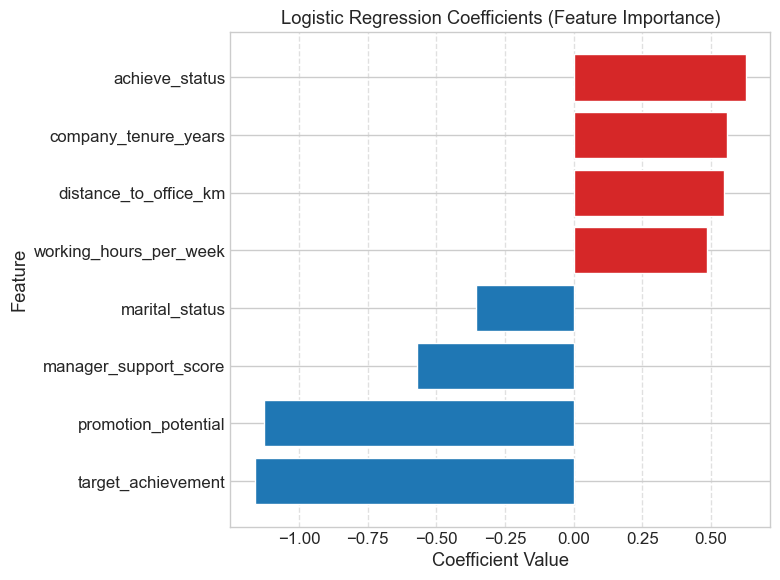


🧠 Interpretasi:
➡️ Koefisien positif → fitur yang MENINGKATKAN kemungkinan churn.
⬅️ Koefisien negatif → fitur yang MENURUNKAN kemungkinan churn.



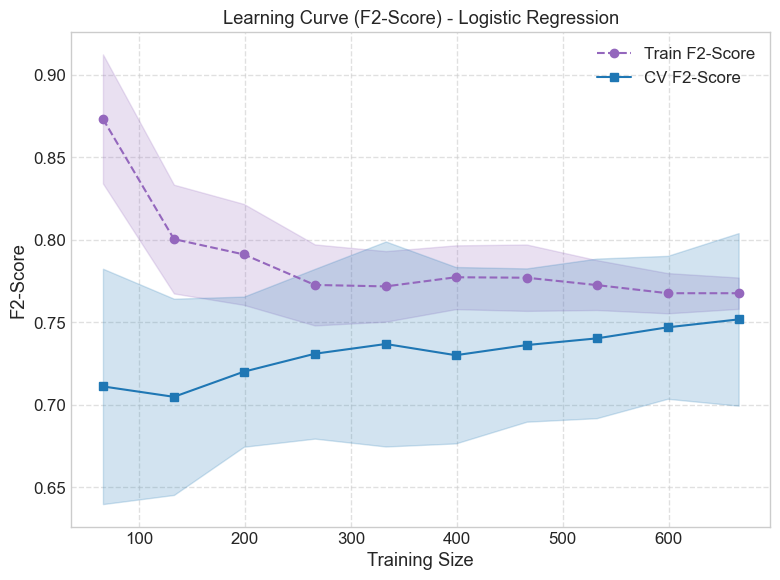

In [67]:
# Feature Importance dari Model Terbaik
logreg_final = best_model.named_steps['model']
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': logreg_final.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

positive_features = coef_df[coef_df['Coefficient'] > 0]
negative_features = coef_df[coef_df['Coefficient'] < 0]

print("\n📈 Positive Feature Importance (meningkatkan kemungkinan churn):")
display(positive_features)
print("\n📉 Negative Feature Importance (menurunkan kemungkinan churn):")
display(negative_features)

# Visualisasi Koefisien
plt.figure(figsize=(8,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=np.where(coef_df['Coefficient']>0, 'tab:red', 'tab:blue'))
plt.title('Logistic Regression Coefficients (Feature Importance)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n🧠 Interpretasi:")
print("➡️ Koefisien positif → fitur yang MENINGKATKAN kemungkinan churn.")
print("⬅️ Koefisien negatif → fitur yang MENURUNKAN kemungkinan churn.\n")


# Learning Curve dengan F2-Score
train_sizes = np.linspace(0.1, 1.0, 10)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring=make_scorer(fbeta_score, beta=2),
    n_jobs=-1,
    train_sizes=train_sizes,
    shuffle=True,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o--', label='Train F2-Score', color='tab:purple')
plt.plot(train_sizes, test_mean, 's-', label='CV F2-Score', color='tab:blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='tab:purple')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='tab:blue')
plt.title('Learning Curve (F2-Score) - Logistic Regression')
plt.xlabel('Training Size')
plt.ylabel('F2-Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Decision Tree Base Model

===== Decision Tree Baseline Model Evaluation =====

🔹 TRAINING PERFORMANCE
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
F2-Score  : 1.0000
Roc-AUC   : 1.0000

🔹 TESTING PERFORMANCE
Accuracy  : 0.6075
Precision : 0.7027
Recall    : 0.6610
F1-Score  : 0.6812
F2-Score  : 0.6690
Roc-AUC   : 0.5879

===== Classification Report + F2-Score =====


,precision,recall,f1-score,f2-score,support
0,0.4667,0.5147,0.4895,0.5043,68.0000
1,0.7027,0.6610,0.6812,0.6690,118.0000
accuracy,0.6075,0.6075,0.6075,NaN,0.6075
macro avg,0.5847,0.5879,0.5854,NaN,186.0000
weighted avg,0.6164,0.6075,0.6111,NaN,186.0000


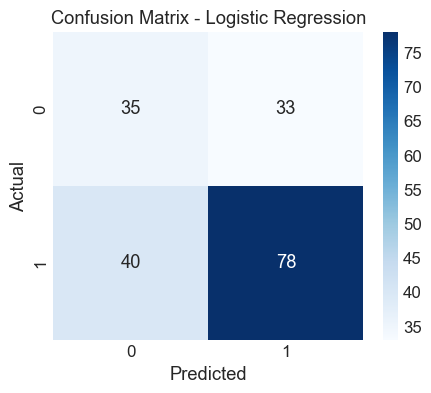

In [68]:
X = df_model.drop(columns=['churn'])
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_resampled, y_train_resampled)

y_train_pred = dt.predict(X_train_resampled)
y_train_prob = dt.predict_proba(X_train_resampled)[:, 1]
train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_prec = precision_score(y_train_resampled, y_train_pred)
train_rec = recall_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred)
train_f2 = fbeta_score(y_train_resampled, y_train_pred, beta=2)
train_roc_auc = roc_auc_score(y_train_resampled, y_train_prob)  

y_test_pred = dt.predict(X_test)
y_test_prob = dt.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("===== Decision Tree Baseline Model Evaluation =====\n")
print("🔹 TRAINING PERFORMANCE")
print(f"Accuracy  : {train_acc:.4f}")
print(f"Precision : {train_prec:.4f}")
print(f"Recall    : {train_rec:.4f}")
print(f"F1-Score  : {train_f1:.4f}")
print(f"F2-Score  : {train_f2:.4f}")
print(f"Roc-AUC   : {train_roc_auc:.4f}\n")

print("🔹 TESTING PERFORMANCE")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"F2-Score  : {test_f2:.4f}")
print(f"Roc-AUC   : {test_roc_auc:.4f}\n")

# Detailed Classification Report with F2-Score
print("===== Classification Report + F2-Score =====")
report = classification_report(y_test, y_test_pred, output_dict=True)

f2_per_class = {
    str(label): fbeta_score(y_test, y_test_pred, beta=2, pos_label=label)
    for label in np.unique(y_test)
}
   
report_df = pd.DataFrame(report).transpose()
    
for label in f2_per_class:
    report_df.loc[label, 'f2-score'] = f2_per_class[label]
    
cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
report_df = report_df[cols]
display(report_df.round(4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 10 most important features:


,Feature,Importance
5,target_achievement,0.163032
21,distance_stress_adjusted,0.118820
6,working_hours_per_week,0.079473
13,company_tenure_years,0.062628
4,monthly_target,0.061269
10,job_satisfaction,0.055709
0,age,0.054705
22,promotion_potential,0.047179
20,loyalty_index,0.045634
8,salary,0.043904



Least important features:


,Feature,Importance
12,manager_support_score,0.024785
23,stress_index,0.021244
2,education,0.021012
15,distance_to_office_km,0.018666
7,overtime_hours_per_week,0.014632
11,work_location,0.011641
3,experience_years,0.005812
14,marital_status,0.002855
1,gender,0.002141
19,achieve_status,0.000000


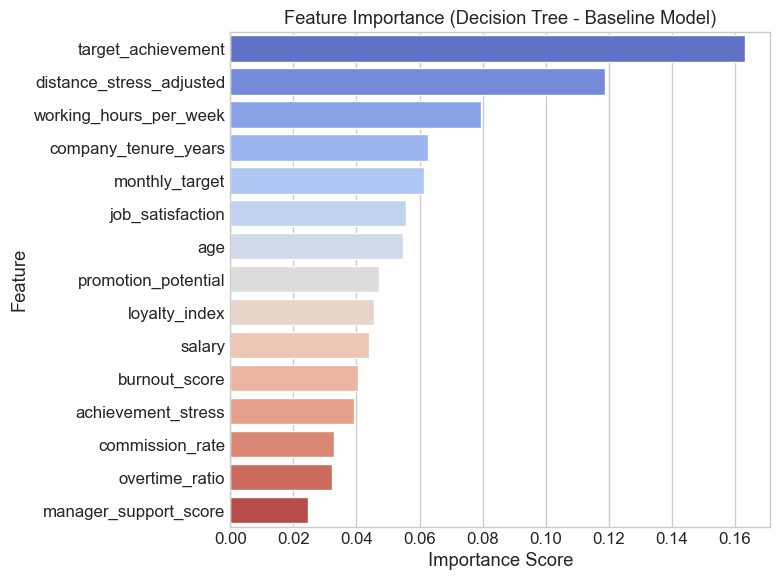

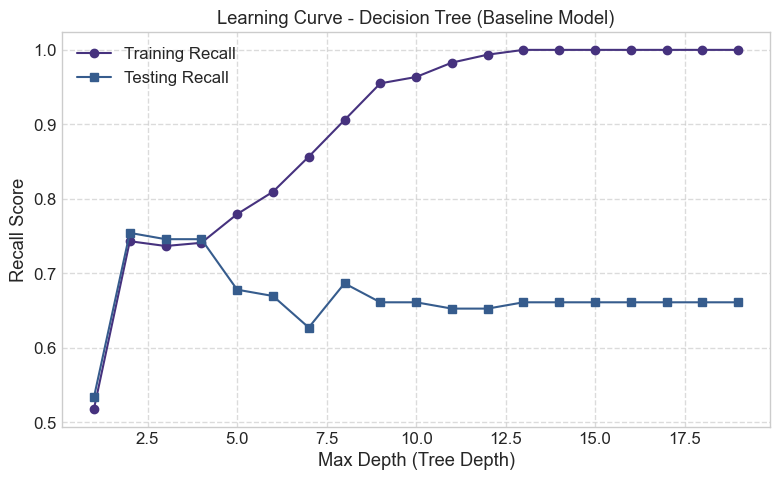

In [ ]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 most important features:")
display(feature_importance.head(10))
print("\nLeast important features:")
display(feature_importance.tail(10))

# Visualisasi Feature Importance
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='coolwarm')
plt.title("Feature Importance (Decision Tree - Baseline Model)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

param_values = np.arange(1, min(20, X_train_resampled.shape[1]))
train_recalls, test_recalls = [], []

for d in param_values:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_recalls.append(recall_score(y_train_resampled, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

# Visualisasi Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(param_values, train_recalls, marker='o', label="Training Recall")
plt.plot(param_values, test_recalls, marker='s', label="Testing Recall")
plt.xlabel("Max Depth (Tree Depth)")
plt.ylabel("Recall Score")
plt.title("Learning Curve - Decision Tree (Baseline Model)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Decision Tree Hypertuning

Fitting 5 folds for each of 40 candidates, totalling 200 fits
===== 🔍 Best Decision Tree Hyperparameters =====
{'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 3, 'criterion': 'log_loss'}
Best CV Recall: 0.7068

===== Decision Tree Model Evaluation (After Random Search) =====

🔹 TRAINING PERFORMANCE
Accuracy  : 0.7388
Precision : 0.7357
Recall    : 0.7452
F1-Score  : 0.7404
F2-Score  : 0.7433
Roc-AUC   : 0.7855

🔹 TESTING PERFORMANCE
Accuracy  : 0.7473
Precision : 0.8318
Recall    : 0.7542
F1-Score  : 0.7911
F2-Score  : 0.7686
Roc-AUC   : 0.7855

===== Classification Report (Testing Set) =====


,precision,recall,f1-score,f2-score,support
0,0.6329,0.7353,0.6803,0.7123,68.0000
1,0.8318,0.7542,0.7911,0.7686,118.0000
accuracy,0.7473,0.7473,0.7473,NaN,0.7473
macro avg,0.7323,0.7448,0.7357,NaN,186.0000
weighted avg,0.7591,0.7473,0.7506,NaN,186.0000


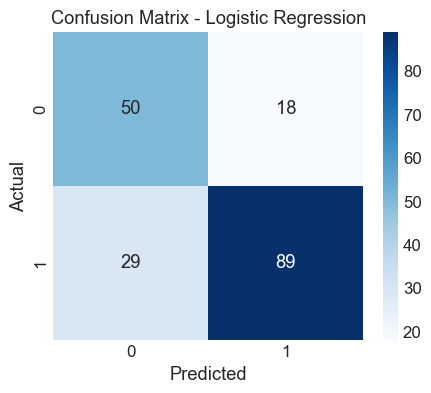

In [71]:
if hasattr(X_train_resampled, "columns"):
    feature_names = X_train_resampled.columns
else:
    feature_names = getattr(X_train, "columns", [f"Feature_{i}" for i in range(np.asarray(X_train_resampled).shape[1])])

param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': list(range(0, 21)),
    'min_samples_split': [2, 4, 5, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': [None, 'sqrt'],
    'splitter': ['best', 'random']
}

dt = DecisionTreeClassifier(random_state=42)
random_search_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=40,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)
random_search_dt.fit(X_train_resampled, y_train_resampled)

print("===== 🔍 Best Decision Tree Hyperparameters =====")
print(random_search_dt.best_params_)
print(f"Best CV Recall: {random_search_dt.best_score_:.4f}\n")

best_dt = random_search_dt.best_estimator_

y_train_pred = best_dt.predict(X_train_resampled)
y_test_pred = best_dt.predict(X_test)

train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_prec = precision_score(y_train_resampled, y_train_pred)
train_rec = recall_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred)
train_f2 = fbeta_score(y_train_resampled, y_train_pred, beta=2)
train_roc_auc = roc_auc_score(y_train_resampled, best_dt.predict_proba(X_train_resampled)[:, 1])

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)
train_roc_auc = roc_auc_score(y_test, best_dt.predict_proba(X_test)[:, 1])

print("===== Decision Tree Model Evaluation (After Random Search) =====\n")
print("🔹 TRAINING PERFORMANCE")
print(f"Accuracy  : {train_acc:.4f}")
print(f"Precision : {train_prec:.4f}")
print(f"Recall    : {train_rec:.4f}")
print(f"F1-Score  : {train_f1:.4f}")
print(f"F2-Score  : {train_f2:.4f}")
print(f"Roc-AUC   : {train_roc_auc:.4f}\n")

print("🔹 TESTING PERFORMANCE")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"F2-Score  : {test_f2:.4f}")
print(f"Roc-AUC   : {train_roc_auc:.4f}\n")

# Detailed Classification Report with F2-Score
print("===== Classification Report (Testing Set) =====")
report = classification_report(y_test, y_test_pred, output_dict=True)
f2_per_class = {
    str(label): fbeta_score(y_test, y_test_pred, beta=2, pos_label=label)
    for label in np.unique(y_test)
}

report_df = pd.DataFrame(report).transpose()
for label in f2_per_class:
    report_df.loc[label, 'f2-score'] = f2_per_class[label]

cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
report_df = report_df[cols]
display(report_df.round(4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 10 positive coefficients (increase churn likelihood):
                     Feature  Coefficient
5         target_achievement     0.388590
21  distance_stress_adjusted     0.280972
22       promotion_potential     0.151256
13      company_tenure_years     0.090125
10          job_satisfaction     0.089057
0                        age     0.000000
20             loyalty_index     0.000000
19            achieve_status     0.000000
18        achievement_stress     0.000000
17             burnout_score     0.000000

Top 10 negative coefficients (decrease churn likelihood):
                    Feature  Coefficient
1                    gender          0.0
11            work_location          0.0
9           commission_rate          0.0
8                    salary          0.0
7   overtime_hours_per_week          0.0
6    working_hours_per_week          0.0
4            monthly_target          0.0
3          experience_years          0.0
2                 education          0.0
23        

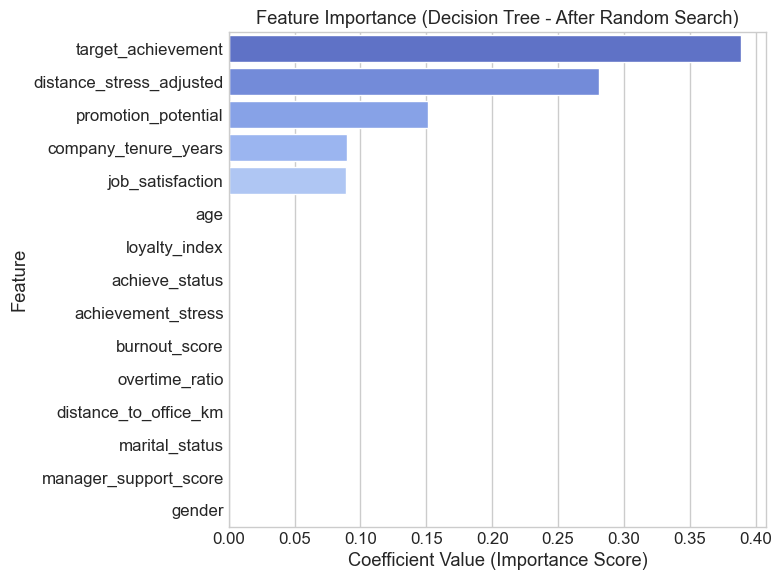

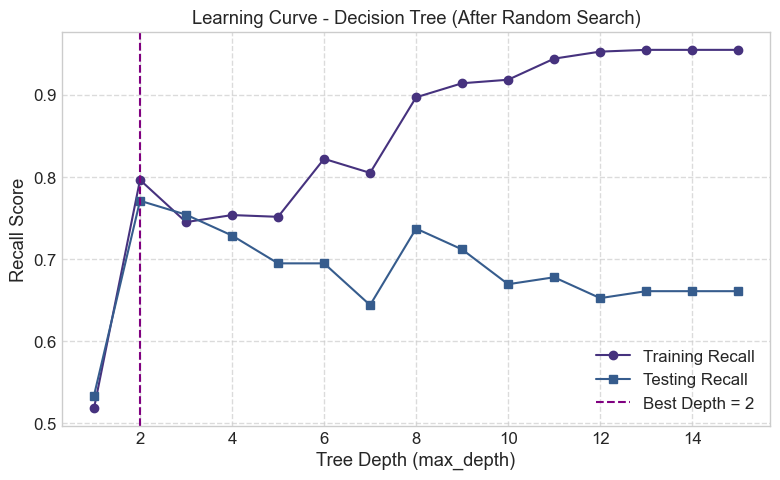

In [72]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_dt.feature_importances_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 10 positive coefficients (increase churn likelihood):")
print(feature_importance.head(10))
print("\nTop 10 negative coefficients (decrease churn likelihood):")
print(feature_importance.tail(10))

# Visualisasi Feature Importance
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title("Feature Importance (Decision Tree - After Random Search)")
plt.xlabel("Coefficient Value (Importance Score)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

param_values = np.arange(1, 16, 1)
train_recalls, test_recalls = [], []

for d in param_values:
    model = DecisionTreeClassifier(
        criterion=best_dt.criterion,
        max_depth=d,
        min_samples_split=best_dt.min_samples_split,
        min_samples_leaf=best_dt.min_samples_leaf,
        max_features=best_dt.max_features,
        splitter=best_dt.splitter,
        random_state=42
    )
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_recalls.append(recall_score(y_train_resampled, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

# Plotting the learning curve
best_depth_curve = param_values[int(np.argmax(test_recalls))]
plt.figure(figsize=(8, 5))
plt.plot(param_values, train_recalls, marker='o', label="Training Recall")
plt.plot(param_values, test_recalls, marker='s', label="Testing Recall")
plt.axvline(best_depth_curve, color='purple', linestyle='--', label=f"Best Depth = {best_depth_curve}")
plt.xlabel("Tree Depth (max_depth)")
plt.ylabel("Recall Score")
plt.title("Learning Curve - Decision Tree (After Random Search)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Random Forest Base Model

===== Random Forest Model Evaluation =====

🔹 TRAINING PERFORMANCE
Accuracy  : 0.9925
Precision : 0.9978
Recall    : 0.9872
F1-Score  : 0.9925
F2-Score  : 0.9893
Roc-AUC   : 0.9998

🔹 TESTING PERFORMANCE
Accuracy  : 0.7258
Precision : 0.7965
Recall    : 0.7627
F1-Score  : 0.7792
F2-Score  : 0.7692
Roc-AUC   : 0.8038

===== Classification Report (Testing Set) =====


,precision,recall,f1-score,f2-score,support
0,0.6164,0.6618,0.6383,0.6522,68.0000
1,0.7965,0.7627,0.7792,0.7692,118.0000
accuracy,0.7258,0.7258,0.7258,NaN,0.7258
macro avg,0.7064,0.7122,0.7088,NaN,186.0000
weighted avg,0.7306,0.7258,0.7277,NaN,186.0000


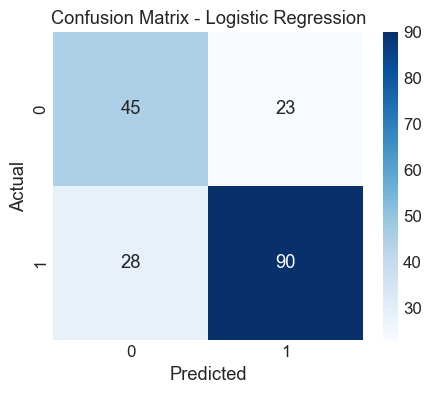

In [76]:
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_resampled, y_train_resampled)

y_train_pred = rf.predict(X_train_resampled)
y_train_prob = rf.predict_proba(X_train_resampled)[:, 1]
train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_prec = precision_score(y_train_resampled, y_train_pred)
train_rec = recall_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred)
train_f2 = fbeta_score(y_train_resampled, y_train_pred, beta=2)
train_roc_auc = roc_auc_score(y_train_resampled, y_train_prob)

y_test_pred = rf.predict(X_test)
y_test_prob = rf.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("===== Random Forest Model Evaluation =====\n")
print("🔹 TRAINING PERFORMANCE")
print(f"Accuracy  : {train_acc:.4f}")
print(f"Precision : {train_prec:.4f}")
print(f"Recall    : {train_rec:.4f}")
print(f"F1-Score  : {train_f1:.4f}")
print(f"F2-Score  : {train_f2:.4f}")
print(f"Roc-AUC   : {train_roc_auc:.4f}\n")

print("🔹 TESTING PERFORMANCE")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"F2-Score  : {test_f2:.4f}")
print(f"Roc-AUC   : {test_roc_auc:.4f}\n")

# Detailed Classification Report with F2-Score
print("===== Classification Report (Testing Set) =====")
report = classification_report(y_test, y_test_pred, output_dict=True)
f2_per_class = {
    str(label): fbeta_score(y_test, y_test_pred, beta=2, pos_label=label)
    for label in np.unique(y_test)
}

report_df = pd.DataFrame(report).transpose()
for label in f2_per_class:
    report_df.loc[label, 'f2-score'] = f2_per_class[label]

cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
report_df = report_df[cols]
display(report_df.round(4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 10 positive coefficients (increase churn likelihood):
                     Feature  Coefficient
5         target_achievement     0.118040
21  distance_stress_adjusted     0.089214
6     working_hours_per_week     0.077334
22       promotion_potential     0.077273
13      company_tenure_years     0.060889
23              stress_index     0.055483
15     distance_to_office_km     0.047956
16            overtime_ratio     0.047533
18        achievement_stress     0.046656
8                     salary     0.042313

Top 10 negative coefficients (decrease churn likelihood):
                    Feature  Coefficient
0                       age     0.031051
9           commission_rate     0.030576
7   overtime_hours_per_week     0.024971
12    manager_support_score     0.022296
3          experience_years     0.021984
11            work_location     0.014887
2                 education     0.013585
1                    gender     0.008857
14           marital_status     0.007229
19        

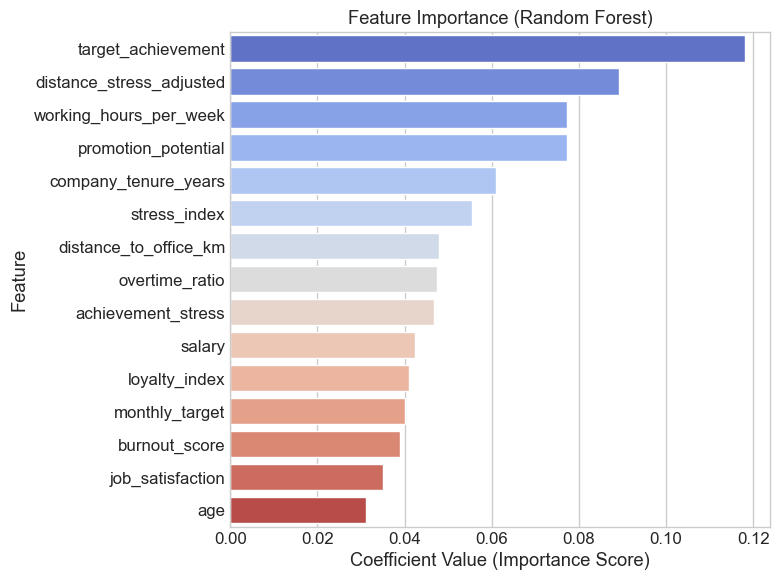

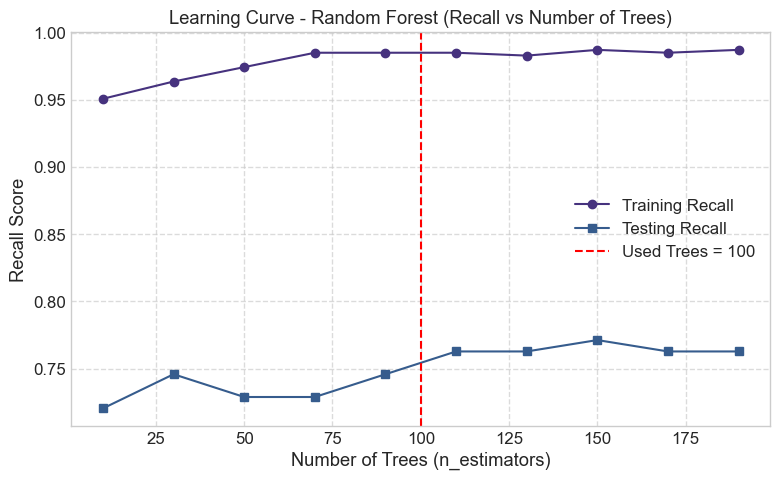

In [77]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Coefficient': rf.feature_importances_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 10 positive coefficients (increase churn likelihood):")
print(feature_importance.head(10))
print("\nTop 10 negative coefficients (decrease churn likelihood):")
print(feature_importance.tail(10))

# Visualisasi Feature Importance
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Coefficient Value (Importance Score)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Learning Curve - n_estimators
param_values = np.arange(10, 210, 20)
train_recalls, test_recalls = [], []

for n in param_values:
    model = RandomForestClassifier(
        n_estimators=n,
        criterion=rf.criterion,
        max_depth=rf.max_depth,
        min_samples_split=rf.min_samples_split,
        min_samples_leaf=rf.min_samples_leaf,
        max_features=rf.max_features,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_recalls.append(recall_score(y_train_resampled, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

# Plotting the learning curve
plt.figure(figsize=(8, 5))
plt.plot(param_values, train_recalls, marker='o', label="Training Recall")
plt.plot(param_values, test_recalls, marker='s', label="Testing Recall")
plt.axvline(rf.n_estimators, color='red', linestyle='--', label=f"Used Trees = {rf.n_estimators}")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Recall Score")
plt.title("Learning Curve - Random Forest (Recall vs Number of Trees)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Random Forest Hypertuning

Fitting 5 folds for each of 40 candidates, totalling 200 fits
===== 🔍 Best Random Forest Hyperparameters =====
{'n_estimators': 20, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'log_loss', 'bootstrap': False}
Best CV Recall: 0.7751

===== Random Forest Model Evaluation (After Random Search) =====

🔹 TRAINING PERFORMANCE
Accuracy  : 0.9968
Precision : 1.0000
Recall    : 0.9936
F1-Score  : 0.9968
F2-Score  : 0.9949
Roc-AUC   : 1.0000

🔹 TESTING PERFORMANCE
Accuracy  : 0.7151
Precision : 0.7982
Recall    : 0.7373
F1-Score  : 0.7665
F2-Score  : 0.7487
Roc-AUC   : 0.7761

===== Classification Report (Testing Set) =====


,precision,recall,f1-score,f2-score,support
0,0.5974,0.6765,0.6345,0.6590,68.0000
1,0.7982,0.7373,0.7665,0.7487,118.0000
accuracy,0.7151,0.7151,0.7151,NaN,0.7151
macro avg,0.6978,0.7069,0.7005,NaN,186.0000
weighted avg,0.7248,0.7151,0.7182,NaN,186.0000


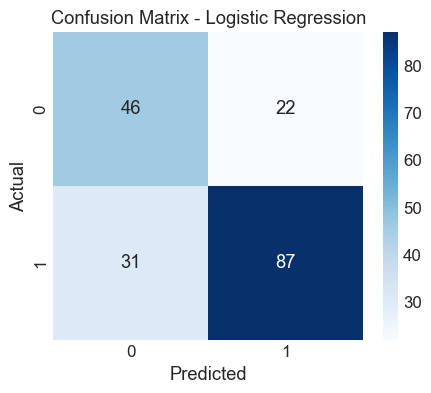

In [78]:
param_dist = {
    'n_estimators': [10, 20, 30, 40, 50, 60, 80, 100, 150, 200],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_rf.fit(X_train_resampled, y_train_resampled)

print("===== 🔍 Best Random Forest Hyperparameters =====")
print(random_search_rf.best_params_)
print(f"Best CV Recall: {random_search_rf.best_score_:.4f}\n")

best_rf = random_search_rf.best_estimator_

y_train_pred = best_rf.predict(X_train_resampled)
y_train_prob = best_rf.predict_proba(X_train_resampled)[:, 1]
train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_prec = precision_score(y_train_resampled, y_train_pred)
train_rec = recall_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred)
train_f2 = fbeta_score(y_train_resampled, y_train_pred, beta=2)
train_roc_auc = roc_auc_score(y_train_resampled, y_train_prob)  

y_test_pred = best_rf.predict(X_test)
y_test_prob = best_rf.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("===== Random Forest Model Evaluation (After Random Search) =====\n")
print("🔹 TRAINING PERFORMANCE")
print(f"Accuracy  : {train_acc:.4f}")
print(f"Precision : {train_prec:.4f}")
print(f"Recall    : {train_rec:.4f}")
print(f"F1-Score  : {train_f1:.4f}")
print(f"F2-Score  : {train_f2:.4f}")
print(f"Roc-AUC   : {train_roc_auc:.4f}\n")

print("🔹 TESTING PERFORMANCE")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"F2-Score  : {test_f2:.4f}")
print(f"Roc-AUC   : {test_roc_auc:.4f}\n")

# Detailed Classification Report with F2-Score
print("===== Classification Report (Testing Set) =====")
report = classification_report(y_test, y_test_pred, output_dict=True)
f2_per_class = {
    str(label): fbeta_score(y_test, y_test_pred, beta=2, pos_label=label)
    for label in np.unique(y_test)
}

report_df = pd.DataFrame(report).transpose()
for label in f2_per_class:
    report_df.loc[label, 'f2-score'] = f2_per_class[label]

cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
report_df = report_df[cols]
display(report_df.round(4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 10 most important features:
                     Feature  Coefficient
5         target_achievement     0.116086
21  distance_stress_adjusted     0.091682
22       promotion_potential     0.090381
6     working_hours_per_week     0.067617
23              stress_index     0.055498
18        achievement_stress     0.054675
13      company_tenure_years     0.053948
8                     salary     0.046513
15     distance_to_office_km     0.044798
20             loyalty_index     0.044189

Least important features:
                    Feature  Coefficient
9           commission_rate     0.034843
10         job_satisfaction     0.031839
3          experience_years     0.023606
7   overtime_hours_per_week     0.020852
12    manager_support_score     0.019046
11            work_location     0.013748
2                 education     0.011993
14           marital_status     0.009972
1                    gender     0.008741
19           achieve_status     0.002229


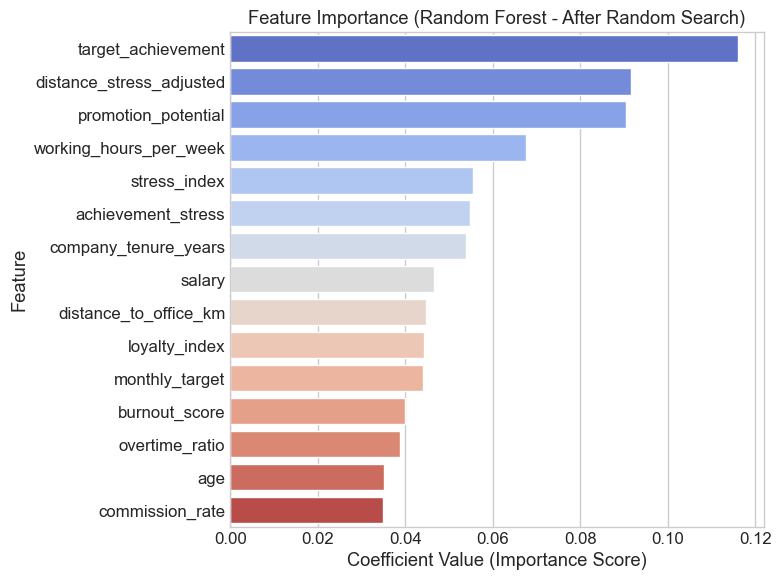

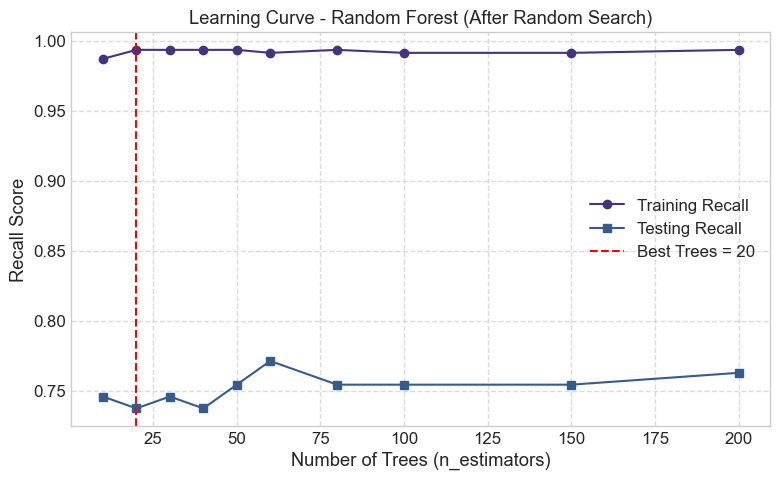

In [79]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Coefficient': best_rf.feature_importances_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 10 most important features:")
print(feature_importance.head(10))
print("\nLeast important features:")
print(feature_importance.tail(10))

# Visualisasi Feature Importance
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title("Feature Importance (Random Forest - After Random Search)")
plt.xlabel("Coefficient Value (Importance Score)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Learning Curve - n_estimators (After Random Search)
param_values = [10, 20, 30, 40, 50, 60, 80, 100, 150, 200]
train_recalls, test_recalls = [], []

for n in param_values:
    model = RandomForestClassifier(
        n_estimators=n,
        criterion=best_rf.criterion,
        max_depth=best_rf.max_depth,
        min_samples_split=best_rf.min_samples_split,
        min_samples_leaf=best_rf.min_samples_leaf,
        max_features=best_rf.max_features,
        bootstrap=best_rf.bootstrap,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_recalls.append(recall_score(y_train_resampled, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

# Plotting the learning curve
plt.figure(figsize=(8, 5))
plt.plot(param_values, train_recalls, marker='o', label="Training Recall")
plt.plot(param_values, test_recalls, marker='s', label="Testing Recall")
plt.axvline(best_rf.n_estimators, color='red', linestyle='--', label=f"Best Trees = {best_rf.n_estimators}")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Recall Score")
plt.title("Learning Curve - Random Forest (After Random Search)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# XGBClassifier Base Model

===== XGBoost Baseline Model Evaluation =====

🔹 TRAINING PERFORMANCE
Accuracy  : 0.8833
Precision : 0.9106
Recall    : 0.8501
F1-Score  : 0.8793
F2-Score  : 0.8615
Roc-AUC   : 0.9554

🔹 TESTING PERFORMANCE
Accuracy  : 0.7634
Precision : 0.8426
Recall    : 0.7712
F1-Score  : 0.8053
F2-Score  : 0.7845
Roc-AUC   : 0.8172

===== Classification Report (Testing Set) =====


,precision,recall,f1-score,f2-score,support
0,0.6538,0.7500,0.6986,0.7286,68.0000
1,0.8426,0.7712,0.8053,0.7845,118.0000
accuracy,0.7634,0.7634,0.7634,NaN,0.7634
macro avg,0.7482,0.7606,0.7520,NaN,186.0000
weighted avg,0.7736,0.7634,0.7663,NaN,186.0000


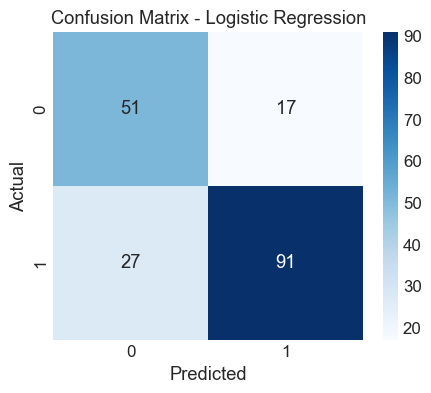

In [ ]:
# XGBoost Baseline Model

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=5,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_resampled, y_train_resampled)

y_train_pred = xgb.predict(X_train_resampled)
y_train_prob = xgb.predict_proba(X_train_resampled)[:, 1]
train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_prec = precision_score(y_train_resampled, y_train_pred)
train_rec = recall_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred)
train_f2 = fbeta_score(y_train_resampled, y_train_pred, beta=2)
train_roc_auc = roc_auc_score(y_train_resampled, y_train_prob)

y_test_pred = xgb.predict(X_test)
y_test_prob = xgb.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("===== XGBoost Baseline Model Evaluation =====\n")
print("🔹 TRAINING PERFORMANCE")
print(f"Accuracy  : {train_acc:.4f}")
print(f"Precision : {train_prec:.4f}")
print(f"Recall    : {train_rec:.4f}")
print(f"F1-Score  : {train_f1:.4f}")
print(f"F2-Score  : {train_f2:.4f}")
print(f"Roc-AUC   : {train_roc_auc:.4f}\n")

print("🔹 TESTING PERFORMANCE")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"F2-Score  : {test_f2:.4f}")
print(f"Roc-AUC   : {test_roc_auc:.4f}\n")

# Detailed Classification Report with F2-Score
print("===== Classification Report (Testing Set) =====")
report = classification_report(y_test, y_test_pred, output_dict=True)
f2_per_class = {
    str(label): fbeta_score(y_test, y_test_pred, beta=2, pos_label=label)
    for label in np.unique(y_test)
}

report_df = pd.DataFrame(report).transpose()
for label in f2_per_class:
    report_df.loc[label, 'f2-score'] = f2_per_class[label]

cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
report_df = report_df[cols]
display(report_df.round(4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 10 positive coefficients (increase churn likelihood):
                     Feature  Coefficient
5         target_achievement     0.191074
10          job_satisfaction     0.098928
21  distance_stress_adjusted     0.081897
6     working_hours_per_week     0.071761
13      company_tenure_years     0.057507
12     manager_support_score     0.038621
19            achieve_status     0.035784
22       promotion_potential     0.034443
17             burnout_score     0.033947
15     distance_to_office_km     0.031353

Top 10 negative coefficients (decrease churn likelihood):
                    Feature  Coefficient
8                    salary     0.026199
16           overtime_ratio     0.025344
1                    gender     0.024996
23             stress_index     0.023898
0                       age     0.022432
4            monthly_target     0.021617
9           commission_rate     0.019278
14           marital_status     0.015791
2                 education     0.015053
7   overti

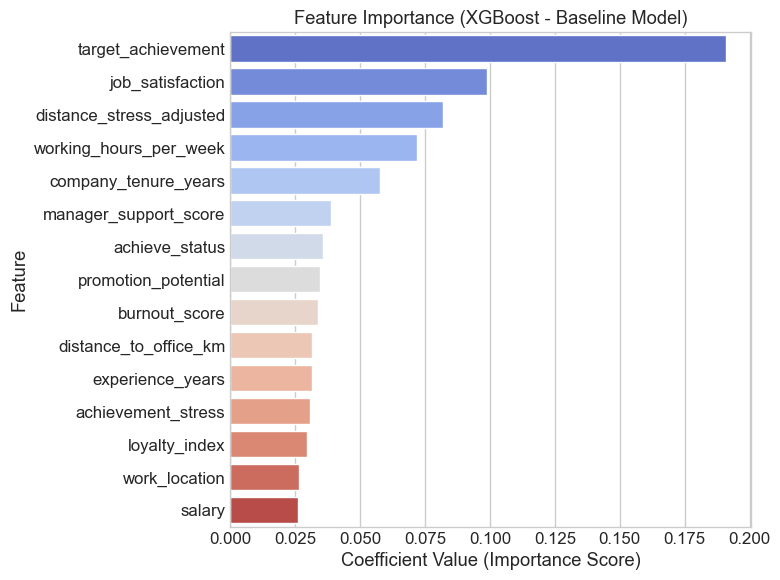

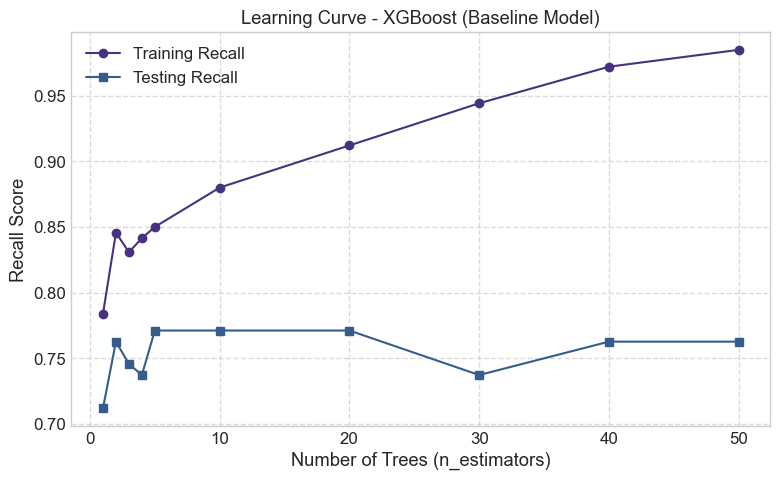

In [81]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Coefficient': xgb.feature_importances_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 10 positive coefficients (increase churn likelihood):")
print(feature_importance.head(10))
print("\nTop 10 negative coefficients (decrease churn likelihood):")
print(feature_importance.tail(10))

# Visualisasi Feature Importance
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title("Feature Importance (XGBoost - Baseline Model)")
plt.xlabel("Coefficient Value (Importance Score)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Learning Curve - n_estimators
param_values = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50]
train_recalls, test_recalls = [], []

for n in param_values:
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        n_estimators=n,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_recalls.append(recall_score(y_train_resampled, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

# Plotting the learning curve
plt.figure(figsize=(8, 5))
plt.plot(param_values, train_recalls, marker='o', label="Training Recall")
plt.plot(param_values, test_recalls, marker='s', label="Testing Recall")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Recall Score")
plt.title("Learning Curve - XGBoost (Baseline Model)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# XGBClassifier Hypertuning

Fitting 5 folds for each of 40 candidates, totalling 200 fits
===== 🔍 Best XGBoost Hyperparameters =====
{'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.3, 'colsample_bytree': 0.8}
Best CV Recall: 0.7986

===== XGBoost Model Evaluation (After Random Search) =====

🔹 TRAINING PERFORMANCE
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
F2-Score  : 1.0000
Roc-AUC   : 1.0000

🔹 TESTING PERFORMANCE
Accuracy  : 0.6828
Precision : 0.7611
Recall    : 0.7288
F1-Score  : 0.7446
F2-Score  : 0.7350
Roc-AUC   : 0.7718

===== Classification Report (Testing Set) =====


,precision,recall,f1-score,f2-score,support
0,0.5616,0.6029,0.5816,0.5942,68.0000
1,0.7611,0.7288,0.7446,0.7350,118.0000
accuracy,0.6828,0.6828,0.6828,NaN,0.6828
macro avg,0.6614,0.6659,0.6631,NaN,186.0000
weighted avg,0.6882,0.6828,0.6850,NaN,186.0000


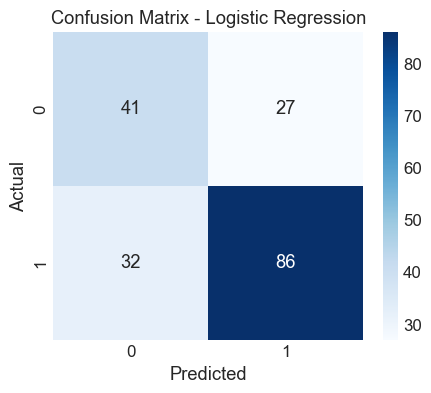

In [82]:
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5],
    'reg_lambda': [0.5, 1, 1.5, 2],
    'reg_alpha': [0, 0.1, 0.3, 0.5]
}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train_resampled, y_train_resampled)

print("===== 🔍 Best XGBoost Hyperparameters =====")
print(random_search_xgb.best_params_)
print(f"Best CV Recall: {random_search_xgb.best_score_:.4f}\n")

best_xgb = random_search_xgb.best_estimator_

y_train_pred = best_xgb.predict(X_train_resampled)
y_train_prob = best_xgb.predict_proba(X_train_resampled)[:, 1]
train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_prec = precision_score(y_train_resampled, y_train_pred)
train_rec = recall_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred)
train_f2 = fbeta_score(y_train_resampled, y_train_pred, beta=2)
train_roc_auc = roc_auc_score(y_train_resampled, y_train_prob)

y_test_pred = best_xgb.predict(X_test)
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("===== XGBoost Model Evaluation (After Random Search) =====\n")
print("🔹 TRAINING PERFORMANCE")
print(f"Accuracy  : {train_acc:.4f}")
print(f"Precision : {train_prec:.4f}")
print(f"Recall    : {train_rec:.4f}")
print(f"F1-Score  : {train_f1:.4f}")
print(f"F2-Score  : {train_f2:.4f}")
print(f"Roc-AUC   : {train_roc_auc:.4f}\n")

print("🔹 TESTING PERFORMANCE")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"F2-Score  : {test_f2:.4f}")
print(f"Roc-AUC   : {test_roc_auc:.4f}\n")

# Detailed Classification Report with F2-Score
print("===== Classification Report (Testing Set) =====")
report = classification_report(y_test, y_test_pred, output_dict=True)
f2_per_class = {
    str(label): fbeta_score(y_test, y_test_pred, beta=2, pos_label=label)
    for label in np.unique(y_test)
}

report_df = pd.DataFrame(report).transpose()
for label in f2_per_class:
    report_df.loc[label, 'f2-score'] = f2_per_class[label]

cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
report_df = report_df[cols]
display(report_df.round(4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 10 most important features:
                     Feature  Coefficient
5         target_achievement     0.088333
10          job_satisfaction     0.073163
22       promotion_potential     0.057933
21  distance_stress_adjusted     0.056882
6     working_hours_per_week     0.054571
19            achieve_status     0.048741
2                  education     0.046814
12     manager_support_score     0.045158
11             work_location     0.045095
1                     gender     0.039640

Least important features:
                    Feature  Coefficient
20            loyalty_index     0.033437
4            monthly_target     0.032664
0                       age     0.032596
13     company_tenure_years     0.032335
16           overtime_ratio     0.031617
7   overtime_hours_per_week     0.030952
23             stress_index     0.029054
8                    salary     0.027846
17            burnout_score     0.027799
3          experience_years     0.024287


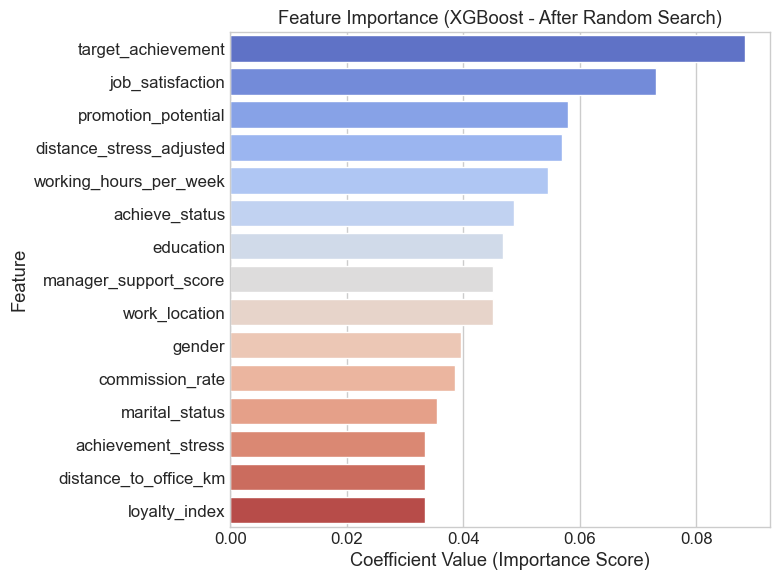

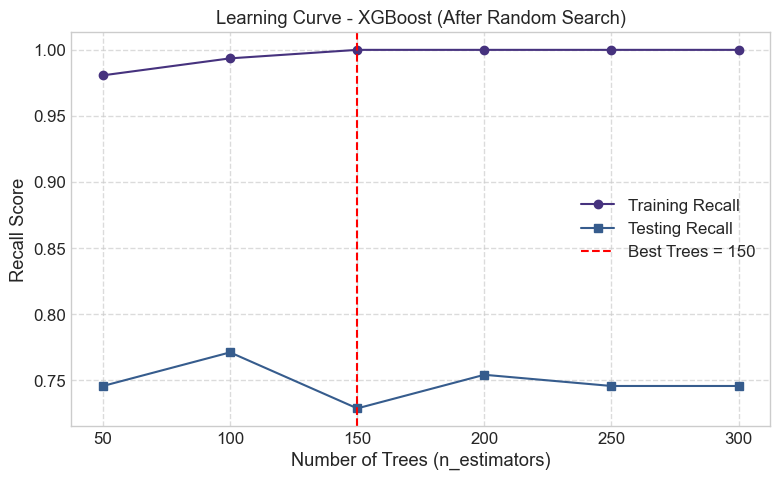

In [83]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Coefficient': best_xgb.feature_importances_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 10 most important features:")
print(feature_importance.head(10))
print("\nLeast important features:")
print(feature_importance.tail(10))

# Visualisasi Feature Importance
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title("Feature Importance (XGBoost - After Random Search)")
plt.xlabel("Coefficient Value (Importance Score)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

param_values = [50, 100, 150, 200, 250, 300]
train_recalls, test_recalls = [], []

for n in param_values:
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        n_estimators=n,
        max_depth=best_xgb.max_depth,
        learning_rate=best_xgb.learning_rate,
        subsample=best_xgb.subsample,
        colsample_bytree=best_xgb.colsample_bytree,
        gamma=best_xgb.gamma,
        min_child_weight=best_xgb.min_child_weight,
        reg_lambda=best_xgb.reg_lambda,
        reg_alpha=best_xgb.reg_alpha,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_recalls.append(recall_score(y_train_resampled, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

plt.figure(figsize=(8, 5))
plt.plot(param_values, train_recalls, marker='o', label="Training Recall")
plt.plot(param_values, test_recalls, marker='s', label="Testing Recall")
plt.axvline(best_xgb.n_estimators, color='red', linestyle='--', label=f"Best Trees = {best_xgb.n_estimators}")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Recall Score")
plt.title("Learning Curve - XGBoost (After Random Search)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# KNN Base Model

===== KNN Baseline Model Evaluation =====

🔹 TRAINING PERFORMANCE
Accuracy  : 0.8264
Precision : 0.8761
Recall    : 0.7604
F1-Score  : 0.8141

🔹 TESTING PERFORMANCE
Accuracy  : 0.6043
Precision : 0.7089
Recall    : 0.6364
F1-Score  : 0.6707

===== Classification Report (Testing Set) =====
              precision    recall  f1-score   support

           0     0.4667    0.5490    0.5045       102
           1     0.7089    0.6364    0.6707       176

    accuracy                         0.6043       278
   macro avg     0.5878    0.5927    0.5876       278
weighted avg     0.6200    0.6043    0.6097       278



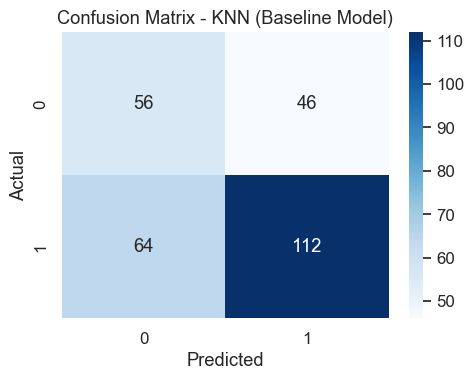

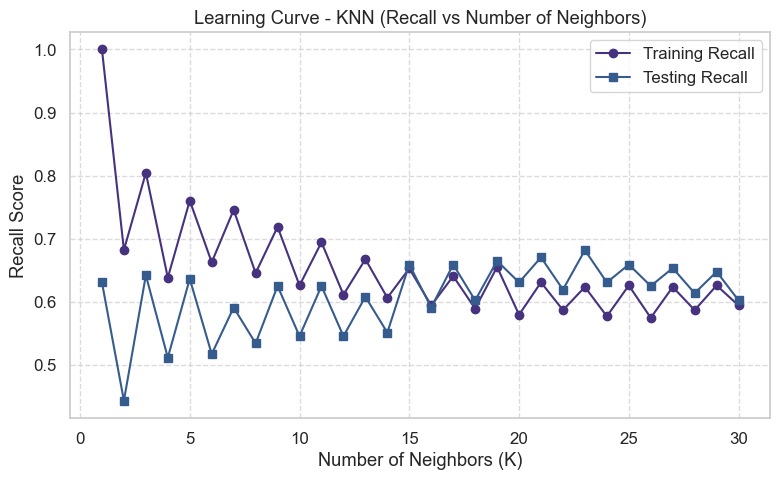

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', p=2, n_jobs=-1)
knn.fit(X_train_resampled, y_train_resampled)

y_train_pred = knn.predict(X_train_resampled)
y_test_pred = knn.predict(X_test)

train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_prec = precision_score(y_train_resampled, y_train_pred)
train_rec = recall_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("===== KNN Baseline Model Evaluation =====\n")
print("🔹 TRAINING PERFORMANCE")
print(f"Accuracy  : {train_acc:.4f}")
print(f"Precision : {train_prec:.4f}")
print(f"Recall    : {train_rec:.4f}")
print(f"F1-Score  : {train_f1:.4f}")
print("\n🔹 TESTING PERFORMANCE")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")

# Detailed Classification Report with F2-Score
print("===== Classification Report (Testing Set) =====")
report = classification_report(y_test, y_test_pred, output_dict=True)
f2_per_class = {
    str(label): fbeta_score(y_test, y_test_pred, beta=2, pos_label=label)
    for label in np.unique(y_test)
}

report_df = pd.DataFrame(report).transpose()
for label in f2_per_class:
    report_df.loc[label, 'f2-score'] = f2_per_class[label]

cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
report_df = report_df[cols]
display(report_df.round(4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

param_values = np.arange(1, 31)
train_recalls, test_recalls = [], []

for k in param_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_recalls.append(recall_score(y_train_resampled, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

plt.figure(figsize=(8, 5))
plt.plot(param_values, train_recalls, marker='o', label="Training Recall")
plt.plot(param_values, test_recalls, marker='s', label="Testing Recall")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Recall Score")
plt.title("Learning Curve - KNN (Recall vs Number of Neighbors)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# KNN Hyperparametertuning

Fitting 5 folds for each of 40 candidates, totalling 200 fits
===== 🔍 Best KNN Hyperparameters =====
{'weights': 'distance', 'p': 2, 'n_neighbors': 4, 'metric': 'minkowski'}
Best CV Recall: 0.6478

===== KNN Model Evaluation (After Random Search) =====

🔹 TRAINING PERFORMANCE
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

🔹 TESTING PERFORMANCE
Accuracy  : 0.6079
Precision : 0.7161
Recall    : 0.6307
F1-Score  : 0.6707

===== Classification Report (Testing Set) =====
              precision    recall  f1-score   support

           0     0.4715    0.5686    0.5156       102
           1     0.7161    0.6307    0.6707       176

    accuracy                         0.6079       278
   macro avg     0.5938    0.5997    0.5931       278
weighted avg     0.6264    0.6079    0.6138       278



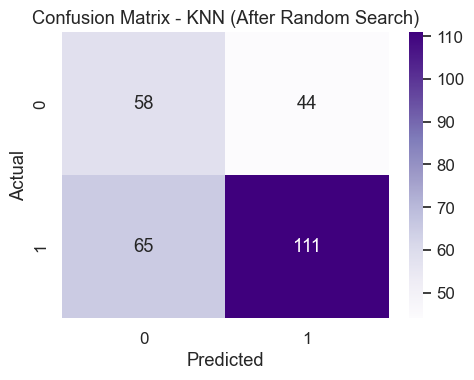

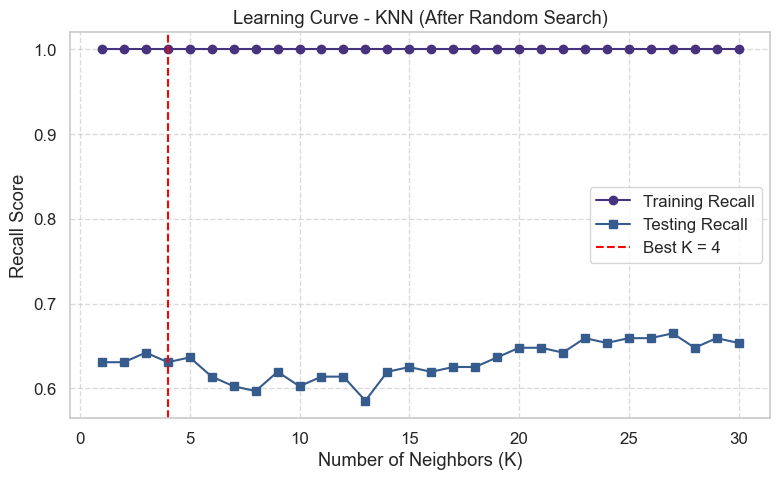

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

param_dist = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'manhattan'],
    'p': [1, 2]
}

knn = KNeighborsClassifier(n_jobs=-1)

random_search_knn = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=40,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_knn.fit(X_train_resampled, y_train_resampled)

print("===== 🔍 Best KNN Hyperparameters =====")
print(random_search_knn.best_params_)
print(f"Best CV Recall: {random_search_knn.best_score_:.4f}\n")

best_knn = random_search_knn.best_estimator_

y_train_pred = best_knn.predict(X_train_resampled)
y_test_pred = best_knn.predict(X_test)

train_acc = accuracy_score(y_train_resampled, y_train_pred)
train_prec = precision_score(y_train_resampled, y_train_pred)
train_rec = recall_score(y_train_resampled, y_train_pred)
train_f1 = f1_score(y_train_resampled, y_train_pred)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("===== KNN Model Evaluation (After Random Search) =====\n")
print("🔹 TRAINING PERFORMANCE")
print(f"Accuracy  : {train_acc:.4f}")
print(f"Precision : {train_prec:.4f}")
print(f"Recall    : {train_rec:.4f}")
print(f"F1-Score  : {train_f1:.4f}")
print("\n🔹 TESTING PERFORMANCE")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")

# Detailed Classification Report with F2-Score
print("===== Classification Report (Testing Set) =====")
report = classification_report(y_test, y_test_pred, output_dict=True)
f2_per_class = {
    str(label): fbeta_score(y_test, y_test_pred, beta=2, pos_label=label)
    for label in np.unique(y_test)
}

report_df = pd.DataFrame(report).transpose()
for label in f2_per_class:
    report_df.loc[label, 'f2-score'] = f2_per_class[label]

cols = ['precision', 'recall', 'f1-score', 'f2-score', 'support']
report_df = report_df[cols]
display(report_df.round(4))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
param_values = np.arange(1, 31)
train_recalls, test_recalls = [], []

for k in param_values:
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights=best_knn.weights,
        metric=best_knn.metric,
        p=best_knn.p,
        n_jobs=-1
    )
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_recalls.append(recall_score(y_train_resampled, y_train_pred))
    test_recalls.append(recall_score(y_test, y_test_pred))

plt.figure(figsize=(8, 5))
plt.plot(param_values, train_recalls, marker='o', label="Training Recall")
plt.plot(param_values, test_recalls, marker='s', label="Testing Recall")
plt.axvline(best_knn.n_neighbors, color='red', linestyle='--', label=f"Best K = {best_knn.n_neighbors}")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Recall Score")
plt.title("Learning Curve - KNN (After Random Search)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Best Model

The selection of the best model winner is Logistic Regression after tuning
this is the reason:

- Trustworthy Model: With a very small difference in training and testing performance, we can trust that this model will perform well on new employee data in the future. The performance will not drop suddenly. It is a stable model and generalization is good.

- Balanced Performance: This model not only has a good Recall, but also a high F1-Score (0.7744), which is one of the best among all stable models. This shows it finds a good balance between catching churn cases (Recall) and not making too many false alarms (Precision).

- Avoiding Hidden Risks: Choosing the Decision Tree with the highest Recall is tempting. However, its lower other performance indicates the risk that the model might just "guess churn" more often to get a high Recall, which could be inefficient in practice. In contrast, Logistic Regression delivers solid results across all metrics.


# Explainable AI: SHAP

# Explainable AI: LIME

# Bias & Fairness Asessment